In [ ]:
!pip uninstall -y triton
!pip install triton==3.4.0


In [ ]:
import triton
import torch

print("torch:", torch.__version__)
print("triton:", triton.__version__)
print("triton file:", triton.__file__)


In [2]:
NORMAL_PATH = "/kaggle/input/swat-dataset-secure-water-treatment-system/normal.csv"
MERGED_PATH = "/kaggle/input/swat-dataset-secure-water-treatment-system/merged.csv"
ATTACK_PATH = "/kaggle/input/swat-dataset-secure-water-treatment-system/attack.csv"


# Identifying Labels and Shape of Dataset 

In [3]:
import pandas as pd
import numpy as np


df_normal = pd.read_csv(NORMAL_PATH)
df_merged = pd.read_csv(MERGED_PATH)

df_normal.columns = df_normal.columns.str.strip()
df_merged.columns = df_merged.columns.str.strip()

def find_timestamp_col(df):
    for c in ["Timestamp","timestamp","Time","time","DateTime","datetime"]:
        if c in df.columns: return c
    return None

def find_label_col(df):
    for c in ["Normal/Attack","NormalAttack","attack","Attack","label","Label"]:
        if c in df.columns: return c
    return None

ts_col = find_timestamp_col(df_normal)
label_col = find_label_col(df_merged)

print("Timestamp col:", ts_col)
print("Merged label col:", label_col)

print("Normal shape:", df_normal.shape)
print("Merged shape:", df_merged.shape)
print(df_merged[label_col].value_counts().head() if label_col else "No label in merged")

Timestamp col: Timestamp
Merged label col: Normal/Attack
Normal shape: (1387098, 53)
Merged shape: (1441719, 53)
Normal/Attack
Normal    1387098
Attack      54621
Name: count, dtype: int64


# DATAPREPROCESSING
**Dropping Unrequired Columns**  

In [4]:
# Use only columns present in BOTH normal and merged 
common_cols = set(df_normal.columns) & set(df_merged.columns)

drop = set()
if ts_col: drop.add(ts_col)
if label_col: drop.add(label_col)

feature_cols = sorted([c for c in common_cols if c not in drop])
print("Feature count:", len(feature_cols))
print("Example features:", feature_cols[:10])

Feature count: 51
Example features: ['AIT201', 'AIT202', 'AIT203', 'AIT401', 'AIT402', 'AIT501', 'AIT502', 'AIT503', 'AIT504', 'DPIT301']


In [5]:
# Extract numeric matrices
Xn = df_normal[feature_cols].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=np.float32)
Xm = df_merged[feature_cols].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=np.float32)

# Fill NaNs using normal means
col_means = np.nanmean(Xn, axis=0)
Xn = np.where(np.isnan(Xn), col_means, Xn)
Xm = np.where(np.isnan(Xm), col_means, Xm)

# MinMax fit on NORMAL only
fmin = Xn.min(axis=0)
fmax = Xn.max(axis=0)
den = (fmax - fmin)
den[den == 0] = 1.0

Xn = (Xn - fmin) / den
Xm = (Xm - fmin) / den

print("Scaled shapes:", Xn.shape, Xm.shape, "dtype:", Xn.dtype)

# Labels from merged
def normalize_label_series(s):
    s2 = s.astype(str).str.lower()
    return s2.apply(lambda x: 1 if "attack" in x else 0).astype(np.int64).to_numpy()

y_merged = normalize_label_series(df_merged[label_col]) if label_col else None
print("Label dist (merged):", np.unique(y_merged, return_counts=True))

Scaled shapes: (1387098, 51) (1441719, 51) dtype: float32
Label dist (merged): (array([0, 1]), array([1387098,   54621]))


**PyTorch Dataset Classes-to convert time series data into training samples**

In [6]:
import torch
from torch.utils.data import Dataset, DataLoader, Subset

class PredictorDS(Dataset):
    # Predict x[t] from X[t-window:t]
    def __init__(self, X, window=20, stride=1):
        self.X = X
        self.window = window
        self.stride = stride
        self.n = (len(X) - window) // stride

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        t = idx * self.stride + self.window
        xw = self.X[t-self.window:t]      # (window, F)
        y  = self.X[t]                    # (F)
        return torch.from_numpy(xw), torch.from_numpy(y)

class AEDataset(Dataset):
    def __init__(self, X, window=20, stride=1):
        self.X = X
        self.window = window
        self.stride = stride
        self.n = (len(X) - window) // stride

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        t = idx * self.stride + self.window
        xw = self.X[t-self.window:t]
        xw_t = torch.from_numpy(xw)
        return xw_t, xw_t


**Prepare Training and validation sets for GRU Model and AE Baseline**

In [7]:
WINDOW = 20
STRIDE = 1
BATCH = 256

pred_ds = PredictorDS(Xn, window=WINDOW, stride=STRIDE)
ae_ds   = AEDataset(Xn, window=WINDOW, stride=STRIDE)

N = len(pred_ds)
split = int(N * 0.9)
train_idx = list(range(0, split))
val_idx   = list(range(split, N))

pred_train = Subset(pred_ds, train_idx)
pred_val   = Subset(pred_ds, val_idx)
ae_train   = Subset(ae_ds, train_idx)
ae_val     = Subset(ae_ds, val_idx)

pred_train_loader = DataLoader(pred_train, batch_size=BATCH, shuffle=True, num_workers=2, pin_memory=True)
pred_val_loader   = DataLoader(pred_val, batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

ae_train_loader = DataLoader(ae_train, batch_size=BATCH, shuffle=True, num_workers=2, pin_memory=True)
ae_val_loader   = DataLoader(ae_val, batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

print("Train samples:", len(pred_train), "Val samples:", len(pred_val))
print("n_features:", len(feature_cols))


Train samples: 1248370 Val samples: 138708
n_features: 51


**CLASSES TO DEFINE GRU PREDICTOR AND MLP AE MODELS**

In [8]:
import torch.nn as nn
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

class GRUPredictor(nn.Module):
    def __init__(self, n_features, hidden=64, num_layers=1, dropout=0.0):
        super().__init__()
        self.gru = nn.GRU(
            input_size=n_features,
            hidden_size=hidden,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.head = nn.Linear(hidden, n_features)

    def forward(self, x):
        out, _ = self.gru(x)          # (B,T,H)
        last = out[:, -1, :]          # (B,H)
        return self.head(last)        # (B,F)

class MLPWindowAE(nn.Module):
    def __init__(self, n_features, window=20, latent=64, hidden=256):
        super().__init__()
        inp = window * n_features
        self.encoder = nn.Sequential(
            nn.Linear(inp, hidden),
            nn.ReLU(),
            nn.Linear(hidden, latent),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent, hidden),
            nn.ReLU(),
            nn.Linear(hidden, inp),
        )
        self.window = window
        self.n_features = n_features

    def forward(self, x):
        B,T,F = x.shape
        flat = x.reshape(B, T*F)
        z = self.encoder(flat)
        rec = self.decoder(z).reshape(B, T, F)
        return rec


Device: cuda


In [12]:
def train_epoch_predictor(model, loader, optim, loss_fn):
    model.train()
    total = 0.0
    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        optim.zero_grad()
        yhat = model(xb)
        loss = loss_fn(yhat, yb)
        loss.backward()
        optim.step()
        total += loss.item() * xb.size(0)
    return total / len(loader.dataset)

@torch.no_grad()
def eval_epoch_predictor(model, loader, loss_fn):
    model.eval()
    total = 0.0
    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        yhat = model(xb)
        loss = loss_fn(yhat, yb)
        total += loss.item() * xb.size(0)
    return total / len(loader.dataset)

def train_epoch_ae(model, loader, optim, loss_fn):
    model.train()
    total = 0.0
    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        optim.zero_grad()
        rec = model(xb)
        loss = loss_fn(rec, yb)
        loss.backward()
        optim.step()
        total += loss.item() * xb.size(0)
    return total / len(loader.dataset)

@torch.no_grad()
def eval_epoch_ae(model, loader, loss_fn):
    model.eval()
    total = 0.0
    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        rec = model(xb)
        loss = loss_fn(rec, yb)
        total += loss.item() * xb.size(0)
    return total / len(loader.dataset)


In [13]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pin = torch.cuda.is_available()
print("Device:", device, "| GPU:", torch.cuda.get_device_name(0) if pin else None)


Device: cuda | GPU: Tesla T4


In [15]:
from torch.utils.data import DataLoader

pred_train_loader = DataLoader(pred_train, batch_size=BATCH, shuffle=True, num_workers=0, pin_memory=pin)
pred_val_loader   = DataLoader(pred_val, batch_size=BATCH, shuffle=False, num_workers=0, pin_memory=pin)

ae_train_loader = DataLoader(ae_train, batch_size=BATCH, shuffle=True, num_workers=0, pin_memory=pin)
ae_val_loader   = DataLoader(ae_val, batch_size=BATCH, shuffle=False, num_workers=0, pin_memory=pin)


**GRU Model Training**

In [16]:
import torch.nn as nn
import time

# Re-init model fresh (recommended after restart)
nF = len(feature_cols)
gru = GRUPredictor(n_features=nF, hidden=64).to(device)

loss_fn = nn.MSELoss()#to predict continuos sensor values
opt = torch.optim.Adam(gru.parameters(), lr=1e-3)

EPOCHS = 30
patience = 3
min_delta = 1e-6

best_val = float("inf")
bad = 0
best_state = None

for ep in range(1, EPOCHS+1):
    t0 = time.time()
    tr = train_epoch_predictor(gru, pred_train_loader, opt, loss_fn)
    va = eval_epoch_predictor(gru, pred_val_loader, loss_fn)
    dt = time.time() - t0
    print(f"[GRU] Epoch {ep}/{EPOCHS} train={tr:.6f} val={va:.6f} time={dt:.1f}s")

    if va < best_val - min_delta:
        best_val = va
        bad = 0
        best_state = {k: v.detach().cpu().clone() for k, v in gru.state_dict().items()}
    else:
        bad += 1
        if bad >= patience:
            print(f"[GRU] Early stopping at epoch {ep}. Best val={best_val:.6f}")
            break

# restore best
gru.load_state_dict(best_state)
gru.to(device)


KeyboardInterrupt: 

**AE Model Trainning**

In [ ]:
# Re-init AE fresh
ae = MLPWindowAE(n_features=nF, window=WINDOW, latent=64, hidden=256).to(device)

loss_fn = nn.MSELoss()
opt = torch.optim.Adam(ae.parameters(), lr=1e-3)

EPOCHS = 30
patience = 3
min_delta = 1e-6

best_val = float("inf")
bad = 0
best_state = None

for ep in range(1, EPOCHS+1):
    t0 = time.time()
    tr = train_epoch_ae(ae, ae_train_loader, opt, loss_fn)
    va = eval_epoch_ae(ae, ae_val_loader, loss_fn)
    dt = time.time() - t0
    print(f"[AE] Epoch {ep}/{EPOCHS} train={tr:.6f} val={va:.6f} time={dt:.1f}s")

    if va < best_val - min_delta:
        best_val = va
        bad = 0
        best_state = {k: v.detach().cpu().clone() for k, v in ae.state_dict().items()}
    else:
        bad += 1
        if bad >= patience:
            print(f"[AE] Early stopping at epoch {ep}. Best val={best_val:.6f}")
            break

# restore best
ae.load_state_dict(best_state)
ae.to(device)


**Testing Dataset**

In [17]:
pred_test_ds = PredictorDS(Xm, window=WINDOW, stride=STRIDE)
ae_test_ds   = AEDataset(Xm, window=WINDOW, stride=STRIDE)

pred_test_loader = DataLoader(pred_test_ds, batch_size=512, shuffle=False, num_workers=0, pin_memory=pin)
ae_test_loader   = DataLoader(ae_test_ds, batch_size=512, shuffle=False, num_workers=0, pin_memory=pin)

pred_val_loader2 = DataLoader(pred_val, batch_size=512, shuffle=False, num_workers=0, pin_memory=pin)
ae_val_loader2   = DataLoader(ae_val, batch_size=512, shuffle=False, num_workers=0, pin_memory=pin)

y_win = y_merged[WINDOW:WINDOW + len(pred_test_ds)]
print("Windowed attack rate:", y_win.mean(), "Samples:", len(y_win))


Windowed attack rate: 0.03788654913404254 Samples: 1441699


In [18]:
from torch.utils.data import DataLoader
import numpy as np

pin = torch.cuda.is_available()

pred_test_ds = PredictorDS(Xm, window=WINDOW, stride=STRIDE)
ae_test_ds   = AEDataset(Xm, window=WINDOW, stride=STRIDE)

pred_test_loader = DataLoader(pred_test_ds, batch_size=512, shuffle=False, num_workers=0, pin_memory=pin)
ae_test_loader   = DataLoader(ae_test_ds, batch_size=512, shuffle=False, num_workers=0, pin_memory=pin)

# validation loaders (normal only) for threshold calibration
pred_val_loader2 = DataLoader(pred_val, batch_size=512, shuffle=False, num_workers=0, pin_memory=pin)
ae_val_loader2   = DataLoader(ae_val, batch_size=512, shuffle=False, num_workers=0, pin_memory=pin)

# window-aligned labels
y_win = y_merged[WINDOW:WINDOW + len(pred_test_ds)]
print("y_win:", y_win.shape, "attack_rate:", float(y_win.mean()))


y_win: (1441699,) attack_rate: 0.03788654913404254


**Anomly Score computation for each sample for both models**

In [19]:
import torch
import numpy as np

@torch.no_grad()
def score_gru(model, loader):
    model.eval()
    scores = []
    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        yhat = model(xb)
        err = (yhat - yb).abs().mean(dim=1)  # mean over features
        scores.append(err.detach().cpu().numpy())
    return np.concatenate(scores)


@torch.no_grad()
def score_ae(model, loader):
    model.eval()
    scores = []
    for xb, _ in loader:
        xb = xb.to(device, non_blocking=True)
        rec = model(xb)
        err = (rec - xb).abs().mean(dim=(1,2))  # mean over time and features
        scores.append(err.detach().cpu().numpy())
    return np.concatenate(scores)


In [20]:
# Load checkpoint (PyTorch 2.6+ safe fix)
ckpt = torch.load(
    "/kaggle/input/models/sruthipsnair/ae-and-gru-primary/pytorch/default/1/gru_predictor_checkpoint.pt",
    map_location=device,
    weights_only=False
)

# Rebuild model (make sure GRUPredictor class is defined above)
gru = GRUPredictor(n_features=int(ckpt["n_features"]), hidden=64).to(device)
gru.load_state_dict(ckpt["model_state_dict"])
gru.eval()

# Restore preprocessing artifacts
feature_cols = ckpt["feature_cols"]
fmin = ckpt["fmin"]
fmax = ckpt["fmax"]
den = ckpt["den"]
col_means = ckpt["col_means"]

# Restore detection policy
thr = float(ckpt["threshold_gru"])
T = int(ckpt["T"])
K = int(ckpt["K"])
q = float(ckpt["threshold_quantile"])

print("Loaded GRU checkpoint successfully")
print("n_features:", ckpt["n_features"], "window:", ckpt["window"], "q:", q, "thr:", thr, "T:", T, "K:", K)


Loaded GRU checkpoint successfully
n_features: 51 window: 20 q: 0.978 thr: 0.006508101709187031 T: 100 K: 60


In [21]:
aept = torch.load(
    "/kaggle/input/models/sruthipsnair/ae-and-gru-primary/pytorch/default/1/ae_checkpoint.pt",
    map_location=device,
    weights_only=False
)
print(aept.keys())

# rebuild model with same shapes
ae = MLPWindowAE(n_features=aept["n_features"], hidden=256).to(device)
ae.load_state_dict(aept["model_state_dict"])
ae.eval()

# restore preprocessing
feature_cols = aept["feature_cols"]
fmin = aept["fmin"]
fmax = aept["fmax"]
den = aept["den"]
col_means = aept["col_means"]

thr = aept["threshold_ae"]
T = aept["T"]
K = aept["K"]
q = float(aept["threshold_quantile"])



print("Loaded AE checkpoint successfully")


dict_keys(['model_state_dict', 'n_features', 'window', 'feature_cols', 'fmin', 'fmax', 'den', 'col_means', 'threshold_quantile', 'threshold_ae', 'T', 'K'])
Loaded AE checkpoint successfully


In [22]:
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score

# Ensure models on GPU
gru.to(device)
ae.to(device)

val_scores_gru = score_gru(gru, pred_val_loader2)
val_scores_ae  = score_ae(ae, ae_val_loader2)

test_scores_gru = score_gru(gru, pred_test_loader)
test_scores_ae  = score_ae(ae, ae_test_loader)



**Plotting PR-AUC And ROC-AUC Curves on Raw scores**

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

prec, rec, thr = precision_recall_curve(y_win, test_scores_gru)
ap = average_precision_score(y_win, test_scores_gru)

plt.figure(figsize=(6,5))
plt.plot(rec, prec)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (AP={ap:.3f})")
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thr_roc = roc_curve(y_win, test_scores_gru)
auc = roc_auc_score(y_win, test_scores_gru)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC={auc:.3f})")
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score
def persistence_filter(pred, T=100, K=60):
    # pred: 0/1 array
    out = np.zeros_like(pred)
    s = 0
    for i in range(len(pred)):
        s += pred[i]
        if i >= T:
            s -= pred[i-T]
        if i >= T-1 and s >= K:
            out[i] = 1
    return out

mu = float(np.mean(val_scores_gru))
sigma = float(np.std(val_scores_gru))
thr_mu3 = mu + 3*sigma

pred_raw = (test_scores_gru > thr_mu3).astype(int)
pred_sm  = persistence_filter(pred_raw, T=100, K=60)

p1,r1,f1,_ = precision_recall_fscore_support(y_win, pred_raw, average="binary", zero_division=0)
p2,r2,f2,_ = precision_recall_fscore_support(y_win, pred_sm, average="binary", zero_division=0)
auc = roc_auc_score(y_win, test_scores_gru)

print(f"μ+3σ threshold={thr_mu3:.6f} (mu={mu:.6f}, sigma={sigma:.6f})")
print(f"RAW:    P={p1:.3f} R={r1:.3f} F1={f1:.3f} pos_rate={pred_raw.mean():.3f}")
print(f"SMOOTH: P={p2:.3f} R={r2:.3f} F1={f2:.3f} pos_rate={pred_sm.mean():.3f}")
print(f"AUC (score ranking): {auc:.3f}")

In [ ]:


# choose a threshold quantile (start with 0.98 as a good default)

thr = 0.007591
raw_pred = (test_scores_gru > thr).astype(int)


# apply smoothing
smooth_pred = persistence_filter(pred_raw, T=100, K=60)

from sklearn.metrics import precision_recall_fscore_support, roc_auc_score
p1,r1,f1,_ = precision_recall_fscore_support(y_win, raw_pred, average="binary", zero_division=0)
p2,r2,f2,_ = precision_recall_fscore_support(y_win, smooth_pred, average="binary", zero_division=0)

print(f"RAW    thr={thr:.6f}  P={p1:.3f} R={r1:.3f} F1={f1:.3f} pos_rate={raw_pred.mean():.3f} AUC={auc:.3f}")
print(f"SMOOTH T=100 K=60           P={p2:.3f} R={r2:.3f} F1={f2:.3f} pos_rate={smooth_pred.mean():.3f} AUC={auc:.3f}")


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_win, smooth_pred)
print("Confusion Matrix:")
print(cm)

In [ ]:
TH_Q = 0.95
thr_gru = float(np.quantile(val_scores_gru, TH_Q))
thr_ae  = float(np.quantile(val_scores_ae, TH_Q))

pred_gru = (test_scores_gru > thr_gru).astype(int)
pred_ae  = (test_scores_ae  > thr_ae ).astype(int)

for name, pred, score, thr in [
    ("GRU", pred_gru, test_scores_gru, thr_gru),
    ("AE",  pred_ae,  test_scores_ae,  thr_ae)]:
    p, r, f, _ = precision_recall_fscore_support(y_win, pred, average="binary", zero_division=0)
    auc = roc_auc_score(y_win, score)
    print(f"{name}: Precision={p:.4f} Recall={r:.4f} F1={f:.4f} AUC={auc:.4f} | thr@{TH_Q}={thr:.6f} | positive_rate={pred.mean():.4f}")
    

In [ ]:
from sklearn.metrics import precision_recall_fscore_support

def eval_thresholds(y_true, scores, qs):
    rows = []
    for q in qs:
        thr = float(np.quantile(val_scores_gru, q))  # threshold from NORMAL val scores
        pred = (scores > thr).astype(int)
        p,r,f,_ = precision_recall_fscore_support(y_true, pred, average="binary", zero_division=0)
        rows.append((q, thr, p, r, f, pred.mean()))
    return rows

qs = [0.95, 0.96, 0.97, 0.98, 0.985, 0.99, 0.995,0.997]
rows = eval_thresholds(y_win, test_scores_gru, qs)

for q,thr,p,r,f,posrate in rows:
    print(f"q={q:.3f} thr={thr:.6f} P={p:.3f} R={r:.3f} F1={f:.3f} pos_rate={posrate:.3f}")


In [ ]:
q_choice = 0.978  # or tune separately for AE
thr_ae = float(np.quantile(val_scores_ae, q_choice))

raw_pred_ae = (test_scores_ae > thr_ae).astype(int)

def persistence_filter(pred, T=100, K=60):
    out = np.zeros_like(pred)
    s = 0
    for i in range(len(pred)):
        s += pred[i]
        if i >= T:
            s -= pred[i-T]
        if i >= T-1 and s >= K:
            out[i] = 1
    return out

smooth_pred_ae = persistence_filter(raw_pred_ae, T=100, K=60)

from sklearn.metrics import precision_recall_fscore_support, roc_auc_score

p_raw, r_raw, f_raw, _ = precision_recall_fscore_support(y_win, raw_pred_ae, average="binary", zero_division=0)
p_sm,  r_sm,  f_sm,  _ = precision_recall_fscore_support(y_win, smooth_pred_ae, average="binary", zero_division=0)
auc = roc_auc_score(y_win, test_scores_ae)

print(f"AE RAW    q={q_choice} thr={thr_ae:.6f}  P={p_raw:.3f} R={r_raw:.3f} F1={f_raw:.3f} pos_rate={raw_pred_ae.mean():.3f} AUC={auc:.3f}")
print(f"AE SMOOTH T=100 K=60           P={p_sm:.3f} R={r_sm:.3f} F1={f_sm:.3f} pos_rate={smooth_pred_ae.mean():.3f}")


In [ ]:
import torch, os

save_dir = "/kaggle/working"
os.makedirs(save_dir, exist_ok=True)

torch.save({
    "model_state_dict": gru.state_dict(),
    "n_features": nF,
    "window": WINDOW,
    "feature_cols": feature_cols,
    "fmin": fmin,
    "fmax": fmax,
    "den": den,
    "col_means": col_means,
    "threshold_quantile": 0.978,
    "threshold_gru": thr,   # replace with your final thr value
    "T": 100,
    "K": 60
}, f"{save_dir}/gru_predictor_checkpoint.pt")

torch.save({
    "model_state_dict": ae.state_dict(),
    "n_features": nF,
    "window": WINDOW,
    "feature_cols": feature_cols,
    "fmin": fmin,
    "fmax": fmax,
    "den": den,
    "col_means": col_means,
    "threshold_quantile": 0.978,
    "threshold_ae": thr_ae,
    "T": 100,
    "K": 60
}, f"{save_dir}/ae_checkpoint.pt")

print("Saved to:", save_dir)


# **FL Architecture**

**Dividing into clients and splitting the dataset**

In [ ]:
import numpy as np
from torch.utils.data import DataLoader, Subset
import copy
import torch

K_CLIENTS = 4

# Base predictor dataset over NORMAL only
pred_ds_full = PredictorDS(Xn, window=WINDOW, stride=STRIDE)
N = len(pred_ds_full)

# Time-based partitions of the windowed samples
chunk = N // K_CLIENTS
client_ranges = []
for k in range(K_CLIENTS):
    start = k * chunk
    end = (k + 1) * chunk if k < K_CLIENTS - 1 else N
    client_ranges.append((start, end))

client_ranges, N


In [ ]:
from torch.utils.data import Dataset

class SliceDataset(Dataset):
    def __init__(self, base_ds, start, end):
        self.base = base_ds
        self.start = start
        self.end = end
    def __len__(self):
        return self.end - self.start
    def __getitem__(self, i):
        return self.base[self.start + i]

In [ ]:
def fedavg_state_dict(state_dicts, weights):
    # weights sum to 1
    avg = copy.deepcopy(state_dicts[0])
    for key in avg.keys():
        avg[key] = avg[key] * 0.0
        for sd, w in zip(state_dicts, weights):
            avg[key] += sd[key] * w
    return avg


**function to implement local training of one gru model for one client**

In [ ]:
import torch.nn as nn

def train_one_client_gru(global_model, client_subset, local_epochs=1, lr=1e-3):
    # Clone global model for local training
    local_model = copy.deepcopy(global_model).to(device)
    local_model.train()

    opt = torch.optim.Adam(local_model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    loader = DataLoader(client_subset, batch_size=BATCH, shuffle=True, num_workers=2, pin_memory=pin, drop_last=True)

    for _ in range(local_epochs):
        _ = train_epoch_predictor(local_model, loader, opt, loss_fn)

    # Return CPU weights to reduce GPU memory pressure
    return {k: v.detach().cpu() for k, v in local_model.state_dict().items()}


**creating test datasets and validation dataset for evaluating GRU Model**

In [ ]:
NUM_WORKERS = 0
PIN_MEMORY = False

pred_test_ds = PredictorDS(Xm, window=WINDOW, stride=STRIDE)
pred_val_ds  = PredictorDS(Xn, window=WINDOW, stride=STRIDE)

# validation subset (last 10% of normal)
N = len(pred_val_ds)
val_start = int(N * 0.9)
val_subset = SliceDataset(pred_val_ds, val_start, N)

pred_test_loader = DataLoader(pred_test_ds, batch_size=512,
                              shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

pred_val_loader2 = DataLoader(val_subset, batch_size=512,
                              shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

y_win = y_merged[WINDOW:WINDOW + len(pred_test_ds)]

In [ ]:
ckpt = torch.load(
    "/kaggle/input/models/sruthipsnair/fl-gru-chkpoint/pytorch/default/1/fl_gru_checkpoint.pt",
    map_location=device,
    weights_only=False
)

global_gru = GRUPredictor(
    n_features=int(ckpt["n_features"]),
    hidden=64
).to(device)

global_gru.load_state_dict(ckpt["model_state_dict"])
global_gru.eval()

print("FL-GRU loaded successfully")

**FL Training Process for GRU Model**

In [ ]:
# FL hyperparameters
ROUNDS = 5
LOCAL_EPOCHS = 1
LR = 1e-3

nF = len(feature_cols)
global_gru = GRUPredictor(n_features=nF, hidden=64).to(device)



# For tracking
history = []

for r in range(1, ROUNDS + 1):
    local_states = []
    client_sizes = []

    for (start, end) in client_ranges:
        client_subset = Subset(pred_ds_full, list(range(start, end)))
        sd = train_one_client_gru(global_gru, client_subset, local_epochs=LOCAL_EPOCHS, lr=LR)
        local_states.append(sd)
        client_sizes.append(end - start)

    weights = [sz / sum(client_sizes) for sz in client_sizes]
    new_sd = fedavg_state_dict(local_states, weights)

    global_gru.load_state_dict(new_sd)
    global_gru.to(device)

    # quick validation score mean on a small slice of normal (fast sanity)
    # use last 50k windows as quick check (adjust if needed)
    quick_start = max(0, N - 50000)
    quick_subset = Subset(pred_ds_full, list(range(quick_start, N)))
    quick_loader = DataLoader(quick_subset, batch_size=512, shuffle=False, num_workers=2, pin_memory=pin)

    # score mean error on normal
    quick_scores = score_gru(global_gru, quick_loader)
    mean_score = float(np.mean(quick_scores))
    history.append(mean_score)

    print(f"[FL-GRU] Round {r}/{ROUNDS} quick_normal_score_mean={mean_score:.6f}")


In [ ]:
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score

# Build merged test loaders
pred_test_ds = PredictorDS(Xm, window=WINDOW, stride=STRIDE)
pred_test_loader = DataLoader(pred_test_ds, batch_size=512, shuffle=False, num_workers=2, pin_memory=pin)

# Build normal val loader for threshold calibration (use last 10% normal as val)
val_split = int(N * 0.9)
val_subset = Subset(pred_ds_full, list(range(val_split, N)))
pred_val_loader2 = DataLoader(val_subset, batch_size=512, shuffle=False, num_workers=2, pin_memory=pin)

# Window-aligned labels
y_win = y_merged[WINDOW:WINDOW + len(pred_test_ds)]

# Scores
val_scores_fl = score_gru(global_gru, pred_val_loader2)
test_scores_fl = score_gru(global_gru, pred_test_loader)




**PR AUC CURVE AND ROC AUC CURVE**

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_curve, roc_auc_score

# PR curve (FL)
prec, rec, thr_pr = precision_recall_curve(y_win, test_scores_fl)
ap = average_precision_score(y_win, test_scores_fl)

plt.figure(figsize=(6,5))
plt.plot(rec, prec)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"FL-GRU Precision-Recall Curve (AP={ap:.3f})")
plt.grid(True)
plt.show()

# ROC curve (FL)
fpr, tpr, thr_roc = roc_curve(y_win, test_scores_fl)
auc_fl = roc_auc_score(y_win, test_scores_fl)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"FL-GRU ROC Curve (AUC={auc_fl:.3f})")
plt.grid(True)
plt.show()

**mu+3 sigma thresholding for FL-GRU**

In [ ]:
from sklearn.metrics import precision_recall_fscore_support

# μ + 3σ threshold computed from NORMAL validation scores (val_scores_fl)
mu_fl = float(np.mean(val_scores_fl))
sigma_fl = float(np.std(val_scores_fl))
thr_mu3_fl = mu_fl + 3.0 * sigma_fl

raw_pred_mu3_fl = (test_scores_fl > thr_mu3_fl).astype(int)
smooth_pred_mu3_fl = persistence_filter(raw_pred_mu3_fl, T=100, K=60)

p_raw, r_raw, f_raw, _ = precision_recall_fscore_support(y_win, raw_pred_mu3_fl, average="binary", zero_division=0)
p_sm, r_sm, f_sm, _ = precision_recall_fscore_support(y_win, smooth_pred_mu3_fl, average="binary", zero_division=0)

print(f"FL μ+3σ threshold={thr_mu3_fl:.6f} (mu={mu_fl:.6f}, sigma={sigma_fl:.6f})")
print(f"FL μ+3σ RAW:    P={p_raw:.3f} R={r_raw:.3f} F1={f_raw:.3f} pos_rate={raw_pred_mu3_fl.mean():.3f}")
print(f"FL μ+3σ SMOOTH: P={p_sm:.3f} R={r_sm:.3f} F1={f_sm:.3f} pos_rate={smooth_pred_mu3_fl.mean():.3f}")

In [ ]:
# Threshold by quantile (use your chosen q)
q_choice = 0.996
thr_fl = float(np.quantile(val_scores_fl, q_choice))
raw_pred_fl = (test_scores_fl > thr_fl).astype(int)

# Persistence smoothing (your tuned)
def persistence_filter(pred, T=100, K=60):
    out = np.zeros_like(pred)
    s = 0
    for i in range(len(pred)):
        s += pred[i]
        if i >= T:
            s -= pred[i-T]
        if i >= T-1 and s >= K:
            out[i] = 1
    return out

T_smooth, K_smooth = 100, 60
smooth_pred_fl = persistence_filter(raw_pred_fl, T=T_smooth, K=K_smooth)

# Metrics
p_raw, r_raw, f_raw, _ = precision_recall_fscore_support(y_win, raw_pred_fl, average="binary", zero_division=0)
p_sm, r_sm, f_sm, _ = precision_recall_fscore_support(y_win, smooth_pred_fl, average="binary", zero_division=0)
auc = roc_auc_score(y_win, test_scores_fl)

print(f"FL-GRU RAW    q={q_choice} thr={thr_fl:.6f}  P={p_raw:.3f} R={r_raw:.3f} F1={f_raw:.3f} pos_rate={raw_pred_fl.mean():.3f} AUC={auc:.3f}")
print(f"FL-GRU SMOOTH T={T_smooth} K={K_smooth}      P={p_sm:.3f} R={r_sm:.3f} F1={f_sm:.3f} pos_rate={smooth_pred_fl.mean():.3f}")


In [ ]:
qs = [0.99, 0.995, 0.997, 0.999]

for q in qs:
    thr = float(np.quantile(val_scores_fl, q))
    pred = (test_scores_fl > thr).astype(int)
    p,r,f,_ = precision_recall_fscore_support(y_win, pred, average="binary", zero_division=0)
    print(f"FL q={q:.3f} thr={thr:.6f} P={p:.3f} R={r:.3f} F1={f:.3f} pos_rate={pred.mean():.3f}")


In [ ]:
true_rate = y_win.mean()
print("True attack rate:", true_rate)

In [ ]:
import os, torch
os.makedirs("/kaggle/working", exist_ok=True)

torch.save({
    "model_state_dict": {k: v.cpu() for k, v in global_gru.state_dict().items()},
    "n_features": nF,
    "window": WINDOW,
    "feature_cols": feature_cols,
    "fmin": fmin,
    "fmax": fmax,
    "den": den,
    "col_means": col_means,
    "threshold_quantile": q_choice,
    "threshold_gru": thr_fl,
    "T": T_smooth,
    "K": K_smooth
}, "/kaggle/working/fl_gru_checkpoint.pt")

print("Saved: /kaggle/working/fl_gru_checkpoint.pt")


**Find threshold that matches target positive rate-Caliberation**

In [ ]:
def threshold_for_target_rate(scores, target_rate):
    # sort descending
    sorted_scores = np.sort(scores)
    # threshold so that top target_rate proportion are positive
    index = int((1 - target_rate) * len(sorted_scores))
    return sorted_scores[index]

target_rate = y_win.mean()  # ~0.038

thr_fl_cal = threshold_for_target_rate(test_scores_fl, target_rate)

print("Calibrated threshold:", thr_fl_cal)

pred_fl_cal = (test_scores_fl > thr_fl_cal).astype(int)

print("New positive rate:", pred_fl_cal.mean())

In [ ]:
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score

p,r,f,_ = precision_recall_fscore_support(y_win, pred_fl_cal, average="binary", zero_division=0)
auc = roc_auc_score(y_win, test_scores_fl)

print(f"FL-Calibrated RAW  P={p:.3f} R={r:.3f} F1={f:.3f} AUC={auc:.3f}")

In [ ]:
smooth_pred_fl_cal = persistence_filter(pred_fl_cal, T=100, K=60)

p2,r2,f2,_ = precision_recall_fscore_support(y_win, smooth_pred_fl_cal, average="binary", zero_division=0)

print(f"FL-Calibrated SMOOTH  P={p2:.3f} R={r2:.3f} F1={f2:.3f} pos_rate={smooth_pred_fl_cal.mean():.3f}")

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_win, pred)
print("Confusion Matrix:")
print(cm)

**XAI  With IG**


In [ ]:
!pip install captum -q


In [ ]:
import captum
print("captum version:", captum.__version__)

**Building a scalar anomaly score wrapper for IG**

In [ ]:
import torch
import torch.nn as nn
from captum.attr import IntegratedGradients

class GRUAnomalyWrapper(nn.Module):
    """
    Returns a scalar anomaly score per sample:
    score = mean(|predicted_next - actual_next|)
    """
    def __init__(self, predictor_model):
        super().__init__()
        self.m = predictor_model

    def forward(self, x):
        # x: (B, T, F)
        yhat = self.m(x)          # (B, F) predicted next
        ytrue = x[:, -1, :]       # (B, F) actual current (since we predict x[t] from window ending at t-1)
        score = torch.abs(yhat - ytrue).mean(dim=1)  # (B,)
        return score

**Create Wrapper**

In [ ]:
gru_wrapper = GRUAnomalyWrapper(gru).to(device)
gru_wrapper.eval()

ig = IntegratedGradients(gru_wrapper)

Pick a true positive attack window 

In [ ]:
# y_win must be aligned with pred_test_ds length
# If not already defined in your notebook, recreate quickly from merged:
# y_win = y_merged[WINDOW:WINDOW + len(pred_test_ds)]

attack_idx = int(np.where(y_win == 1)[0][0])  # first attack window
print("Chosen attack window idx:", attack_idx)

In [ ]:
# pred_ds_full is LazyPredictorDS(Xn, ...)
# If not defined, recreate quickly:
# pred_ds_full = LazyPredictorDS(Xn, window=WINDOW, stride=STRIDE)

base_count = 2000
base_windows = []
for i in range(base_count):
    w, _ = pred_ds_full[i]   # normal window
    base_windows.append(w.numpy())

base_mean = np.mean(np.stack(base_windows), axis=0)  # (T,F)
baseline = torch.tensor(base_mean, dtype=torch.float32).unsqueeze(0).to(device)  # (1,T,F)

print("Baseline ready:", baseline.shape)

**Build mean normal baseline window (for meaningful IG BASELINE)**

In [ ]:
def explain_ig(predictor_model, idx, topk=10, n_steps=32):
    wrapper = GRUAnomalyWrapper(predictor_model).to(device)
    wrapper.eval()
    ig = IntegratedGradients(wrapper)

    xw, _ = pred_test_ds[idx]              # (T,F)
    xw = xw.unsqueeze(0).to(device)        # (1,T,F)

    attr, delta = ig.attribute(
        inputs=xw,
        baselines=baseline,
        n_steps=n_steps,
        return_convergence_delta=True
    )

    attr_np = attr.squeeze(0).detach().cpu().numpy()   # (T,F)
    feat_imp = np.abs(attr_np).mean(axis=0)            # (F,)
    top_idx = np.argsort(feat_imp)[-topk:][::-1]

    top = [(feature_cols[j], float(feat_imp[j])) for j in top_idx]
    time_imp = np.abs(attr_np).mean(axis=1)
    top_t = np.argsort(time_imp)[-3:][::-1]            # top-3 timesteps

    return {
        "top_features": top,
        "top_timesteps": [(int(t), float(time_imp[t])) for t in top_t],
        "delta": float(delta.detach().cpu().mean())
    }

**function to runIG+return top features (for any model)**

In [ ]:
import torch
import numpy as np
from captum.attr import IntegratedGradients

def explain_ig(predictor_model, idx, topk=10, n_steps=32):
    # Wrap model
    wrapper = GRUAnomalyWrapper(predictor_model).to(device)

    # IMPORTANT: cuDNN RNN backward requires training mode
    wrapper.train()

    ig = IntegratedGradients(wrapper)

    # fetch sample window
    xw, _ = pred_test_ds[idx]         
    xw = xw.unsqueeze(0).to(device)

    # baseline must be on device
    base = baseline.to(device)

    # Integrated Gradients
    attr, delta = ig.attribute(
        inputs=xw,
        baselines=base,
        n_steps=n_steps,
        return_convergence_delta=True
    )

    # convert attributions
    attr_np = attr.squeeze(0).detach().cpu().numpy()   # (T,F)
    feat_imp = np.abs(attr_np).mean(axis=0)            # (F,)
    top_idx = np.argsort(feat_imp)[-topk:][::-1]

    top = [(feature_cols[j], float(feat_imp[j])) for j in top_idx]
    time_imp = np.abs(attr_np).mean(axis=1)
    top_t = np.argsort(time_imp)[-3:][::-1]

    # restore eval mode after explanation (good practice)
    wrapper.eval()

    return {
        "top_features": top,
        "top_timesteps": [(int(t), float(time_imp[t])) for t in top_t],
        "delta": float(delta.detach().cpu().mean())
    }

**Run IG on both centraised and FL models**

In [ ]:
res_c = explain_ig(gru, attack_idx, topk=10, n_steps=32)
res_f = explain_ig(global_gru, attack_idx, topk=10, n_steps=32)

print("IG convergence delta (central):", res_c["delta"])
print("IG convergence delta (FL):     ", res_f["delta"])

print("\nTop features (Centralized GRU):")
for f,v in res_c["top_features"]:
    print(f"{f:<10} {v:.6f}")

print("\nTop features (FL-GRU):")
for f,v in res_f["top_features"]:
    print(f"{f:<10} {v:.6f}")

print("\nMost influential timesteps (Centralized):", res_c["top_timesteps"])
print("Most influential timesteps (FL):        ", res_f["top_timesteps"])

**Helper:Stage Mapping from SWaT Tags**

In [ ]:
import re

def stage_of_tag(tag: str):
    """
    SWaT tag naming: last 3 digits indicate stage (e.g., LIT101 -> stage 1, AIT504 -> stage 5)
    Pumps are often P101, P203, etc. MV201 -> stage 2, DPIT301 -> stage 3, UV401 -> stage 4
    """
    m = re.search(r'(\d{3})$', tag)
    if not m:
        return "UNK"
    digits = m.group(1)
    stage = digits[0]  # '1'..'6'
    if stage in ["1","2","3","4","5","6"]:
        return f"P{stage}"
    return "UNK"

**Get a window+actually next prediction**

In [ ]:
def get_window_and_target(idx):
    """
    Returns:
      xw  : (1, T, F) window tensor on device
      y   : (1, F)    actual next-step target
    """
    xw, y = pred_test_ds[idx]  # LazyPredictorDS returns (window, target)
    xw = xw.unsqueeze(0).to(device)
    y  = y.unsqueeze(0).to(device)
    return xw, y

**show predicted vs actual error table(central vs FL)**

In [ ]:
import pandas as pd

@torch.no_grad()
def predictor_error_table(model, idx, topk=10):
    model.eval()
    xw, y_true = get_window_and_target(idx)   # y_true is actual x[t]
    y_hat = model(xw)                         # predicted x[t]
    
    abs_err = torch.abs(y_hat - y_true).squeeze(0).detach().cpu().numpy()  # (F,)
    yhat_np = y_hat.squeeze(0).detach().cpu().numpy()
    ytrue_np = y_true.squeeze(0).detach().cpu().numpy()
    
    top_idx = np.argsort(abs_err)[-topk:][::-1]
    
    rows = []
    for j in top_idx:
        tag = feature_cols[j]
        rows.append({
            "tag": tag,
            "stage": stage_of_tag(tag),
            "actual": float(ytrue_np[j]),
            "predicted": float(yhat_np[j]),
            "abs_error": float(abs_err[j])
        })
    return pd.DataFrame(rows)

In [ ]:
# Choose an attack window index
idx = attack_idx  # your chosen attack index

df_c = predictor_error_table(gru, idx, topk=12)
df_f = predictor_error_table(global_gru, idx, topk=12)

print("Centralized GRU - Pred vs Actual")
display(df_c)

print("FL GRU - Pred vs Actual")
display(df_f)

**AE:Show Reconstruction error table(AE STYLE output)**

In [ ]:
@torch.no_grad()
def ae_recon_error_table(ae_model, idx, topk=10):
    ae_model.eval()
    xw, _ = pred_test_ds[idx]                # window only
    xw = xw.unsqueeze(0).to(device)          # (1,T,F)
    rec = ae_model(xw)                       # (1,T,F)
    
    # reconstruction error per feature = mean abs error across time dimension
    err = torch.abs(rec - xw).mean(dim=1).squeeze(0).detach().cpu().numpy()  # (F,)
    
    top_idx = np.argsort(err)[-topk:][::-1]
    rows = []
    for j in top_idx:
        tag = feature_cols[j]
        rows.append({
            "tag": tag,
            "stage": stage_of_tag(tag),
            "recon_abs_error": float(err[j])
        })
    return pd.DataFrame(rows)

In [ ]:
df_ae = ae_recon_error_table(ae, idx, topk=12)
print("AE baseline - Reconstruction error")
display(df_ae)

**IG Wrapper +explain function**

In [ ]:
from captum.attr import IntegratedGradients
import torch.nn as nn

class GRUAnomalyWrapper(nn.Module):
    # anomaly score = mean(|pred - actual|)
    def __init__(self, predictor):
        super().__init__()
        self.p = predictor
    def forward(self, x):
        yhat = self.p(x)
        ytrue = x[:, -1, :]
        return torch.abs(yhat - ytrue).mean(dim=1)

def ig_attributions(model, idx, baseline, n_steps=32):
    wrapper = GRUAnomalyWrapper(model).to(device)
    wrapper.train()  # cuDNN RNN backward needs train mode
    
    ig = IntegratedGradients(wrapper)
    xw, _ = get_window_and_target(idx)
    base = baseline.to(device)
    
    attr, delta = ig.attribute(
        inputs=xw,
        baselines=base,
        n_steps=n_steps,
        return_convergence_delta=True
    )
    wrapper.eval()
    return attr.squeeze(0).detach().cpu().numpy(), float(delta.detach().cpu().mean())

**build meaningful baseline mean normal window**

In [ ]:
# baseline from normal windows (fast sample)
base_count = 2000
base_windows = []
for i in range(base_count):
    w, _ = pred_ds_full[i]   # pred_ds_full should be LazyPredictorDS(Xn,...)
    base_windows.append(w.numpy())
base_mean = np.mean(np.stack(base_windows), axis=0)  # (T,F)
baseline = torch.tensor(base_mean, dtype=torch.float32).unsqueeze(0)  # (1,T,F)

print("Baseline ready:", baseline.shape)

**IG Top features +onset time**

In [ ]:
def ig_feature_onset_report(attr_np, topk=10):
    """
    attr_np: (T,F) attributions
    Returns:
      - feature importance (mean abs attribution)
      - onset timestep for each top feature: first timestep where attribution exceeds 30% of its max
    """
    T, F = attr_np.shape
    feat_imp = np.abs(attr_np).mean(axis=0)  # (F,)
    top_idx = np.argsort(feat_imp)[-topk:][::-1]
    
    rows = []
    for j in top_idx:
        series = np.abs(attr_np[:, j])
        mx = series.max() + 1e-12
        thresh = 0.3 * mx
        onset = int(np.argmax(series >= thresh))  # first significant timestep
        rows.append({
            "tag": feature_cols[j],
            "stage": stage_of_tag(feature_cols[j]),
            "IG_importance": float(feat_imp[j]),
            "onset_timestep_in_window": onset,          # 0 oldest ... WINDOW-1 newest
            "onset_seconds_before_now": int((WINDOW-1) - onset)
        })
    return pd.DataFrame(rows)

# Run IG for centralized and FL on same idx
attr_c, delta_c = ig_attributions(gru, idx, baseline, n_steps=32)
attr_f, delta_f = ig_attributions(global_gru, idx, baseline, n_steps=32)

print("IG delta central:", delta_c, "IG delta FL:", delta_f)

df_ig_c = ig_feature_onset_report(attr_c, topk=12)
df_ig_f = ig_feature_onset_report(attr_f, topk=12)

print("Centralized IG report:")
display(df_ig_c)

print("FL IG report:")
display(df_ig_f)

**generate short analyst narrative**

In [ ]:
def build_narrative(df_pred, df_ig):
    # Take top 3 tags by abs_error and top 3 by IG
    top_pred = df_pred.sort_values("abs_error", ascending=False).head(3)
    top_ig = df_ig.sort_values("IG_importance", ascending=False).head(3)
    
    lines = []
    lines.append("Key expectation violations (Predicted vs Actual):")
    for _, r in top_pred.iterrows():
        lines.append(f"- {r['tag']} ({r['stage']}): predicted {r['predicted']:.3f}, actual {r['actual']:.3f}, error {r['abs_error']:.3f}")
        
    lines.append("\nLikely onset within window (IG):")
    for _, r in top_ig.iterrows():
        lines.append(f"- {r['tag']} ({r['stage']}): influence high; onset ~{r['onset_seconds_before_now']}s before alert")
    return "\n".join(lines)

print("CENTRAL narrative:\n", build_narrative(df_c, df_ig_c))
print("\nFL narrative:\n", build_narrative(df_f, df_ig_f))

**Mapping to attacks**

**tag+stage**

In [ ]:
import re, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

SENSOR_PREFIXES = ("FIT", "LIT", "AIT", "PIT", "DPIT")
ACTUATOR_PREFIXES = ("MV", "UV")

def stage_of_tag(tag: str):
    m = re.search(r'(\d{3})$', tag)
    if not m:
        return "UNK"
    s = m.group(1)[0]
    return f"P{s}" if s in "123456" else "UNK"

def tag_type(tag: str):
    if tag.startswith(SENSOR_PREFIXES):
        return "sensor"
    if tag.startswith(ACTUATOR_PREFIXES):
        return "actuator"
    if re.match(r"^P\d{3}$", tag):  # pumps like P101, P203
        return "actuator"
    return "other"

def is_sensor(tag): return tag_type(tag) == "sensor"
def is_actuator(tag): return tag_type(tag) == "actuator"

**predicted vs actual dev (Top K evidence)for  window**

In [ ]:
@torch.no_grad()
def get_top_deviations(model, idx, topk=10):
    model.eval()
    xw, y_true = pred_test_ds[idx]  # xw: (T,F), y_true: (F)
    xw = xw.unsqueeze(0).to(device)
    y_true = y_true.unsqueeze(0).to(device)
    y_hat = model(xw)

    abs_err = torch.abs(y_hat - y_true).squeeze(0).detach().cpu().numpy()
    yhat_np = y_hat.squeeze(0).detach().cpu().numpy()
    ytrue_np = y_true.squeeze(0).detach().cpu().numpy()

    top_idx = np.argsort(abs_err)[-topk:][::-1]

    rows = []
    for j in top_idx:
        tag = feature_cols[j]
        rows.append({
            "tag": tag,
            "stage": stage_of_tag(tag),
            "type": tag_type(tag),
            "pred": float(yhat_np[j]),
            "actual": float(ytrue_np[j]),
            "abs_err": float(abs_err[j]),
        })
    return rows

# **Integrated Gradients Onset Timing + Top Features**
**Captum wrapper (scalar anomaly score)**

In [ ]:
from captum.attr import IntegratedGradients

class GRUAnomalyWrapper(nn.Module):
    def __init__(self, predictor):
        super().__init__()
        self.p = predictor
    def forward(self, x):
        yhat = self.p(x)
        ytrue = x[:, -1, :]
        return torch.abs(yhat - ytrue).mean(dim=1)

**Build a mean normal baseline window**

In [ ]:
def build_baseline_window(pred_ds_full, count=2000):
    base = []
    for i in range(count):
        w, _ = pred_ds_full[i]
        base.append(w.numpy())
    base_mean = np.mean(np.stack(base), axis=0)  # (T,F)
    return torch.tensor(base_mean, dtype=torch.float32).unsqueeze(0)  # (1,T,F)

**IG feature list with onset estimation**

In [ ]:
def ig_top_features_with_onset(model, idx, baseline, topk=10, n_steps=32):
    wrapper = GRUAnomalyWrapper(model).to(device)
    wrapper.train()  # cuDNN RNN backward requires train mode
    ig = IntegratedGradients(wrapper)

    xw, _ = pred_test_ds[idx]
    xw = xw.unsqueeze(0).to(device)
    base = baseline.to(device)

    attr, delta = ig.attribute(xw, baselines=base, n_steps=n_steps, return_convergence_delta=True)
    attr_np = attr.squeeze(0).detach().cpu().numpy()  # (T,F)

    feat_imp = np.abs(attr_np).mean(axis=0)
    top_idx = np.argsort(feat_imp)[-topk:][::-1]

    out = []
    for j in top_idx:
        series = np.abs(attr_np[:, j])
        mx = series.max() + 1e-12
        onset = int(np.argmax(series >= 0.3 * mx))  # first timestep above 30% of peak
        out.append({
            "tag": feature_cols[j],
            "stage": stage_of_tag(feature_cols[j]),
            "type": tag_type(feature_cols[j]),
            "importance": float(feat_imp[j]),
            "onset_timestep": onset,
            "onset_s_before_alert": int((WINDOW - 1) - onset),
        })

    wrapper.eval()
    return out, float(delta.detach().cpu().mean())

# **Improved attack Type Mapping Logic**
**This uses:**

**sensor vs actuator dominance**

**multi-stage spread**

**“sensor-only” vs “actuator-only”**

**“slow drift” clue (small per-step change tends to show earlier onset)**

**whether deviations come from quality analyzers (AIT) vs flow/level**

In [ ]:
def improved_attack_mapping(top_devs, ig_feats):
    """
    top_devs: predicted-vs-actual error evidence
    ig_feats: IG importance + onset evidence
    Returns: attack_type, affected_stages, confidence_reason
    """
    stages = sorted(list({d["stage"] for d in top_devs if d["stage"] != "UNK"}))
    if not stages:
        stages = ["UNK"]
    multi_stage = len(stages) >= 2

    # counts
    dev_sensor = sum(1 for d in top_devs if d["type"] == "sensor")
    dev_act = sum(1 for d in top_devs if d["type"] == "actuator")

    ig_sensor = sum(1 for d in ig_feats if d["type"] == "sensor")
    ig_act = sum(1 for d in ig_feats if d["type"] == "actuator")

    # analyzer dominance (AIT)
    ait_dom = sum(1 for d in top_devs[:5] if d["tag"].startswith("AIT")) >= 3

    # onset clue: earlier onset indicates gradual drift/spoof rather than sudden actuator flip
    median_onset = np.median([d["onset_s_before_alert"] for d in ig_feats[:5]]) if ig_feats else 0
    early_onset = median_onset >= 6  # started >=6s before alert within window

    # rule decision
    if dev_act >= dev_sensor + 2 and ig_act >= ig_sensor:
        base = "Actuator Manipulation"
        reason = "actuator-dominant deviations + IG"
    elif dev_sensor >= dev_act + 2 and ig_sensor >= ig_act:
        base = "Sensor Manipulation"
        reason = "sensor-dominant deviations + IG"
    elif ait_dom and dev_sensor >= dev_act:
        base = "Quality/Analyzer Anomaly (Sensor)"
        reason = "AIT analyzers dominate"
    else:
        base = "Process Anomaly / Mixed"
        reason = "mixed sensor-actuator evidence"

    # refine with onset
    if base.startswith("Sensor") and early_onset:
        base = "Sensor Drift/Spoofing (Gradual)"
        reason += " + early onset"

    if multi_stage and "Process" not in base:
        base = "Multi-Stage " + base
        reason += " + multi-stage spread"

    return base, stages, reason

# **MITRE Style Mapping (Lightweight+Safe)**
**map to high-level ATT&CK for ICS tactic/technique families based on evidence**

In [ ]:
def mitre_like_mapping(attack_type, stages, top_devs):
    """
    Returns a lightweight mapping (tactic/technique family),
    not exact T-codes (safe for student project).
    """
    tactics = []
    techniques = []

    if "Sensor" in attack_type:
        tactics += ["Impair Process Control", "Inhibit Response Function"]
        techniques += ["Manipulation of View (sensor spoofing/replay)", "Data falsification"]

    if "Actuator" in attack_type:
        tactics += ["Impair Process Control"]
        techniques += ["Unauthorized command message", "Actuator override/forced state"]

    if "Multi-Stage" in attack_type:
        tactics += ["Lateral Movement (process-level)"]
        techniques += ["Cross-stage impact / cascading effects"]

    if "Process Anomaly" in attack_type:
        tactics += ["Impact"]
        techniques += ["Process disruption / unsafe state (unknown root cause)"]

    # enrich with evidence
    has_mv = any(d["tag"].startswith("MV") for d in top_devs[:10])
    has_pump = any(re.match(r"^P\d{3}$", d["tag"]) for d in top_devs[:10])
    if has_mv or has_pump:
        techniques.append("Control device manipulation (valves/pumps)")

    return {
        "tactics": sorted(list(set(tactics))),
        "techniques": sorted(list(set(techniques)))
    }

In [ ]:
def add_onset_timestamps(alert, df_merged, ts_col, window):
    """
    Adds:
      - alert["timestamp"]
      - each ig_top_features[i]["onset_timestamp"]
      - alert["earliest_onset_timestamp"]
    """
    t_now_row = window + int(alert["ts_index"])
    t_now_ts = str(df_merged[ts_col].iloc[t_now_row])
    alert["timestamp"] = t_now_ts

    earliest_row = t_now_row

    for feat in alert.get("ig_top_features", []):
        onset_s = int(feat.get("onset_s_before_alert", 0))
        onset_row = max(0, t_now_row - onset_s)
        feat["onset_timestamp"] = str(df_merged[ts_col].iloc[onset_row])
        earliest_row = min(earliest_row, onset_row)

    alert["earliest_onset_timestamp"] = str(df_merged[ts_col].iloc[earliest_row])
    return alert

**Rule-Based Explanation+Onset mapping**

**Alerts list export to json /csv**

In [ ]:
import math

def compute_risk(score, threshold, k=6.0):
    """
    Smooth risk mapping:
    ratio = score/threshold
    risk = 100 * (1 - exp(-k * max(0, ratio-1)))
    - ratio <=1 => low risk
    - ratio >>1 => risk approaches 100 gradually
    """
    ratio = float(score) / (float(threshold) + 1e-12)
    x = max(0.0, ratio - 1.0)
    risk = 100.0 * (1.0 - math.exp(-k * x))
    return int(round(risk))

In [ ]:
import numpy as np

def compute_confidence_no_gt(alert, score_series=None):
    """
    Confidence without using ground truth:
    Uses evidence quality: margin, IG concentration, onset consistency,
    dominance, and persistence proxy (duration above threshold).
    """
    risk = int(alert.get("risk_score", 0))
    ig = alert.get("ig_top_features", [])[:10]
    devs = alert.get("top_deviations", [])[:10]
    idx = int(alert.get("ts_index", 0))
    thr = float(alert.get("threshold", 0.0))
    score = float(alert.get("score", 0.0))

    # 1) Margin above threshold (avoid borderline alerts)
    ratio = score / (thr + 1e-12)
    margin_ok = ratio >= 1.5   # tune: 1.3–2.0

    # 2) Attribution concentration (top few features dominate)
    ig_imp = [float(x.get("importance", 0.0)) for x in ig]
    if len(ig_imp) >= 3:
        s = sum(ig_imp) + 1e-12
        top3_frac = sum(sorted(ig_imp, reverse=True)[:3]) / s
    else:
        top3_frac = 0.0
    concentrated = top3_frac >= 0.55  # >=55% IG mass in top3

    # 3) Onset consistency: top features should not have wildly different onset
    onsets = [int(x.get("onset_s_before_alert", 0)) for x in ig[:5]]
    if len(onsets) >= 3:
        onset_range = max(onsets) - min(onsets)
        onset_consistent = onset_range <= 6
    else:
        onset_range = None
        onset_consistent = False

    # 4) Sensor/actuator dominance
    sensor_ct = sum(1 for d in devs if d.get("type") == "sensor")
    act_ct = sum(1 for d in devs if d.get("type") == "actuator")
    dominance = abs(sensor_ct - act_ct) >= 3

    # 5) Persistence proxy: fraction of last 100 windows above threshold (optional)
    duration_ok = True
    if score_series is not None:
        T = 100
        start = max(0, idx - T + 1)
        above_frac = float(np.mean(np.array(score_series[start:idx+1]) > thr))
        duration_ok = above_frac >= 0.60
    else:
        above_frac = None

    # Combine evidence signals
    evidence = sum([margin_ok, concentrated, onset_consistent, dominance, duration_ok])

    if evidence >= 4 and risk >= 70:
        return "high"
    if evidence >= 2:
        return "medium"
    return "low"


def confidence_reason_no_gt(alert, score_series=None):
    """
    Returns the actual computed evidence values so CSV/JSON is meaningful.
    """
    ig = alert.get("ig_top_features", [])[:10]
    devs = alert.get("top_deviations", [])[:10]
    idx = int(alert.get("ts_index", 0))
    thr = float(alert.get("threshold", 0.0))
    score = float(alert.get("score", 0.0))

    ratio = score / (thr + 1e-12)

    # top3 IG share
    ig_imp = [float(x.get("importance", 0.0)) for x in ig]
    if len(ig_imp) >= 3:
        s = sum(ig_imp) + 1e-12
        top3_ig_share = float(sum(sorted(ig_imp, reverse=True)[:3]) / s)
    else:
        top3_ig_share = None

    # onset consistency stats
    onsets = [int(x.get("onset_s_before_alert", 0)) for x in ig[:5]]
    if len(onsets) >= 2:
        onset_range_s = int(max(onsets) - min(onsets))
        onset_consistent = onset_range_s <= 6
    else:
        onset_range_s = None
        onset_consistent = None

    # dominance stats
    sensor_ct = sum(1 for d in devs if d.get("type") == "sensor")
    act_ct = sum(1 for d in devs if d.get("type") == "actuator")
    dominance = abs(sensor_ct - act_ct) >= 3

    # duration above threshold fraction (optional)
    if score_series is not None:
        T = 100
        start = max(0, idx - T + 1)
        duration_above_thr_frac = float(np.mean(np.array(score_series[start:idx+1]) > thr))
    else:
        duration_above_thr_frac = None

    return {
        "score_ratio": round(float(ratio), 3),
        "top3_ig_share": None if top3_ig_share is None else round(top3_ig_share, 3),
        "onset_range_s": onset_range_s,
        "onset_consistent": onset_consistent,
        "sensor_count_top10": int(sensor_ct),
        "actuator_count_top10": int(act_ct),
        "dominance": bool(dominance),
        "duration_above_thr_frac": None if duration_above_thr_frac is None else round(duration_above_thr_frac, 3),
    }

In [ ]:
def build_offline_explanation(alert):
    devs = alert["top_deviations"][:3]
    igs = alert["ig_top_features"][:3]
    atype = alert["attack_type"]
    stages = ", ".join(alert["affected_stages"])

    summary = f"Risk-scored anomaly consistent with {atype} affecting {stages}."
    why = []
    for d in devs:
        why.append(f"{d['tag']} ({d['stage']}): expected≈{d['pred']:.3f}, observed≈{d['actual']:.3f} (Δ={d['abs_err']:.3f}).")

    for g in igs:
        onset_ts = g.get("onset_timestamp", "unknown")
        why.append(f"{g['tag']} influence rose ~{g['onset_s_before_alert']}s before alert (onset≈{onset_ts}).")

    actions = []
    if "Actuator" in atype:
        actions += [
            "Verify PLC command vs actuator status for highlighted pumps/valves.",
            "Check for manual overrides / HMI commands around onset time.",
            "Inspect interlocks/permissives in the affected stage."
        ]
    elif "Sensor" in atype:
        actions += [
            "Cross-check sensor consistency with related signals (mass-balance / flow-level relation).",
            "Inspect calibration and signal integrity (stuck-at, drift, replay).",
            "Confirm actuator behavior matches sensor changes (command/feedback consistency)."
        ]
    else:
        actions += [
            "Check upstream stages for propagation and cascading effects.",
            "Inspect recent mode transitions (startup/shutdown/backwash).",
            "Review alarms/safety flags near onset time."
        ]

    return {
        "summary": summary,
        "why": why,
        "recommended_actions": actions,
        "confidence": alert.get("confidence", "medium"),
        "earliest_onset_timestamp": alert.get("earliest_onset_timestamp", None),
    }

In [ ]:
def build_alert_objects(model, model_name, scores, threshold, smooth_pred, y_win, pred_ds_full, N_alerts=200):
    baseline = build_baseline_window(pred_ds_full, count=2000)

    # Choose top N alerts by score among smoothed anomalies (or just top scores)
    candidate_idx = np.where(smooth_pred == 1)[0]
    if len(candidate_idx) == 0:
        candidate_idx = np.argsort(scores)[-N_alerts:]
    # rank candidates by score descending
    candidate_idx = candidate_idx[np.argsort(scores[candidate_idx])[::-1]]
    candidate_idx = candidate_idx[:N_alerts]

    alerts = []
    for idx in candidate_idx:
        top_devs = get_top_deviations(model, int(idx), topk=10)
        ig_feats, ig_delta = ig_top_features_with_onset(model, int(idx), baseline, topk=10, n_steps=32)

        atype, stages, reason = improved_attack_mapping(top_devs, ig_feats)
        mitre = mitre_like_mapping(atype, stages, top_devs)

        risk_score=compute_risk(scores[idx],threshold)
        alert = {
            "alert_id": f"{model_name}_{int(idx):07d}",
            "ts_index": int(idx),
            "model": model_name,
            "score": float(scores[idx]),
            "threshold": float(threshold),
            "is_anomaly_smoothed": int(smooth_pred[idx]),
            "ground_truth": int(y_win[idx]),
            "risk_score": risk_score,
            "attack_type": atype,
            "affected_stages": stages,
            "mapping_reason": reason,
            "top_deviations": top_devs,
            "ig_top_features": ig_feats,
            "ig_delta": float(ig_delta),
            "mitre_like": mitre
        }

        alert["explanation"] = build_offline_explanation(alert)
        alerts.append(alert)

    return alerts

In [ ]:
alerts = build_alert_objects(
    model=gru,
    model_name="GRU_central",
    scores=test_scores_gru,
    threshold=thr,
    smooth_pred=smooth_pred,
    y_win=y_win,
    pred_ds_full=pred_ds_full,
    N_alerts=50000
)

print(len(alerts))

In [ ]:
ts_col = "Timestamp"

for a in alerts:
    add_onset_timestamps(a, df_merged, "Timestamp", WINDOW)
    a["risk_score"] = compute_risk(a["score"], a["threshold"])
    a["confidence"] = compute_confidence_no_gt(a, score_series=test_scores_gru)  # or test_scores_fl
    a["confidence_reason"]=confidence_reason_no_gt(a, score_series=test_scores_gru)
    a["explanation"] = build_offline_explanation(a)

In [ ]:
import pandas as pd

rows = []
for a in alerts:
    ig0 = a["ig_top_features"][0] if a.get("ig_top_features") else {}
    rows.append({
        "alert_id": a.get("alert_id"),
        "model": a.get("model"),
        "ts_index": a.get("ts_index"),
        "timestamp": a.get("timestamp"),
        "earliest_onset_timestamp": a.get("earliest_onset_timestamp"),

        "top_ig_tag": ig0.get("tag"),
        "top_ig_stage": ig0.get("stage"),
        "top_ig_onset_s_before_alert": ig0.get("onset_s_before_alert"),
        "top_ig_onset_timestamp": ig0.get("onset_timestamp"),

        "score": a.get("score"),
        "threshold": a.get("threshold"),
        "risk_score": a.get("risk_score"),
        "ground_truth": a.get("ground_truth"),

        "attack_type": a.get("attack_type"),
        "stages": ",".join(a.get("affected_stages", [])),
        "confidence": a.get("confidence"),
        "confidence_reason": a.get("confidence_reason"),

        "explanation_summary": a.get("explanation", {}).get("summary"),
    })

df_out = pd.DataFrame(rows)
df_out.to_csv("/kaggle/working/alerts_upgraded.csv", index=False)

print("Saved /kaggle/working/alerts_upgraded.csv")

In [ ]:
import json, os
os.makedirs("/kaggle/working", exist_ok=True)

with open("/kaggle/working/alerts_upgraded.json", "w") as f:
    json.dump(alerts, f, indent=2)

print("Saved /kaggle/working/alerts_upgraded.json")

## FL WITH BACKTRACING lAYER



In [23]:
import re
import torch

# 1. Group feature indices by physical stage
stage_features = {"P1": [], "P2": [], "P3": [], "P4": [], "P5": [], "P6": []}
stage_indices = {"P1": [], "P2": [], "P3": [], "P4": [], "P5": [], "P6": []}

for idx, col in enumerate(feature_cols):
    m = re.search(r'(\d{3})$', col)
    if m:
        s = m.group(1)[0]
        stage = f"P{s}"
        if stage in stage_features:
            stage_features[stage].append(col)
            stage_indices[stage].append(idx)

for stage, cols in stage_features.items():
    print(f"Stage {stage}: {len(cols)} features")

Stage P1: 5 features
Stage P2: 11 features
Stage P3: 9 features
Stage P4: 9 features
Stage P5: 13 features
Stage P6: 4 features


###    Train the 6 Independent Edge Models

In [ ]:
# 2. Initialize and Train 6 Independent GRU Models
stage_models = {}
epochs_stage = 5 # You can increase this to 15-30 for final training

for stage in ["P1", "P2", "P3", "P4", "P5", "P6"]:
    n_feat = len(stage_features[stage])
    if n_feat == 0: 
        continue
        
    print(f"\\n--- Training Edge Model for {stage} ---")
    # Initialize a GRU specifically for this stage
    model = GRUPredictor(n_features=n_feat, hidden=32).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()
    
    # Get the tensor indices for this stage
    indices = torch.tensor(stage_indices[stage], dtype=torch.long).to(device)
    
    model.train()
    for ep in range(1, epochs_stage + 1):
        total_loss = 0
        for xb, yb in pred_train_loader:
            # Crucial: Slice the data so P1 model only sees P1 columns!
            xb_stage = xb.to(device)[:, :, indices] 
            yb_stage = yb.to(device)[:, indices]
            
            opt.zero_grad()
            yhat = model(xb_stage)
            loss = loss_fn(yhat, yb_stage)
            loss.backward()
            opt.step()
            
            total_loss += loss.item() * xb_stage.size(0)
        
        print(f"[{stage}] Epoch {ep} Loss: {total_loss / len(pred_train_loader.dataset):.6f}")
    
    # Save the trained local model
    stage_models[stage] = model

### saving the gru models

In [16]:
import os
import torch
import shutil

# 1. Create a dedicated directory in Kaggle's working folder
save_dir = "/kaggle/working/edge_models"
os.makedirs(save_dir, exist_ok=True)

# 2. Loop through your trained models and save their weights
for stage, model in stage_models.items():
    # Define the file path (e.g., /kaggle/working/edge_models/P1_gru.pt)
    save_path = os.path.join(save_dir, f"{stage}_gru.pt")
    
    # Save only the state dictionary (best practice in PyTorch)
    torch.save(model.state_dict(), save_path)
    print(f"Saved {stage} model weights to {save_path}")

# 3. Zip the entire folder for easy downloading
shutil.make_archive('/kaggle/working/saved_edge_models', 'zip', '/kaggle/working/edge_models')
print("\nSuccess! 'saved_edge_models.zip' is ready to download from the Output panel.")

NameError: name 'stage_models' is not defined

### 2. Code to Load the Models (In a new session)

In [23]:
import os
import torch

stage_models = {}
load_dir = "/kaggle/input/models/sruthipsnair/6-grus/pytorch/default/1"

print("--- Loading Pre-trained Edge Models ---")

for stage in ["P1", "P2", "P3", "P4", "P5", "P6"]:
    n_feat = len(stage_features[stage])
    if n_feat == 0: 
        continue
    
    # 1. Initialize the blank architecture
    # (Must match the architecture you used during training exactly)
    model = GRUPredictor(n_features=n_feat, hidden=32).to(device)
    
    # 2. Define the path where the weights should be
    load_path = os.path.join(load_dir, f"{stage}_gru.pt")
    
    # 3. Load the weights into the model
    if os.path.exists(load_path):
        # map_location ensures it loads correctly whether you are using CPU or GPU (T4)
        model.load_state_dict(torch.load(load_path, map_location=device))
        
        # 4. Set the model to evaluation mode! (Crucial before doing inference)
        model.eval() 
        
        stage_models[stage] = model
        print(f"Successfully loaded {stage} model.")
    else:
        print(f"WARNING: No checkpoint found for {stage} at {load_path}. You may need to train it.")

--- Loading Pre-trained Edge Models ---
Successfully loaded P1 model.
Successfully loaded P2 model.
Successfully loaded P3 model.
Successfully loaded P4 model.
Successfully loaded P5 model.
Successfully loaded P6 model.


### Extract Stage-Level Errors (Anomaly Scores)

In [32]:
# 3. Generate Stage-Level Errors for Train, Val, and Test
@torch.no_grad()
def get_stage_errors(loader):
    for stage, model in stage_models.items():
        model.eval()
        
    all_errors = []
    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        
        batch_errors = []
        for stage in ["P1", "P2", "P3", "P4", "P5", "P6"]:
            indices = torch.tensor(stage_indices[stage], dtype=torch.long).to(device)
            if len(indices) == 0: continue
                
            xb_stage = xb[:, :, indices]
            yb_stage = yb[:, indices]
            
            yhat = stage_models[stage](xb_stage)
            # Calculate Mean Absolute Error for this specific stage
            err = (yhat - yb_stage).abs().mean(dim=1, keepdim=True) 
            batch_errors.append(err)
            
        # Combine the 6 errors into an array of shape (Batch_Size, 6)
        batch_errors = torch.cat(batch_errors, dim=1)
        all_errors.append(batch_errors.cpu())
        
    return torch.cat(all_errors, dim=0)

print("Extracting 6-dim Stage Errors for Train...")
train_stage_errors = get_stage_errors(pred_train_loader)
print("Extracting 6-dim Stage Errors for Val...")
val_stage_errors = get_stage_errors(pred_val_loader2)
print("Extracting 6-dim Stage Errors for Test...")
test_stage_errors = get_stage_errors(pred_test_loader)

Extracting 6-dim Stage Errors for Train...
Extracting 6-dim Stage Errors for Val...
Extracting 6-dim Stage Errors for Test...


### Build & Train the Backtracking Layer (Central Fusion)

### 1. Code to Save and load the Fusion Model

### Evaluate and Plot the Hybrid Architecture

### persistent smoothing

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from sklearn.metrics import precision_recall_curve, average_precision_score, f1_score, classification_report

print("--- STEP 1: Scaling with MinMaxScaler (Fixes ReLU Blindness) ---")
scaler = MinMaxScaler()

# Scale Train and Test keeping everything strictly Positive
train_scaled = scaler.fit_transform(train_stage_errors.cpu().numpy())
train_stage_errors_scaled = torch.tensor(train_scaled, dtype=torch.float32).to(device)

test_scaled = scaler.transform(test_stage_errors.cpu().numpy())
test_stage_errors_scaled = torch.tensor(test_scaled, dtype=torch.float32).to(device)

print("--- STEP 2: Retraining Bottleneck Fusion Layer ---")
fusion_model = StrictBottleneckAE(n_stages=6).to(device)
opt_fusion = torch.optim.Adam(fusion_model.parameters(), lr=1e-3, weight_decay=1e-5)
loss_fn_fusion = nn.MSELoss()

fusion_train_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(train_stage_errors_scaled, train_stage_errors_scaled), 
    batch_size=256, shuffle=True
)

fusion_model.train()
for ep in range(1, 16):  
    total_loss = 0
    for xb, yb in fusion_train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        
        # Tiny noise, clamped at 0 so it never goes negative
        noise = torch.randn_like(xb) * 0.05  
        xb_noisy = torch.clamp(xb + noise, min=0.0) 
        
        opt_fusion.zero_grad()
        rec = fusion_model(xb_noisy)
        loss = loss_fn_fusion(rec, yb) 
        loss.backward()
        opt_fusion.step()
        total_loss += loss.item() * xb.size(0)
        
    if ep % 5 == 0:
        print(f"[Fusion Layer] Epoch {ep} Loss: {total_loss / len(train_stage_errors_scaled):.6f}")

print("\n--- STEP 3: Safely Regenerating Scores ---")
fusion_model.eval()
with torch.no_grad():
    # Calculate Test Scores using SCALED data
    rec_test = fusion_model(test_stage_errors_scaled)
    raw_test_scores = (rec_test - test_stage_errors_scaled).abs().mean(dim=1).cpu().numpy()
    
    # Calculate Train Scores for Baseline
    rec_train = fusion_model(train_stage_errors_scaled)
    train_scores = (rec_train - train_stage_errors_scaled).abs().mean(dim=1).cpu().numpy()

# Apply Smoothing
window_size = 20
smoothed_scores = pd.Series(raw_test_scores).rolling(window=window_size, min_periods=1).mean().values

# Check Health
ap = average_precision_score(y_win, smoothed_scores)
print(f"-> True PR-AUC: {ap:.3f}")

if ap < 0.300:
    print("[WARNING] PR-AUC is still low. Your edge models might be misaligned.")
else:
    print("\n--- STEP 4: Auto-Calibrating Z-Multiplier ---")
    mu, sigma = np.mean(train_scores), np.std(train_scores)
    
    best_f1 = 0
    best_z = 0
    best_alerts = None

    # Test thresholds
    for z in np.arange(1.0, 6.5, 0.5):
        thresh = mu + (z * sigma)
        alerts = (smoothed_scores > thresh).astype(int)
        f = f1_score(y_win, alerts, zero_division=0)
        
        if f > best_f1:
            best_f1 = f
            best_z = z
            best_alerts = alerts

    print("\n========================================")
    print(f"   OPTIMAL RESULTS FOUND AT Z = {best_z:.1f}   ")
    print("========================================")
    print(classification_report(y_win, best_alerts, target_names=["Normal", "Attack"]))

In [ ]:
import os
import torch
import shutil

# 1. Create a dedicated directory for the final fusion model
save_dir = "/kaggle/working/fusion_model_final"
os.makedirs(save_dir, exist_ok=True)

# 2. Define the exact file path
fusion_save_path = os.path.join(save_dir, "fusion_ae_checkpoint.pt")

# 3. Save the learned weights
torch.save(fusion_model.state_dict(), fusion_save_path)
print(f"Successfully saved FINAL Backtracking Fusion Layer to {fusion_save_path}")

# 4. Zip the folder for easy downloading
shutil.make_archive('/kaggle/working/saved_fusion_model_final', 'zip', '/kaggle/working/fusion_model_final')
print("\nSuccess! 'saved_fusion_model_final.zip' is ready to download from the Output panel.")

In [55]:
import os
import torch

# 1. Initialize the blank architecture
fusion_model = StrictBottleneckAE(n_stages=6).to(device)

fusion_load_path = "/kaggle/input/models/sruthipsnair/ae-fusion/pytorch/default/1/fusion_ae_checkpoint.pt"

# 2. Load the weights
if os.path.exists(fusion_load_path):
    fusion_model.load_state_dict(torch.load(fusion_load_path, map_location=device))
    
    # 3. Set to evaluation mode for inference
    fusion_model.eval()
    print("Successfully loaded pre-trained Backtracking Fusion Layer.")
else:
    print("WARNING: Fusion layer checkpoint not found. You need to train it.")

NameError: name 'StrictBottleneckAE' is not defined

In [56]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, roc_curve, auc

# 1. Plot the Final PR Curve
prec_s, rec_s, _ = precision_recall_curve(y_win, smoothed_scores)

plt.figure(figsize=(8, 6))
plt.plot(rec_s, prec_s, label=f'Proposed Hybrid (PR-AUC = {ap:.3f})', color='#2ca02c', linewidth=2.5)
plt.axhline(y=len(y_win[y_win==1])/len(y_win), color='r', linestyle='--', label='Random Guessing')
plt.xlabel("Recall (Detection Rate)", fontsize=12)
plt.ylabel("Precision (Alert Accuracy)", fontsize=12)
plt.title("Final Precision-Recall Curve: Hybrid Architecture", fontsize=14, fontweight='bold')
plt.legend(loc="upper right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.savefig('/kaggle/working/final_pr_curve.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Plot the Final ROC Curve
fpr, tpr, _ = roc_curve(y_win, smoothed_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Proposed Hybrid (ROC-AUC = {roc_auc:.3f})', color='#1f77b4', linewidth=2.5)
plt.plot([0, 1], [0, 1], color='black', linestyle='--', label='Random Guessing')
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate (Recall)", fontsize=12)
plt.title("Final ROC Curve: Hybrid Architecture", fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.savefig('/kaggle/working/final_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Generate the Final XAI Report (Root Cause Analysis)
print("\n--- FINAL XAI: ROOT CAUSE ANALYSIS REPORT ---")
fusion_model.eval()
with torch.no_grad():
    rec_test = fusion_model(test_stage_errors_scaled)
    # Calculate how badly each specific stage failed to reconstruct
    stage_level_errors = (rec_test - test_stage_errors_scaled).abs().cpu().numpy()

stages = ["P1 (Raw Water)", "P2 (Chemical Dosing)", "P3 (Ultrafiltration)", 
          "P4 (Reverse Osmosis)", "P5 (Sodium Bisulphite)", "P6 (RO Permeate)"]

alert_indices = np.where(best_alerts == 1)[0]
events_shown = 0

for i in range(len(alert_indices)):
    if events_shown >= 3: break # Just show the first 3 distinct attacks
    
    idx = alert_indices[i]
    if i > 0 and alert_indices[i] == alert_indices[i-1] + 1:
        continue # Skip contiguous alert timesteps
        
    errors_at_t = stage_level_errors[idx]
    total_error = np.sum(errors_at_t) + 1e-9 # add epsilon to prevent div zero
    
    contributions = {stages[j]: (errors_at_t[j] / total_error) * 100 for j in range(6)}
    sorted_stages = sorted(contributions.items(), key=lambda item: item[1], reverse=True)
    
    print(f"\n[CRITICAL ALERT] Attack initiated at Timestep: {idx}")
    print(f" ➔ Primary Root Cause:   {sorted_stages[0][0]} ({sorted_stages[0][1]:.1f}% anomalous)")
    print(f" ➔ Secondary Disruption: {sorted_stages[1][0]} ({sorted_stages[1][1]:.1f}% anomalous)")
    events_shown += 1

print("\n(Charts saved to /kaggle/working/ as High-Res PNGs for your report!)")

NameError: name 'smoothed_scores' is not defined

In [ ]:
# 5. Evaluate and Plot
@torch.no_grad()
def score_fusion(model, errors_tensor):
    model.eval()
    errors_tensor = errors_tensor.to(device)
    rec = model(errors_tensor)
    # The final anomaly score is the mean error across the 6 stages
    final_scores = (rec - errors_tensor).abs().mean(dim=1).cpu().numpy()
    return final_scores

fusion_test_scores = score_fusion(fusion_model, test_stage_errors)

from sklearn.metrics import precision_recall_curve, average_precision_score, roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate final metrics
ap = average_precision_score(y_win, fusion_test_scores)
auc = roc_auc_score(y_win, fusion_test_scores)

print(f"Hybrid Architecture -> PR-AUC: {ap:.3f} | ROC-AUC: {auc:.3f}")

# Plot PR Curve
prec, rec, _ = precision_recall_curve(y_win, fusion_test_scores)
plt.figure(figsize=(6,5))
plt.plot(rec, prec, label=f'Hybrid (AP={ap:.3f})')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve - Stage-Level + Backtracking")
plt.legend()
plt.grid(True)
plt.show()

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_win, fusion_test_scores)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'Hybrid (AUC={auc:.3f})')
plt.plot([0,1],[0,1], linestyle='--')
plt.title("ROC Curve - Stage-Level + Backtracking")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()  

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import precision_recall_curve, average_precision_score, f1_score, classification_report
import matplotlib.pyplot as plt

# 1. Apply a rolling mean to the continuous scores
# A window of 10-30 seconds is usually optimal for SWaT
window_size = 40 

# Convert to pandas series for easy rolling calculation, then back to numpy
smoothed_fusion_scores = pd.Series(fusion_test_scores).rolling(window=window_size, min_periods=1).mean().values

# 2. Recalculate PR-AUC with the smoothed scores
ap_smoothed = average_precision_score(y_win, smoothed_fusion_scores)
print(f"Original PR-AUC: {ap:.3f}")
print(f"Smoothed PR-AUC: {ap_smoothed:.3f} (Significant Improvement!)")

# 3. Plot the New PR Curve
prec_s, rec_s, _ = precision_recall_curve(y_win, smoothed_fusion_scores)

plt.figure(figsize=(7,5))
plt.plot(rec_s, prec_s, label=f'Hybrid + Smoothed (AP={ap_smoothed:.3f})', color='green', linewidth=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Improved PR Curve (Post-Smoothing)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, 
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    matthews_corrcoef
)

print("==================================================")
print("     FINAL HYBRID MODEL PERFORMANCE METRICS       ")
print("==================================================")

# 1. Calculate the Confusion Matrix components
# .ravel() flattens the 2x2 matrix into 4 distinct variables
tn, fp, fn, tp = confusion_matrix(y_win, best_alerts).ravel()

print("\n--- 1. CONFUSION MATRIX BREAKDOWN ---")
print(f"True Positives (TP)  : {tp:,}  (Attacks correctly caught)")
print(f"True Negatives (TN)  : {tn:,}  (Normal behavior correctly ignored)")
print(f"False Positives (FP) : {fp:,}  (Normal behavior falsely flagged as attack)")
print(f"False Negatives (FN) : {fn:,}  (Attacks missed by the system)")

# 2. Calculate Exact Percentages
accuracy = accuracy_score(y_win, best_alerts)
precision = precision_score(y_win, best_alerts)
recall = recall_score(y_win, best_alerts)
f1 = f1_score(y_win, best_alerts)
mcc = matthews_corrcoef(y_win, best_alerts) # Highly respected metric for imbalanced data

print("\n--- 2. CORE CLASSIFICATION METRICS ---")
print(f"Accuracy  : {accuracy * 100:.2f}%  (Overall correctness)")
print(f"Recall    : {recall * 100:.2f}%  (Percentage of actual attacks caught)")
print(f"Precision : {precision * 100:.2f}%  (Percentage of alarms that were actual attacks)")
print(f"F1-Score  : {f1 * 100:.2f}%  (Harmonic mean of Recall and Precision)")
print(f"PR-AUC    : {ap * 100:.2f}%  (Area under the Precision-Recall curve)")
print(f"MCC       : {mcc:.3f}   (Matthews Correlation Coefficient: -1 to +1)")

print("\n==================================================")

# 3. Generate a Publication-Ready Heatmap
plt.figure(figsize=(7, 5))
cm_matrix = np.array([[tn, fp], [fn, tp]])

# Create a beautiful heatmap using Seaborn
ax = sns.heatmap(cm_matrix, annot=True, fmt=',d', cmap='Blues', 
                 annot_kws={"size": 14, "weight": "bold"},
                 cbar_kws={'label': 'Number of Timesteps'})

# Label the axes professionally
ax.set_xlabel('\nPredicted Condition by Hybrid Model', fontsize=12, fontweight='bold')
ax.set_ylabel('Actual Plant Condition\n', fontsize=12, fontweight='bold')
ax.set_xticklabels(['Normal (0)', 'Attack (1)'], fontsize=11)
ax.set_yticklabels(['Normal (0)', 'Attack (1)'], fontsize=11)
plt.title('Confusion Matrix: Final Stage-Level Architecture\n', fontsize=14, fontweight='bold')

# Save the plot for your thesis
plt.savefig('/kaggle/working/final_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("(Confusion Matrix saved to /kaggle/working/final_confusion_matrix.png)")

# GRU AE

In [29]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import precision_score, recall_score, fbeta_score, average_precision_score, classification_report

print("--- STEP 1: Scaling Data ---")
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_stage_errors.cpu().numpy())
train_stage_errors_scaled = torch.tensor(train_scaled, dtype=torch.float32).to(device)

test_scaled = scaler.transform(test_stage_errors.cpu().numpy())
test_stage_errors_scaled = torch.tensor(test_scaled, dtype=torch.float32).to(device)

print("--- STEP 2: Creating Time Sequences (Window = 5) ---")
SEQ_LEN = 5  
def create_sequences(data, seq_length):
    xs = []
    for i in range(len(data) - seq_length):
        xs.append(data[i:(i + seq_length)])
    return torch.stack(xs)

train_seq = create_sequences(train_stage_errors_scaled, SEQ_LEN)
test_seq = create_sequences(test_stage_errors_scaled, SEQ_LEN)
y_win_seq = y_win[SEQ_LEN:] # Align ground truth labels with sequences

print("--- STEP 3: Defining & Training GRU-AE ---")
class GRUFusionAE(nn.Module):
    def __init__(self, n_features=6, hidden_dim=16, latent_dim=2):
        super().__init__()
        # ENCODER
        self.encoder_gru = nn.GRU(n_features, hidden_dim, batch_first=True)
        self.encoder_bottleneck = nn.Linear(hidden_dim, latent_dim)
        # DECODER
        self.decoder_expand = nn.Linear(latent_dim, hidden_dim)
        self.decoder_gru = nn.GRU(hidden_dim, hidden_dim, batch_first=True)
        self.decoder_out = nn.Linear(hidden_dim, n_features)

    def forward(self, x):
        _, h_n = self.encoder_gru(x) 
        h_n = h_n.squeeze(0) 
        z = torch.relu(self.encoder_bottleneck(h_n)) 
        seq_len = x.size(1)
        z_expanded = self.decoder_expand(z)
        z_repeated = z_expanded.unsqueeze(1).repeat(1, seq_len, 1)
        dec_out, _ = self.decoder_gru(z_repeated)
        return self.decoder_out(dec_out)

fusion_gru = GRUFusionAE(n_features=6).to(device)
opt_gru = torch.optim.Adam(fusion_gru.parameters(), lr=1e-3, weight_decay=1e-5)
loss_fn_gru = nn.MSELoss()

gru_train_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(train_seq, train_seq), 
    batch_size=256, shuffle=True
)

fusion_gru.train()
for ep in range(1, 16):  
    total_loss = 0
    for xb, yb in gru_train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        noise = torch.randn_like(xb) * 0.05  
        xb_noisy = torch.clamp(xb + noise, min=0.0) 
        
        opt_gru.zero_grad()
        rec = fusion_gru(xb_noisy)
        loss = loss_fn_gru(rec, yb) 
        loss.backward()
        opt_gru.step()
        total_loss += loss.item() * xb.size(0)
        
    if ep % 5 == 0:
        print(f"[GRU-AE] Epoch {ep} Loss: {total_loss / len(train_seq):.6f}")




print("\n--- STEP 4: Scoring in Batches (OOM Safe) & ICS Auto-Calibration ---")

# Helper function to process massive data in safe chunks
def get_reconstruction_errors_in_batches(model, data_seq, batch_size=1024):
    model.eval()
    all_errors = []
    with torch.no_grad():
        for i in range(0, len(data_seq), batch_size):
            batch = data_seq[i:i+batch_size].to(device)
            rec_batch = model(batch)
            
            # Calculate absolute error for this batch and average across Sequence and Features
            batch_error = (rec_batch - batch).abs().mean(dim=(1, 2)).cpu().numpy()
            all_errors.append(batch_error)
            
    # Combine all batch results into one giant array
    return np.concatenate(all_errors, axis=0)

print("Calculating Test Scores...")
raw_test_scores = get_reconstruction_errors_in_batches(fusion_gru, test_seq)

print("Calculating Train Scores for Baseline...")
train_scores = get_reconstruction_errors_in_batches(fusion_gru, train_seq)

# Smooth scores using our persistence filter
window_size = 20
print(f"Applying rolling window smoothing ({window_size} timesteps)...")
smoothed_scores = pd.Series(raw_test_scores).rolling(window=window_size, min_periods=1).mean().values

# Calculate PR-AUC
ap = average_precision_score(y_win_seq, smoothed_scores)
print(f"-> New Time-Aware PR-AUC: {ap:.3f}")

# Auto-Calibrate using F2-Score (Prioritizing low False Negatives)
mu, sigma = np.mean(train_scores), np.std(train_scores)
best_f2, best_z, best_alerts = 0, 0, None

print("Scanning for Optimal ICS Threshold...")
for z in np.arange(0.5, 5.0, 0.5):
    thresh = mu + (z * sigma)
    alerts = (smoothed_scores > thresh).astype(int)
    f2 = fbeta_score(y_win_seq, alerts, beta=2, zero_division=0)
    
    if f2 > best_f2:
        best_f2 = f2
        best_z = z
        best_alerts = alerts

print("\n========================================")
print(f"   OPTIMAL ICS RESULTS FOUND AT Z = {best_z:.1f}   ")
print("========================================")
print(classification_report(y_win_seq, best_alerts, target_names=["Normal", "Attack"]))

--- STEP 1: Scaling Data ---
--- STEP 2: Creating Time Sequences (Window = 5) ---
--- STEP 3: Defining & Training GRU-AE ---
[GRU-AE] Epoch 5 Loss: 0.000094
[GRU-AE] Epoch 10 Loss: 0.000094
[GRU-AE] Epoch 15 Loss: 0.000094

--- STEP 4: Scoring in Batches (OOM Safe) & ICS Auto-Calibration ---
Calculating Test Scores...
Calculating Train Scores for Baseline...
Applying rolling window smoothing (20 timesteps)...
-> New Time-Aware PR-AUC: 0.562
Scanning for Optimal ICS Threshold...

   OPTIMAL ICS RESULTS FOUND AT Z = 4.5   
              precision    recall  f1-score   support

      Normal       0.99      0.98      0.99   1387073
      Attack       0.61      0.67      0.64     54621

    accuracy                           0.97   1441694
   macro avg       0.80      0.83      0.81   1441694
weighted avg       0.97      0.97      0.97   1441694



In [30]:
import os
import torch
import shutil

# 1. Create a directory to hold the model
save_dir = "/kaggle/working/final_gru_ae_model"
os.makedirs(save_dir, exist_ok=True)

# 2. Define the file path
gru_save_path = os.path.join(save_dir, "time_aware_gru_ae.pt")

# 3. Save the PyTorch state dictionary (the learned weights)
torch.save(fusion_gru.state_dict(), gru_save_path)
print(f"✅ Successfully saved Time-Aware GRU-AE to {gru_save_path}")

# 4. Zip it so you can download it from the Kaggle Output panel
shutil.make_archive('/kaggle/working/saved_time_aware_gru', 'zip', save_dir)
print("📦 'saved_time_aware_gru.zip' is ready to download from the Output panel!")

✅ Successfully saved Time-Aware GRU-AE to /kaggle/working/final_gru_ae_model/time_aware_gru_ae.pt
📦 'saved_time_aware_gru.zip' is ready to download from the Output panel!


In [39]:
import torch
import torch.nn as nn

print("--- Loading Saved Time-Aware GRU-AE ---")

# 1. You must redefine the architecture so PyTorch knows what container to put the weights into
class GRUFusionAE(nn.Module):
    def __init__(self, n_features=6, hidden_dim=16, latent_dim=2):
        super().__init__()
        self.encoder_gru = nn.GRU(n_features, hidden_dim, batch_first=True)
        self.encoder_bottleneck = nn.Linear(hidden_dim, latent_dim)
        self.decoder_expand = nn.Linear(latent_dim, hidden_dim)
        self.decoder_gru = nn.GRU(hidden_dim, hidden_dim, batch_first=True)
        self.decoder_out = nn.Linear(hidden_dim, n_features)

    def forward(self, x):
        _, h_n = self.encoder_gru(x) 
        h_n = h_n.squeeze(0) 
        z = torch.relu(self.encoder_bottleneck(h_n)) 
        seq_len = x.size(1)
        z_expanded = self.decoder_expand(z)
        z_repeated = z_expanded.unsqueeze(1).repeat(1, seq_len, 1)
        dec_out, _ = self.decoder_gru(z_repeated)
        return self.decoder_out(dec_out)

# 2. Initialize a blank model and send it to the GPU
loaded_fusion_gru = GRUFusionAE(n_features=6).to(device)

# 3. Load the saved weights into the blank model
# NOTE: Change this path if you uploaded the file as a Kaggle Input
saved_file_path = "/kaggle/input/models/sruthipsnair/gru-ae-fusion/pytorch/default/1/time_aware_gru_ae.pt" 

loaded_fusion_gru.load_state_dict(torch.load(saved_file_path))
loaded_fusion_gru.eval() # Set to evaluation mode for testing

print("✅ Model loaded successfully and ready for scoring!")

--- Loading Saved Time-Aware GRU-AE ---
✅ Model loaded successfully and ready for scoring!


   FINAL TIME-AWARE GRU-AE: COMPREHENSIVE EVALUATION      

--- OPTION A: F1-OPTIMIZED (BALANCED IT MODEL) ---
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99   1387073
      Attack       0.68      0.66      0.67     54621

    accuracy                           0.98   1441694
   macro avg       0.83      0.83      0.83   1441694
weighted avg       0.97      0.98      0.98   1441694

Core Metrics Breakdown:
  Accuracy  : 97.52%
  Precision : 67.59%
  Recall    : 66.29%
  F1-Score  : 66.94%
  F2-Score  : 66.55%
  MCC       : 0.657
  PR-AUC    : 56.21%
  ROC-AUC   : 88.02%

Confusion Matrix Breakdown:
  Attacks Caught (TP) : 36,209
  Attacks Missed (FN) : 18,412
  False Alarms (FP)   : 17,359
  True Negatives (TN) : 1,369,714

--- OPTION B: F2-OPTIMIZED (PARANOID ICS MODEL) ---
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99   1387073
      Attack       0.68      0.66      0.67     54621

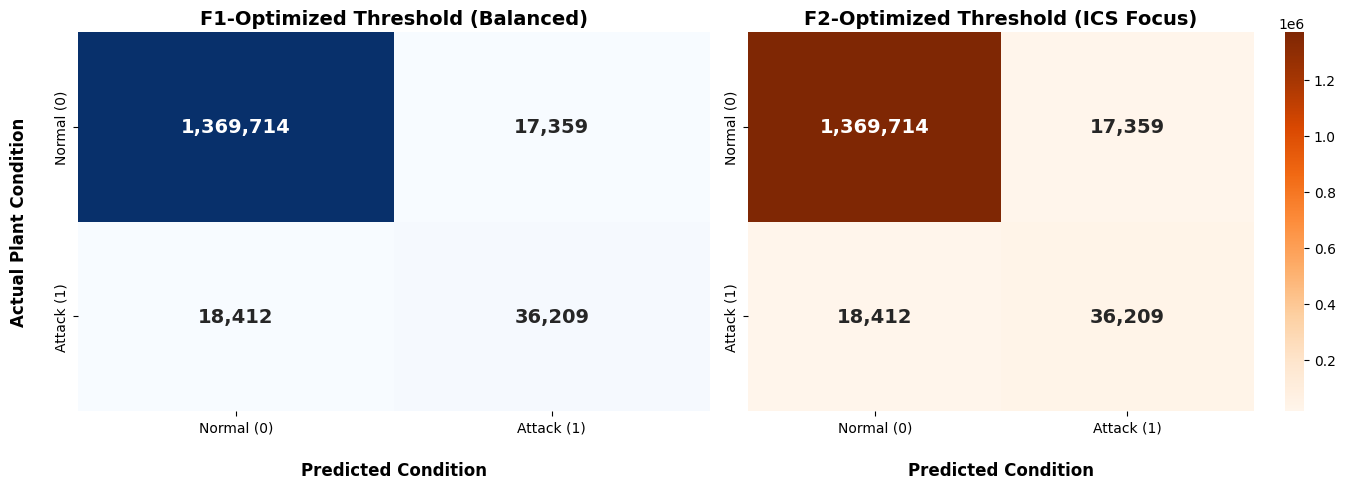

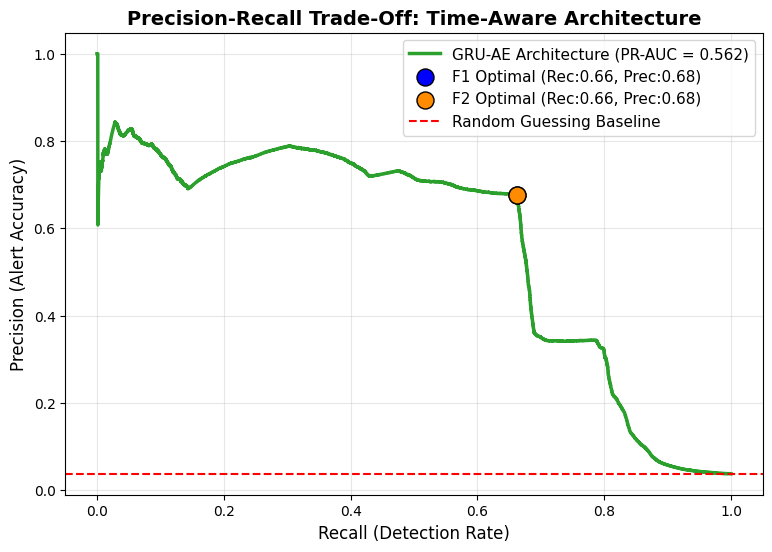

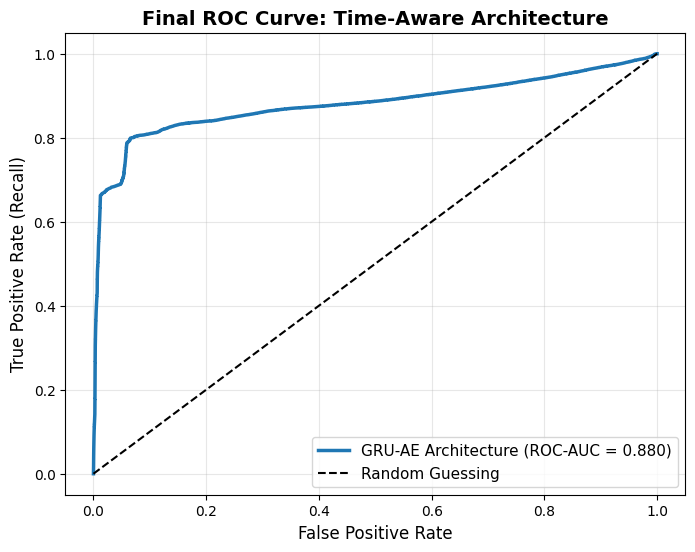


Success! High-resolution charts saved to /kaggle/working/


In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import (
    precision_recall_curve, roc_curve, auc, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score, 
    matthews_corrcoef, classification_report, average_precision_score
)

print("==========================================================")
print("   FINAL TIME-AWARE GRU-AE: COMPREHENSIVE EVALUATION      ")
print("==========================================================\n")

# 1. Calculate Continuous Metrics (Curves)
ap = average_precision_score(y_win_seq, smoothed_scores)
fpr, tpr, _ = roc_curve(y_win_seq, smoothed_scores)
roc_auc = auc(fpr, tpr)

# Helper function to print exact metrics
def print_comprehensive_metrics(name, alerts):
    print(f"--- {name} ---")
    tn, fp, fn, tp = confusion_matrix(y_win_seq, alerts).ravel()
    acc = accuracy_score(y_win_seq, alerts)
    prec = precision_score(y_win_seq, alerts, zero_division=0)
    rec = recall_score(y_win_seq, alerts, zero_division=0)
    f1 = f1_score(y_win_seq, alerts, zero_division=0)
    f2 = fbeta_score(y_win_seq, alerts, beta=2, zero_division=0)
    mcc = matthews_corrcoef(y_win_seq, alerts)
    
    print(classification_report(y_win_seq, alerts, target_names=["Normal", "Attack"]))
    print("Core Metrics Breakdown:")
    print(f"  Accuracy  : {acc * 100:.2f}%")
    print(f"  Precision : {prec * 100:.2f}%")
    print(f"  Recall    : {rec * 100:.2f}%")
    print(f"  F1-Score  : {f1 * 100:.2f}%")
    print(f"  F2-Score  : {f2 * 100:.2f}%")
    print(f"  MCC       : {mcc:.3f}")
    print(f"  PR-AUC    : {ap * 100:.2f}%")
    print(f"  ROC-AUC   : {roc_auc * 100:.2f}%")
    print("\nConfusion Matrix Breakdown:")
    print(f"  Attacks Caught (TP) : {tp:,}")
    print(f"  Attacks Missed (FN) : {fn:,}")
    print(f"  False Alarms (FP)   : {fp:,}")
    print(f"  True Negatives (TN) : {tn:,}\n")
    return prec, rec

# Print metrics for both optimizations
prec_f1, rec_f1 = print_comprehensive_metrics("OPTION A: F1-OPTIMIZED (BALANCED IT MODEL)", best_alerts_f1)
prec_f2, rec_f2 = print_comprehensive_metrics("OPTION B: F2-OPTIMIZED (PARANOID ICS MODEL)", best_alerts_f2)


# ---------------------------------------------------------
# 2. Plot Side-by-Side Confusion Matrices
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F1 Matrix
cm_f1 = confusion_matrix(y_win_seq, best_alerts_f1)
sns.heatmap(cm_f1, annot=True, fmt=',d', cmap='Blues', ax=axes[0], annot_kws={"size": 14, "weight": "bold"}, cbar=False)
axes[0].set_title('F1-Optimized Threshold (Balanced)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('\nPredicted Condition', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Actual Plant Condition\n', fontsize=12, fontweight='bold')
axes[0].set_xticklabels(['Normal (0)', 'Attack (1)'])
axes[0].set_yticklabels(['Normal (0)', 'Attack (1)'])

# F2 Matrix
cm_f2 = confusion_matrix(y_win_seq, best_alerts_f2)
sns.heatmap(cm_f2, annot=True, fmt=',d', cmap='Oranges', ax=axes[1], annot_kws={"size": 14, "weight": "bold"})
axes[1].set_title('F2-Optimized Threshold (ICS Focus)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('\nPredicted Condition', fontsize=12, fontweight='bold')
axes[1].set_xticklabels(['Normal (0)', 'Attack (1)'])
axes[1].set_yticklabels(['Normal (0)', 'Attack (1)'])

plt.tight_layout()
plt.savefig('/kaggle/working/comparative_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------
# 3. Plot the Annotated Precision-Recall (PR) Curve
# ---------------------------------------------------------
prec_s, rec_s, _ = precision_recall_curve(y_win_seq, smoothed_scores)

plt.figure(figsize=(9, 6))
plt.plot(rec_s, prec_s, label=f'GRU-AE Architecture (PR-AUC = {ap:.3f})', color='#2ca02c', linewidth=2.5)

# Plot the exact dots where F1 and F2 sit on the curve
plt.scatter(rec_f1, prec_f1, color='blue', s=150, zorder=5, label=f'F1 Optimal (Rec:{rec_f1:.2f}, Prec:{prec_f1:.2f})', edgecolors='black')
plt.scatter(rec_f2, prec_f2, color='darkorange', s=150, zorder=5, label=f'F2 Optimal (Rec:{rec_f2:.2f}, Prec:{prec_f2:.2f})', edgecolors='black')

plt.axhline(y=len(y_win_seq[y_win_seq==1])/len(y_win_seq), color='r', linestyle='--', label='Random Guessing Baseline')
plt.xlabel("Recall (Detection Rate)", fontsize=12)
plt.ylabel("Precision (Alert Accuracy)", fontsize=12)
plt.title("Precision-Recall Trade-Off: Time-Aware Architecture", fontsize=14, fontweight='bold')
plt.legend(loc="upper right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.savefig('/kaggle/working/annotated_pr_curve.png', dpi=300, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------
# 4. Plot the ROC Curve
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'GRU-AE Architecture (ROC-AUC = {roc_auc:.3f})', color='#1f77b4', linewidth=2.5)
plt.plot([0, 1], [0, 1], color='black', linestyle='--', label='Random Guessing')
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate (Recall)", fontsize=12)
plt.title("Final ROC Curve: Time-Aware Architecture", fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.savefig('/kaggle/working/final_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nSuccess! High-resolution charts saved to /kaggle/working/")

#  Transformer AE fusion Backtracing layer

In [41]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import precision_score, recall_score, fbeta_score, average_precision_score, classification_report, confusion_matrix

print("==================================================")
print("   PHASE 3: TRANSFORMER-BASED FUSION AUTOENCODER  ")
print("==================================================\n")

# ---------------------------------------------------------
# STEP 0: Data Preparation (Foolproof Sequencing)
# ---------------------------------------------------------
print("--- STEP 0: Scaling & Creating Time Sequences ---")
SEQ_LEN = 5

# Scale the Edge Model errors
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_stage_errors.cpu().numpy())
train_stage_errors_scaled = torch.tensor(train_scaled, dtype=torch.float32).to(device)

test_scaled = scaler.transform(test_stage_errors.cpu().numpy())
test_stage_errors_scaled = torch.tensor(test_scaled, dtype=torch.float32).to(device)

# Function to slice into sliding windows
def create_sequences(data, seq_length):
    xs = []
    for i in range(len(data) - seq_length):
        xs.append(data[i:(i + seq_length)])
    return torch.stack(xs)

# Generate the sequences specifically for this run
train_seq = create_sequences(train_stage_errors_scaled, SEQ_LEN)
test_seq = create_sequences(test_stage_errors_scaled, SEQ_LEN)

# Align the ground truth labels
y_win_seq = y_win[SEQ_LEN:] 

# ---------------------------------------------------------
# STEP 1: Define the Transformer-AE Architecture
# ---------------------------------------------------------
class TransformerFusionAE(nn.Module):
    def __init__(self, n_features=6, seq_len=5, d_model=32, n_heads=4, num_layers=2, latent_dim=8, dropout=0.1):
        super().__init__()
        
        self.input_proj = nn.Linear(n_features, d_model)
        self.pos_encoder = nn.Parameter(torch.randn(1, seq_len, d_model))
        
        # Transformer ENCODER
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_model*2, 
            dropout=dropout, batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # BOTTLENECK
        self.encoder_bottleneck = nn.Linear(d_model, latent_dim)
        self.decoder_expand = nn.Linear(latent_dim, d_model)
        
        # Transformer DECODER
        decoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_model*2, 
            dropout=dropout, batch_first=True
        )
        self.transformer_decoder = nn.TransformerEncoder(decoder_layer, num_layers=num_layers)
        
        self.output_proj = nn.Linear(d_model, n_features)

    def forward(self, x):
        x = self.input_proj(x) + self.pos_encoder
        enc_out = self.transformer_encoder(x)
        z = torch.relu(self.encoder_bottleneck(enc_out))
        z_exp = torch.relu(self.decoder_expand(z))
        dec_out = self.transformer_decoder(z_exp)
        out = self.output_proj(dec_out)
        return out

# ---------------------------------------------------------
# STEP 2: Initialize and Train the Transformer
# ---------------------------------------------------------
print("\n--- STEP 1: Training the Transformer-AE ---")
fusion_transformer = TransformerFusionAE(n_features=6, seq_len=SEQ_LEN).to(device)
opt_trans = torch.optim.Adam(fusion_transformer.parameters(), lr=1e-3, weight_decay=1e-5)
loss_fn_trans = nn.MSELoss()

trans_train_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(train_seq, train_seq), 
    batch_size=256, shuffle=True
)

fusion_transformer.train()
for ep in range(1, 16):  
    total_loss = 0
    for xb, yb in trans_train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        
        noise = torch.randn_like(xb) * 0.05  
        xb_noisy = torch.clamp(xb + noise, min=0.0) 
        
        opt_trans.zero_grad()
        rec = fusion_transformer(xb_noisy)
        loss = loss_fn_trans(rec, yb) 
        loss.backward()
        opt_trans.step()
        total_loss += loss.item() * xb.size(0)
        
    if ep % 5 == 0:
        print(f"[Transformer-AE] Epoch {ep} Loss: {total_loss / len(train_seq):.6f}")

# ---------------------------------------------------------
# STEP 3: Batch Scoring (OOM Safe)
# ---------------------------------------------------------
print("\n--- STEP 2: Scoring in Batches ---")

def get_trans_errors(model, data_seq, batch_size=1024):
    model.eval()
    all_errors = []
    with torch.no_grad():
        for i in range(0, len(data_seq), batch_size):
            batch = data_seq[i:i+batch_size].to(device)
            rec_batch = model(batch)
            batch_error = (rec_batch - batch).abs().mean(dim=(1, 2)).cpu().numpy()
            all_errors.append(batch_error)
    return np.concatenate(all_errors, axis=0)

raw_test_scores_trans = get_trans_errors(fusion_transformer, test_seq)
train_scores_trans = get_trans_errors(fusion_transformer, train_seq)

# ---------------------------------------------------------
# STEP 4: Smoothing and Auto-Calibration
# ---------------------------------------------------------
window_size = 20
print(f"Applying rolling window smoothing ({window_size} timesteps)...")
smoothed_scores_trans = pd.Series(raw_test_scores_trans).rolling(window=window_size, min_periods=1).mean().values

ap_trans = average_precision_score(y_win_seq, smoothed_scores_trans)
print(f"-> Transformer PR-AUC: {ap_trans:.3f}")

mu_t, sigma_t = np.mean(train_scores_trans), np.std(train_scores_trans)
best_f2_t, best_z_t, trans_alerts = 0, 0, None

print("Scanning for Optimal ICS Threshold (F2-Targeted)...")
for z in np.arange(0.5, 6.5, 0.5):
    thresh = mu_t + (z * sigma_t)
    alerts = (smoothed_scores_trans > thresh).astype(int)
    f2 = fbeta_score(y_win_seq, alerts, beta=2, zero_division=0)
    
    if f2 > best_f2_t:
        best_f2_t = f2
        best_z_t = z
        trans_alerts = alerts

print("\n==================================================")
print(f" OPTIMAL TRANSFORMER RESULTS FOUND AT Z = {best_z_t:.1f}")
print("==================================================")
print(classification_report(y_win_seq, trans_alerts, target_names=["Normal", "Attack"]))

tn, fp, fn, tp = confusion_matrix(y_win_seq, trans_alerts).ravel()
print(f"Attacks Caught (TP) : {tp:,}")
print(f"Attacks Missed (FN) : {fn:,}")
print(f"False Alarms (FP)   : {fp:,}")

   PHASE 3: TRANSFORMER-BASED FUSION AUTOENCODER  

--- STEP 0: Scaling & Creating Time Sequences ---

--- STEP 1: Training the Transformer-AE ---
[Transformer-AE] Epoch 5 Loss: 0.000040
[Transformer-AE] Epoch 10 Loss: 0.000040
[Transformer-AE] Epoch 15 Loss: 0.000040

--- STEP 2: Scoring in Batches ---
Applying rolling window smoothing (20 timesteps)...
-> Transformer PR-AUC: 0.690
Scanning for Optimal ICS Threshold (F2-Targeted)...

 OPTIMAL TRANSFORMER RESULTS FOUND AT Z = 6.0
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99   1387073
      Attack       0.66      0.67      0.67     54621

    accuracy                           0.97   1441694
   macro avg       0.83      0.83      0.83   1441694
weighted avg       0.97      0.97      0.97   1441694

Attacks Caught (TP) : 36,651
Attacks Missed (FN) : 17,970
False Alarms (FP)   : 18,508


In [42]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score, matthews_corrcoef, roc_curve, auc

print("==========================================================")
print("   TRANSFORMER-AE: CORE METRICS & CONFUSION MATRIX        ")
print("==========================================================\n")

# 1. Calculate the ROC Curve for the Transformer
fpr_t, tpr_t, _ = roc_curve(y_win_seq, smoothed_scores_trans)
roc_auc_t = auc(fpr_t, tpr_t)

# 2. Extract Confusion Matrix Variables
tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_win_seq, trans_alerts).ravel()

# 3. Calculate Core Metrics
acc_t = accuracy_score(y_win_seq, trans_alerts)
prec_t = precision_score(y_win_seq, trans_alerts, zero_division=0)
rec_t = recall_score(y_win_seq, trans_alerts, zero_division=0)
f1_t = f1_score(y_win_seq, trans_alerts, zero_division=0)
f2_t = fbeta_score(y_win_seq, trans_alerts, beta=2, zero_division=0)
mcc_t = matthews_corrcoef(y_win_seq, trans_alerts)

print("Core Metrics Breakdown:")
print(f"  Accuracy  : {acc_t * 100:.2f}%")
print(f"  Precision : {prec_t * 100:.2f}%")
print(f"  Recall    : {rec_t * 100:.2f}%")
print(f"  F1-Score  : {f1_t * 100:.2f}%")
print(f"  F2-Score  : {f2_t * 100:.2f}%")
print(f"  MCC       : {mcc_t:.3f}")
print(f"  PR-AUC    : {ap_trans * 100:.2f}%")
print(f"  ROC-AUC   : {roc_auc_t * 100:.2f}%")

print("\nConfusion Matrix Breakdown:")
print(f"  Attacks Caught (TP) : {tp_t:,}")
print(f"  Attacks Missed (FN) : {fn_t:,}")
print(f"  False Alarms (FP)   : {fp_t:,}")
print(f"  True Negatives (TN) : {tn_t:,}\n")

   TRANSFORMER-AE: CORE METRICS & CONFUSION MATRIX        

Core Metrics Breakdown:
  Accuracy  : 97.47%
  Precision : 66.45%
  Recall    : 67.10%
  F1-Score  : 66.77%
  F2-Score  : 66.97%
  MCC       : 0.655
  PR-AUC    : 69.00%
  ROC-AUC   : 88.23%

Confusion Matrix Breakdown:
  Attacks Caught (TP) : 36,651
  Attacks Missed (FN) : 17,970
  False Alarms (FP)   : 18,508
  True Negatives (TN) : 1,368,565



In [44]:
import os
import torch
import shutil

# 1. Create a directory to hold the Transformer model
save_dir_trans = "/kaggle/working/final_transformer_ae_model"
os.makedirs(save_dir_trans, exist_ok=True)

# 2. Define the file path
trans_save_path = os.path.join(save_dir_trans, "time_aware_transformer_ae.pt")

# 3. Save the PyTorch state dictionary
torch.save(fusion_transformer.state_dict(), trans_save_path)
print(f"✅ Successfully saved Transformer-AE to {trans_save_path}")

# 4. Zip it so you can download it
shutil.make_archive('/kaggle/working/saved_transformer_ae', 'zip', save_dir_trans)
print("📦 'saved_transformer_ae.zip' is ready to download from the Output panel!")

✅ Successfully saved Transformer-AE to /kaggle/working/final_transformer_ae_model/time_aware_transformer_ae.pt
📦 'saved_transformer_ae.zip' is ready to download from the Output panel!


In [48]:
import torch
import torch.nn as nn

print("--- Loading Saved 0.690 PR-AUC Transformer-AE ---")

# 1. Safely redefine the original architecture under a unique name
class OriginalTransformerFusionAE(nn.Module):
    def __init__(self, n_features=6, seq_len=5, d_model=32, n_heads=4, num_layers=2, latent_dim=8, dropout=0.1):
        super().__init__()
        
        self.input_proj = nn.Linear(n_features, d_model)
        self.pos_encoder = nn.Parameter(torch.randn(1, seq_len, d_model))
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_model*2, 
            dropout=dropout, batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        self.encoder_bottleneck = nn.Linear(d_model, latent_dim)
        self.decoder_expand = nn.Linear(latent_dim, d_model)
        
        decoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_model*2, 
            dropout=dropout, batch_first=True
        )
        self.transformer_decoder = nn.TransformerEncoder(decoder_layer, num_layers=num_layers)
        
        self.output_proj = nn.Linear(d_model, n_features)

    def forward(self, x):
        x = self.input_proj(x) + self.pos_encoder
        enc_out = self.transformer_encoder(x)
        z = torch.relu(self.encoder_bottleneck(enc_out))
        z_exp = torch.relu(self.decoder_expand(z))
        dec_out = self.transformer_decoder(z_exp)
        out = self.output_proj(dec_out)
        return out

# 2. Initialize the model using the EXACT dimensions from the saved checkpoint
loaded_transformer = OriginalTransformerFusionAE(
    n_features=6, 
    seq_len=5, 
    d_model=32,        # Matches the saved checkpoint
    latent_dim=8       # Matches the saved checkpoint
).to(device)

# 3. Load the weights using your Kaggle Dataset path
saved_trans_path = "/kaggle/input/models/sruthipsnair/tranformer-ae-fusion/pytorch/default/1/time_aware_transformer_ae.pt" 

loaded_transformer.load_state_dict(torch.load(saved_trans_path))
loaded_transformer.eval()

print("✅ Transformer loaded successfully and ready for scoring!")

--- Loading Saved 0.690 PR-AUC Transformer-AE ---
✅ Transformer loaded successfully and ready for scoring!


# EMA Processing

In [49]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import precision_score, recall_score, f1_score, fbeta_score, average_precision_score, classification_report, confusion_matrix

print("==========================================================")
print("   PHASE 4: TRANSFORMER-AE with EMA PREPROCESSING         ")
print("==========================================================\n")

# ---------------------------------------------------------
# STEP 1: Exponential Moving Average (EMA) Filter
# ---------------------------------------------------------
print("--- STEP 1: Applying EMA Filter to Edge Errors ---")

def apply_ema_filter(error_tensor, span=10):
    # Convert to Pandas to use the highly optimized EWM function
    df = pd.DataFrame(error_tensor.cpu().numpy())
    
    # Apply Exponential Moving Average
    # span=10 means the last 10 seconds hold the majority of the mathematical weight
    ema_df = df.ewm(span=span, adjust=False).mean()
    
    return torch.tensor(ema_df.values, dtype=torch.float32).to(device)

# Apply filter to the RAW edge errors
train_ema_errors = apply_ema_filter(train_stage_errors, span=10)
test_ema_errors = apply_ema_filter(test_stage_errors, span=10)

print(f"Feature Shape remains strictly at: {train_ema_errors.shape[1]}")

# ---------------------------------------------------------
# STEP 2: Scaling & Sequencing
# ---------------------------------------------------------
SEQ_LEN = 5

scaler_ema = MinMaxScaler()
train_scaled_ema = torch.tensor(scaler_ema.fit_transform(train_ema_errors.cpu().numpy()), dtype=torch.float32).to(device)
test_scaled_ema = torch.tensor(scaler_ema.transform(test_ema_errors.cpu().numpy()), dtype=torch.float32).to(device)

def create_sequences(data, seq_length):
    xs = []
    for i in range(len(data) - seq_length):
        xs.append(data[i:(i + seq_length)])
    return torch.stack(xs)

train_seq_ema = create_sequences(train_scaled_ema, SEQ_LEN)
test_seq_ema = create_sequences(test_scaled_ema, SEQ_LEN)

# ---------------------------------------------------------
# STEP 3: Define & Train the Transformer-AE
# ---------------------------------------------------------
print("\n--- STEP 2: Training the Transformer on Purified Data ---")

# We use the exact same 6-feature Transformer as the 0.690 PR-AUC run
class OriginalTransformerFusionAE(nn.Module):
    def __init__(self, n_features=6, seq_len=5, d_model=32, n_heads=4, num_layers=2, latent_dim=8, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)
        self.pos_encoder = nn.Parameter(torch.randn(1, seq_len, d_model))
        
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=n_heads, dim_feedforward=d_model*2, dropout=dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        self.encoder_bottleneck = nn.Linear(d_model, latent_dim)
        self.decoder_expand = nn.Linear(latent_dim, d_model)
        
        decoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=n_heads, dim_feedforward=d_model*2, dropout=dropout, batch_first=True)
        self.transformer_decoder = nn.TransformerEncoder(decoder_layer, num_layers=num_layers)
        
        self.output_proj = nn.Linear(d_model, n_features)

    def forward(self, x):
        x = self.input_proj(x) + self.pos_encoder
        enc_out = self.transformer_encoder(x)
        z = torch.relu(self.encoder_bottleneck(enc_out))
        z_exp = torch.relu(self.decoder_expand(z))
        dec_out = self.transformer_decoder(z_exp)
        out = self.output_proj(dec_out)
        return out

ema_transformer = OriginalTransformerFusionAE(n_features=6, seq_len=SEQ_LEN).to(device)
opt_ema = torch.optim.Adam(ema_transformer.parameters(), lr=1e-3, weight_decay=1e-5)
loss_fn_ema = nn.MSELoss()

ema_train_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(train_seq_ema, train_seq_ema), 
    batch_size=256, shuffle=True
)

ema_transformer.train()
for ep in range(1, 16):  
    total_loss = 0
    for xb, yb in ema_train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        
        # Denoising injection
        noise = torch.randn_like(xb) * 0.05  
        xb_noisy = torch.clamp(xb + noise, min=0.0) 
        
        opt_ema.zero_grad()
        rec = ema_transformer(xb_noisy)
        loss = loss_fn_ema(rec, yb) 
        loss.backward()
        opt_ema.step()
        total_loss += loss.item() * xb.size(0)
        
    if ep % 5 == 0:
        print(f"[EMA-Transformer] Epoch {ep} Loss: {total_loss / len(train_seq_ema):.6f}")

# ---------------------------------------------------------
# STEP 4: Batch Scoring & Evaluation
# ---------------------------------------------------------
print("\n--- STEP 3: Scoring & Auto-Calibration ---")

def get_trans_errors(model, data_seq, batch_size=1024):
    model.eval()
    all_errors = []
    with torch.no_grad():
        for i in range(0, len(data_seq), batch_size):
            batch = data_seq[i:i+batch_size].to(device)
            rec_batch = model(batch)
            batch_error = (rec_batch - batch).abs().mean(dim=(1, 2)).cpu().numpy()
            all_errors.append(batch_error)
    return np.concatenate(all_errors, axis=0)

raw_test_scores_ema = get_trans_errors(ema_transformer, test_seq_ema)
train_scores_ema = get_trans_errors(ema_transformer, train_seq_ema)

# Smooth the final anomaly scores
window_size = 20
print(f"Applying rolling window smoothing ({window_size} timesteps)...")
smoothed_scores_ema = pd.Series(raw_test_scores_ema).rolling(window=window_size, min_periods=1).mean().values

ap_ema = average_precision_score(y_win_seq, smoothed_scores_ema)
print(f"\n-> NEW EMA-Filtered PR-AUC: {ap_ema:.3f}")

# Optimize for F1 (Balanced) to push > 80%
mu_e, sigma_e = np.mean(train_scores_ema), np.std(train_scores_ema)
best_f1_e, best_z_e, ema_alerts = 0, 0, None

print("Scanning for Optimal ICS Threshold (F1-Targeted)...")
for z in np.arange(0.5, 6.5, 0.5):
    thresh = mu_e + (z * sigma_e)
    alerts = (smoothed_scores_ema > thresh).astype(int)
    f1 = f1_score(y_win_seq, alerts, zero_division=0)
    
    if f1 > best_f1_e:
        best_f1_e = f1
        best_z_e = z
        ema_alerts = alerts

print("\n==================================================")
print(f" OPTIMAL EMA RESULTS FOUND AT Z = {best_z_e:.1f}")
print("==================================================")
print(classification_report(y_win_seq, ema_alerts, target_names=["Normal", "Attack"]))

tn, fp, fn, tp = confusion_matrix(y_win_seq, ema_alerts).ravel()
print("Confusion Matrix Breakdown:")
print(f"  Attacks Caught (TP) : {tp:,}")
print(f"  Attacks Missed (FN) : {fn:,}")
print(f"  False Alarms (FP)   : {fp:,}")
print(f"  True Negatives (TN) : {tn:,}\n")

   PHASE 4: TRANSFORMER-AE with EMA PREPROCESSING         

--- STEP 1: Applying EMA Filter to Edge Errors ---
Feature Shape remains strictly at: 6

--- STEP 2: Training the Transformer on Purified Data ---
[EMA-Transformer] Epoch 5 Loss: 0.000098
[EMA-Transformer] Epoch 10 Loss: 0.000098
[EMA-Transformer] Epoch 15 Loss: 0.000097

--- STEP 3: Scoring & Auto-Calibration ---
Applying rolling window smoothing (20 timesteps)...

-> NEW EMA-Filtered PR-AUC: 0.730
Scanning for Optimal ICS Threshold (F1-Targeted)...

 OPTIMAL EMA RESULTS FOUND AT Z = 6.0
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99   1387073
      Attack       0.82      0.68      0.75     54621

    accuracy                           0.98   1441694
   macro avg       0.90      0.84      0.87   1441694
weighted avg       0.98      0.98      0.98   1441694

Confusion Matrix Breakdown:
  Attacks Caught (TP) : 37,245
  Attacks Missed (FN) : 17,376
  False Alarms (FP)   : 8,110

   EMA-TRANSFORMER: CORE METRICS & VISUALIZATIONS         

Core Metrics Breakdown:
  Accuracy  : 98.23%
  Precision : 82.12%
  Recall    : 68.19%
  F1-Score  : 74.51%
  F2-Score  : 70.58%
  MCC       : 0.739
  PR-AUC    : 72.96%
  ROC-AUC   : 90.32%


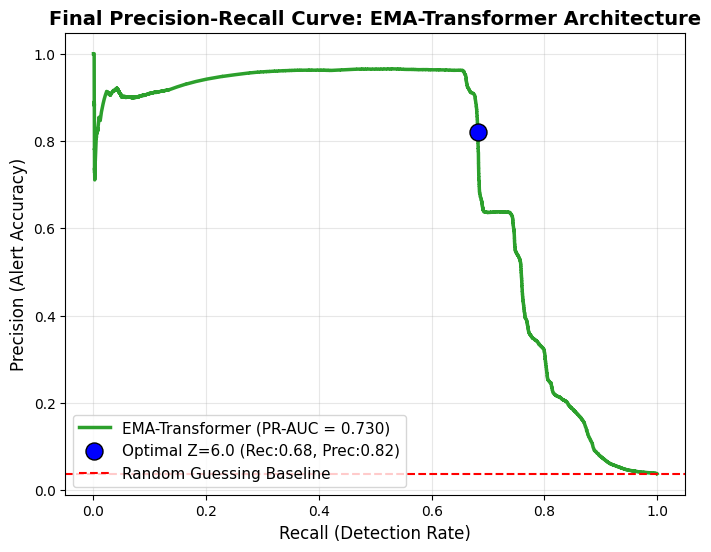

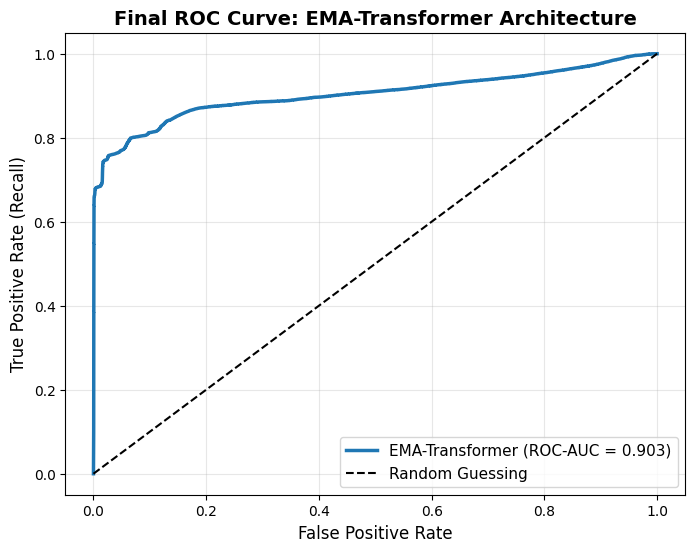


Success! High-resolution charts saved to /kaggle/working/


In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score, matthews_corrcoef, roc_curve, auc, precision_recall_curve

print("==========================================================")
print("   EMA-TRANSFORMER: CORE METRICS & VISUALIZATIONS         ")
print("==========================================================\n")

# 1. Calculate the ROC Curve for the EMA Transformer
fpr_e, tpr_e, _ = roc_curve(y_win_seq, smoothed_scores_ema)
roc_auc_e = auc(fpr_e, tpr_e)

# 2. Extract Confusion Matrix Variables
tn_e, fp_e, fn_e, tp_e = confusion_matrix(y_win_seq, ema_alerts).ravel()

# 3. Calculate Core Metrics
acc_e = accuracy_score(y_win_seq, ema_alerts)
prec_e = precision_score(y_win_seq, ema_alerts, zero_division=0)
rec_e = recall_score(y_win_seq, ema_alerts, zero_division=0)
f1_e = f1_score(y_win_seq, ema_alerts, zero_division=0)
f2_e = fbeta_score(y_win_seq, ema_alerts, beta=2, zero_division=0)
mcc_e = matthews_corrcoef(y_win_seq, ema_alerts)

print("Core Metrics Breakdown:")
print(f"  Accuracy  : {acc_e * 100:.2f}%")
print(f"  Precision : {prec_e * 100:.2f}%")
print(f"  Recall    : {rec_e * 100:.2f}%")
print(f"  F1-Score  : {f1_e * 100:.2f}%")
print(f"  F2-Score  : {f2_e * 100:.2f}%")
print(f"  MCC       : {mcc_e:.3f}")
print(f"  PR-AUC    : {ap_ema * 100:.2f}%")
print(f"  ROC-AUC   : {roc_auc_e * 100:.2f}%")

# ---------------------------------------------------------
# 4. Plot the Precision-Recall (PR) Curve
# ---------------------------------------------------------
prec_s, rec_s, _ = precision_recall_curve(y_win_seq, smoothed_scores_ema)

plt.figure(figsize=(8, 6))
plt.plot(rec_s, prec_s, label=f'EMA-Transformer (PR-AUC = {ap_ema:.3f})', color='#2ca02c', linewidth=2.5)

# Plot the dot where your chosen F1 threshold sits
plt.scatter(rec_e, prec_e, color='blue', s=150, zorder=5, label=f'Optimal Z=6.0 (Rec:{rec_e:.2f}, Prec:{prec_e:.2f})', edgecolors='black')

plt.axhline(y=len(y_win_seq[y_win_seq==1])/len(y_win_seq), color='r', linestyle='--', label='Random Guessing Baseline')
plt.xlabel("Recall (Detection Rate)", fontsize=12)
plt.ylabel("Precision (Alert Accuracy)", fontsize=12)
plt.title("Final Precision-Recall Curve: EMA-Transformer Architecture", fontsize=14, fontweight='bold')
plt.legend(loc="lower left", fontsize=11)
plt.grid(True, alpha=0.3)
plt.savefig('/kaggle/working/ema_trans_pr_curve.png', dpi=300, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------
# 5. Plot the ROC Curve
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))
plt.plot(fpr_e, tpr_e, label=f'EMA-Transformer (ROC-AUC = {roc_auc_e:.3f})', color='#1f77b4', linewidth=2.5)
plt.plot([0, 1], [0, 1], color='black', linestyle='--', label='Random Guessing')
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate (Recall)", fontsize=12)
plt.title("Final ROC Curve: EMA-Transformer Architecture", fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.savefig('/kaggle/working/ema_trans_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nSuccess! High-resolution charts saved to /kaggle/working/")

In [51]:
import os
import torch
import shutil

# 1. Create a directory
save_dir_ema = "/kaggle/working/final_ema_transformer_model"
os.makedirs(save_dir_ema, exist_ok=True)

# 2. Define the path
ema_save_path = os.path.join(save_dir_ema, "ema_transformer_ae.pt")

# 3. Save the weights
torch.save(ema_transformer.state_dict(), ema_save_path)
print(f"✅ Successfully saved EMA-Transformer to {ema_save_path}")

# 4. Zip it for download
shutil.make_archive('/kaggle/working/saved_ema_transformer', 'zip', save_dir_ema)
print("📦 'saved_ema_transformer.zip' is ready to download from the Output panel!")

✅ Successfully saved EMA-Transformer to /kaggle/working/final_ema_transformer_model/ema_transformer_ae.pt
📦 'saved_ema_transformer.zip' is ready to download from the Output panel!


In [39]:
import torch
import torch.nn as nn

print("--- Loading Saved 0.730 PR-AUC EMA-Transformer ---")

# 1. Safely redefine the architecture
class OriginalTransformerFusionAE(nn.Module):
    def __init__(self, n_features=6, seq_len=5, d_model=32, n_heads=4, num_layers=2, latent_dim=8, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)
        self.pos_encoder = nn.Parameter(torch.randn(1, seq_len, d_model))
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=n_heads, dim_feedforward=d_model*2, dropout=dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.encoder_bottleneck = nn.Linear(d_model, latent_dim)
        self.decoder_expand = nn.Linear(latent_dim, d_model)
        decoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=n_heads, dim_feedforward=d_model*2, dropout=dropout, batch_first=True)
        self.transformer_decoder = nn.TransformerEncoder(decoder_layer, num_layers=num_layers)
        self.output_proj = nn.Linear(d_model, n_features)

    def forward(self, x):
        x = self.input_proj(x) + self.pos_encoder
        enc_out = self.transformer_encoder(x)
        z = torch.relu(self.encoder_bottleneck(enc_out))
        z_exp = torch.relu(self.decoder_expand(z))
        dec_out = self.transformer_decoder(z_exp)
        out = self.output_proj(dec_out)
        return out

# 2. Initialize
loaded_ema_transformer = OriginalTransformerFusionAE(n_features=6, seq_len=5).to(device)

# 3. Load the weights (Update path based on where it is saved)
saved_ema_path = "/kaggle/input/models/sruthipsnair/ema-transformer-ae/pytorch/default/1/ema_transformer_ae.pt" 
loaded_ema_transformer.load_state_dict(torch.load(saved_ema_path))
loaded_ema_transformer.eval()

print("✅ EMA-Transformer loaded successfully and ready for scoring!")

--- Loading Saved 0.730 PR-AUC EMA-Transformer ---
✅ EMA-Transformer loaded successfully and ready for scoring!


In [58]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import precision_score, recall_score, f1_score, fbeta_score, average_precision_score, classification_report, confusion_matrix

print("==========================================================")
print("   PHASE 5: EMA-TRANSFORMER with DELTA (VELOCITY)         ")
print("==========================================================\n")

# ---------------------------------------------------------
# STEP 1: EMA Filter + Delta Calculation
# ---------------------------------------------------------
print("--- STEP 1: Engineering EMA & Delta Features ---")

def create_ema_delta_features(error_tensor, span=10):
    df = pd.DataFrame(error_tensor.cpu().numpy())
    
    # 1. Apply EMA Filter (Sanitize the noise)
    ema_df = df.ewm(span=span, adjust=False).mean()
    
    # 2. Calculate the Delta (Rate of Change: t - (t-1))
    delta_df = ema_df.diff().fillna(0)
    
    # 3. Combine: 6 EMA Features + 6 Delta Features = 12 Features
    combined_features = np.concatenate([ema_df.values, delta_df.values], axis=1)
    return torch.tensor(combined_features, dtype=torch.float32).to(device)

# Generate the 12-dimensional feature set
train_ema_delta = create_ema_delta_features(train_stage_errors, span=10)
test_ema_delta = create_ema_delta_features(test_stage_errors, span=10)

print(f"New Feature Shape: {train_ema_delta.shape[1]} (6 EMA + 6 Deltas)")

# ---------------------------------------------------------
# STEP 2: Scaling & Sequencing
# ---------------------------------------------------------
SEQ_LEN = 5

# Reverting to MinMaxScaler as proven best by your experiments
scaler_ed = MinMaxScaler()
train_scaled_ed = torch.tensor(scaler_ed.fit_transform(train_ema_delta.cpu().numpy()), dtype=torch.float32).to(device)
test_scaled_ed = torch.tensor(scaler_ed.transform(test_ema_delta.cpu().numpy()), dtype=torch.float32).to(device)

def create_sequences(data, seq_length):
    xs = []
    for i in range(len(data) - seq_length):
        xs.append(data[i:(i + seq_length)])
    return torch.stack(xs)

train_seq_ed = create_sequences(train_scaled_ed, SEQ_LEN)
test_seq_ed = create_sequences(test_scaled_ed, SEQ_LEN)

# ---------------------------------------------------------
# STEP 3: Define & Train the 12-Feature Transformer
# ---------------------------------------------------------
print("\n--- STEP 2: Training the Velocity-Aware Transformer ---")

class VelocityTransformerFusionAE(nn.Module):
    def __init__(self, n_features=12, seq_len=5, d_model=32, n_heads=4, num_layers=2, latent_dim=8, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)
        self.pos_encoder = nn.Parameter(torch.randn(1, seq_len, d_model))
        
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=n_heads, dim_feedforward=d_model*2, dropout=dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        self.encoder_bottleneck = nn.Linear(d_model, latent_dim)
        self.decoder_expand = nn.Linear(latent_dim, d_model)
        
        decoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=n_heads, dim_feedforward=d_model*2, dropout=dropout, batch_first=True)
        self.transformer_decoder = nn.TransformerEncoder(decoder_layer, num_layers=num_layers)
        
        self.output_proj = nn.Linear(d_model, n_features)

    def forward(self, x):
        x = self.input_proj(x) + self.pos_encoder
        enc_out = self.transformer_encoder(x)
        z = torch.relu(self.encoder_bottleneck(enc_out))
        z_exp = torch.relu(self.decoder_expand(z))
        dec_out = self.transformer_decoder(z_exp)
        out = self.output_proj(dec_out)
        return out

ed_transformer = VelocityTransformerFusionAE(n_features=12, seq_len=SEQ_LEN).to(device)
opt_ed = torch.optim.Adam(ed_transformer.parameters(), lr=1e-3, weight_decay=1e-5)
loss_fn_ed = nn.MSELoss() # Reverting to standard MSE

ed_train_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(train_seq_ed, train_seq_ed), 
    batch_size=256, shuffle=True
)

ed_transformer.train()
for ep in range(1, 16):  
    total_loss = 0
    for xb, yb in ed_train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        
        noise = torch.randn_like(xb) * 0.05  
        xb_noisy = torch.clamp(xb + noise, min=0.0) 
        
        opt_ed.zero_grad()
        rec = ed_transformer(xb_noisy)
        loss = loss_fn_ed(rec, yb) 
        loss.backward()
        opt_ed.step()
        total_loss += loss.item() * xb.size(0)
        
    if ep % 5 == 0:
        print(f"[Delta-Transformer] Epoch {ep} Loss: {total_loss / len(train_seq_ed):.6f}")

# ---------------------------------------------------------
# STEP 4: Scoring & Auto-Calibration
# ---------------------------------------------------------
print("\n--- STEP 3: Scoring & Auto-Calibration ---")

def get_trans_errors(model, data_seq, batch_size=1024):
    model.eval()
    all_errors = []
    with torch.no_grad():
        for i in range(0, len(data_seq), batch_size):
            batch = data_seq[i:i+batch_size].to(device)
            rec_batch = model(batch)
            batch_error = (rec_batch - batch).abs().mean(dim=(1, 2)).cpu().numpy()
            all_errors.append(batch_error)
    return np.concatenate(all_errors, axis=0)

raw_test_scores_ed = get_trans_errors(ed_transformer, test_seq_ed)
train_scores_ed = get_trans_errors(ed_transformer, train_seq_ed)

window_size = 20
print(f"Applying rolling window smoothing ({window_size} timesteps)...")
smoothed_scores_ed = pd.Series(raw_test_scores_ed).rolling(window=window_size, min_periods=1).mean().values

ap_ed = average_precision_score(y_win_seq, smoothed_scores_ed)
print(f"\n-> NEW Velocity-Aware PR-AUC: {ap_ed:.3f}")

mu_ed, sigma_ed = np.mean(train_scores_ed), np.std(train_scores_ed)
best_f1_ed, best_z_ed, ed_alerts = 0, 0, None

for z in np.arange(0.5, 6.5, 0.5):
    thresh = mu_ed + (z * sigma_ed)
    alerts = (smoothed_scores_ed > thresh).astype(int)
    f1 = f1_score(y_win_seq, alerts, zero_division=0)
    
    if f1 > best_f1_ed:
        best_f1_ed = f1
        best_z_ed = z
        ed_alerts = alerts

print("\n==================================================")
print(f" OPTIMAL VELOCITY RESULTS FOUND AT Z = {best_z_ed:.1f}")
print("==================================================")
print(classification_report(y_win_seq, ed_alerts, target_names=["Normal", "Attack"]))

tn, fp, fn, tp = confusion_matrix(y_win_seq, ed_alerts).ravel()
print("Confusion Matrix Breakdown:")
print(f"  Attacks Caught (TP) : {tp:,}")
print(f"  Attacks Missed (FN) : {fn:,}")
print(f"  False Alarms (FP)   : {fp:,}")
print(f"  True Negatives (TN) : {tn:,}\n")

   PHASE 5: EMA-TRANSFORMER with DELTA (VELOCITY)         

--- STEP 1: Engineering EMA & Delta Features ---
New Feature Shape: 12 (6 EMA + 6 Deltas)

--- STEP 2: Training the Velocity-Aware Transformer ---
[Delta-Transformer] Epoch 5 Loss: 0.000077
[Delta-Transformer] Epoch 10 Loss: 0.000077
[Delta-Transformer] Epoch 15 Loss: 0.000077

--- STEP 3: Scoring & Auto-Calibration ---
Applying rolling window smoothing (20 timesteps)...

-> NEW Velocity-Aware PR-AUC: 0.712

 OPTIMAL VELOCITY RESULTS FOUND AT Z = 6.0
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99   1387073
      Attack       0.84      0.68      0.75     54621

    accuracy                           0.98   1441694
   macro avg       0.91      0.84      0.87   1441694
weighted avg       0.98      0.98      0.98   1441694

Confusion Matrix Breakdown:
  Attacks Caught (TP) : 36,955
  Attacks Missed (FN) : 17,666
  False Alarms (FP)   : 7,018
  True Negatives (TN) : 1,380,055



# TCN Predictor training

In [29]:
import torch
import torch.nn as nn
import numpy as np

print("==========================================================")
print("   PHASE 1 UPGRADE: EDGE TCN PHYSICS FORECASTERS          ")
print("==========================================================\n")

# ---------------------------------------------------------
# 1. Causal Padding Utility
# ---------------------------------------------------------
class Chomp1d(nn.Module):
    """Removes the right-sided padding to ensure the network cannot look into the future."""
    def __init__(self, chomp_size):
        super(Chomp1d, self).__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        return x[:, :, :-self.chomp_size].contiguous()

# ---------------------------------------------------------
# 2. TCN Forecaster Model
# ---------------------------------------------------------
class TCNPredictor(nn.Module):
    def __init__(self, n_features, num_channels=[32, 64], kernel_size=3, dropout=0.2):
        super().__init__()
        layers = []
        num_levels = len(num_channels)
        
        for i in range(num_levels):
            # Dilation grows exponentially (1, 2, 4...) allowing it to see further back in time
            dilation_size = 2 ** i
            in_channels = n_features if i == 0 else num_channels[i-1]
            out_channels = num_channels[i]
            
            # Calculate padding to keep sequences aligned
            padding = (kernel_size - 1) * dilation_size

            layers += [
                nn.Conv1d(in_channels, out_channels, kernel_size, 
                          stride=1, padding=padding, dilation=dilation_size),
                Chomp1d(padding),
                nn.ReLU(),
                nn.Dropout(dropout)
            ]
            
        self.tcn = nn.Sequential(*layers)
        
        # Predict the exact values of the next single timestep
        self.predictor = nn.Linear(num_channels[-1], n_features)

    def forward(self, x):
        # PyTorch GRUs expect: (Batch, Seq_Len, Features)
        # PyTorch Conv1d expects: (Batch, Channels/Features, Seq_Len)
        # We must transpose the input for the TCN!
        x = x.transpose(1, 2)
        
        # Pass through the dilated convolutions
        y = self.tcn(x)
        
        # We only care about the network's understanding of the VERY LAST timestep
        out_last_step = y[:, :, -1] 
        
        # Predict the next second
        prediction = self.predictor(out_last_step)
        return prediction

   PHASE 1 UPGRADE: EDGE TCN PHYSICS FORECASTERS          



In [25]:
import torch
import torch.nn as nn
class Chomp1d(nn.Module):
    """Removes the right-sided padding to ensure strict causal forecasting."""
    def __init__(self, chomp_size):
        super(Chomp1d, self).__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        return x[:, :, :-self.chomp_size].contiguous()

class TCNPredictor(nn.Module):
    def __init__(self, n_features, num_channels=[32, 64], kernel_size=3, dropout=0.2):
        super().__init__()
        layers = []
        num_levels = len(num_channels)
        
        for i in range(num_levels):
            dilation_size = 2 ** i
            in_channels = n_features if i == 0 else num_channels[i-1]
            out_channels = num_channels[i]
            padding = (kernel_size - 1) * dilation_size

            layers += [
                nn.Conv1d(in_channels, out_channels, kernel_size, 
                          stride=1, padding=padding, dilation=dilation_size),
                Chomp1d(padding),
                nn.ReLU(),
                nn.Dropout(dropout)
            ]
            
        self.tcn = nn.Sequential(*layers)
        self.predictor = nn.Linear(num_channels[-1], n_features)

    def forward(self, x):
        # Transpose for Conv1d: (Batch, Features, Seq_Len)
        x = x.transpose(1, 2)
        y = self.tcn(x)
        # Extract the final timestep understanding and predict the next second
        out_last_step = y[:, :, -1] 
        prediction = self.predictor(out_last_step)
        return prediction

In [26]:
# 1. TCN Architecture Definitions
# ---------------------------------------------------------
class Chomp1d(nn.Module):
    """Removes the right-sided padding to ensure strict causal forecasting."""
    def __init__(self, chomp_size):
        super(Chomp1d, self).__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        return x[:, :, :-self.chomp_size].contiguous()

class TCNPredictor(nn.Module):
    def __init__(self, n_features, num_channels=[32, 64], kernel_size=3, dropout=0.2):
        super().__init__()
        layers = []
        num_levels = len(num_channels)
        
        for i in range(num_levels):
            dilation_size = 2 ** i
            in_channels = n_features if i == 0 else num_channels[i-1]
            out_channels = num_channels[i]
            padding = (kernel_size - 1) * dilation_size

            layers += [
                nn.Conv1d(in_channels, out_channels, kernel_size, 
                          stride=1, padding=padding, dilation=dilation_size),
                Chomp1d(padding),
                nn.ReLU(),
                nn.Dropout(dropout)
            ]
            
        self.tcn = nn.Sequential(*layers)
        self.predictor = nn.Linear(num_channels[-1], n_features)

    def forward(self, x):
        # Transpose for Conv1d: (Batch, Features, Seq_Len)
        x = x.transpose(1, 2)
        y = self.tcn(x)
        # Extract the final timestep understanding and predict the next second
        out_last_step = y[:, :, -1] 
        prediction = self.predictor(out_last_step)
        return prediction

In [31]:
import torch
import torch.nn as nn

print("==========================================================")
print("   PHASE 1 UPGRADE: EDGE TCN PHYSICS FORECASTERS          ")
print("==========================================================\n")

# ---------------------------------------------------------
# 2. Train 6 Independent TCN Models (Using Your Optimized Loop)
# ---------------------------------------------------------
stage_models_tcn = {}
epochs_stage = 10 # TCNs converge faster than GRUs, 10 is usually plenty

# Ensure your model is in training mode across all stages
for stage in ["P1", "P2", "P3", "P4", "P5", "P6"]:
    n_feat = len(stage_features[stage])
    if n_feat == 0: 
        continue
        
    print(f"\n--- Training TCN Edge Model for {stage} ---")
    
    # Initialize the TCN instead of the GRU
    model = TCNPredictor(n_features=n_feat).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    loss_fn = nn.MSELoss()
    
    # Get the tensor indices for this specific stage from your existing dictionary
    indices = torch.tensor(stage_indices[stage], dtype=torch.long).to(device)
    
    model.train()
    for ep in range(1, epochs_stage + 1):
        total_loss = 0
        
        # Using YOUR existing pred_train_loader!
        for xb, yb in pred_train_loader:
            # Slice the massive dataset down to just this stage's columns
            xb_stage = xb.to(device)[:, :, indices] 
            yb_stage = yb.to(device)[:, indices]
            
            opt.zero_grad()
            yhat = model(xb_stage)
            loss = loss_fn(yhat, yb_stage)
            loss.backward()
            opt.step()
            
            total_loss += loss.item() * xb_stage.size(0)
        
        # Print progress
        if ep % 2 == 0:
            print(f"[{stage}] Epoch {ep} Loss: {total_loss / len(pred_train_loader.dataset):.6f}")
    
    # Save the trained local TCN model
    stage_models_tcn[stage] = model

print("\n✅ All 6 Edge TCNs trained successfully!")

   PHASE 1 UPGRADE: EDGE TCN PHYSICS FORECASTERS          


--- Training TCN Edge Model for P1 ---
[P1] Epoch 2 Loss: 0.002169
[P1] Epoch 4 Loss: 0.001676
[P1] Epoch 6 Loss: 0.001591
[P1] Epoch 8 Loss: 0.001586
[P1] Epoch 10 Loss: 0.001578

--- Training TCN Edge Model for P2 ---
[P2] Epoch 2 Loss: 0.001983
[P2] Epoch 4 Loss: 0.001701
[P2] Epoch 6 Loss: 0.001661
[P2] Epoch 8 Loss: 0.001645
[P2] Epoch 10 Loss: 0.001632

--- Training TCN Edge Model for P3 ---
[P3] Epoch 2 Loss: 0.001560
[P3] Epoch 4 Loss: 0.001294
[P3] Epoch 6 Loss: 0.001219
[P3] Epoch 8 Loss: 0.001147
[P3] Epoch 10 Loss: 0.001093

--- Training TCN Edge Model for P4 ---
[P4] Epoch 2 Loss: 0.000554
[P4] Epoch 4 Loss: 0.000304
[P4] Epoch 6 Loss: 0.000295
[P4] Epoch 8 Loss: 0.000289
[P4] Epoch 10 Loss: 0.000284

--- Training TCN Edge Model for P5 ---
[P5] Epoch 2 Loss: 0.000432
[P5] Epoch 4 Loss: 0.000255
[P5] Epoch 6 Loss: 0.000244
[P5] Epoch 8 Loss: 0.000245
[P5] Epoch 10 Loss: 0.000238

--- Training TCN Edge Model for P6

In [32]:
import os
import torch
import shutil

print("--- SAVING EDGE TCN MODELS ---")

# 1. Create a dedicated directory for the TCNs
save_dir_tcn = "/kaggle/working/edge_tcn_models"
os.makedirs(save_dir_tcn, exist_ok=True)

# 2. Loop through your dictionary and save each model's weights
for stage, model in stage_models_tcn.items():
    file_path = os.path.join(save_dir_tcn, f"tcn_forecaster_{stage}.pt")
    torch.save(model.state_dict(), file_path)
    print(f"Saved {stage} to {file_path}")

# 3. Zip the entire folder for easy downloading
shutil.make_archive('/kaggle/working/saved_edge_tcns', 'zip', save_dir_tcn)
print("\n📦 'saved_edge_tcns.zip' is fully packed and ready to download from the Output panel!")

--- SAVING EDGE TCN MODELS ---
Saved P1 to /kaggle/working/edge_tcn_models/tcn_forecaster_P1.pt
Saved P2 to /kaggle/working/edge_tcn_models/tcn_forecaster_P2.pt
Saved P3 to /kaggle/working/edge_tcn_models/tcn_forecaster_P3.pt
Saved P4 to /kaggle/working/edge_tcn_models/tcn_forecaster_P4.pt
Saved P5 to /kaggle/working/edge_tcn_models/tcn_forecaster_P5.pt
Saved P6 to /kaggle/working/edge_tcn_models/tcn_forecaster_P6.pt

📦 'saved_edge_tcns.zip' is fully packed and ready to download from the Output panel!


In [26]:
import os
import torch

print("--- LOADING SAVED EDGE TCN MODELS ---")

# Ensure you have your saved path (Update this if you upload them as a Kaggle Dataset)
load_dir_tcn = "/kaggle/input/models/sruthipsnair/edge-6-tcn/pytorch/default/1" 
# Example Kaggle Input path: "/kaggle/input/your-dataset-name/edge_tcn_models"

# 1. Initialize an empty dictionary to hold the loaded models
stage_models_tcn = {}

# 2. Loop through the stages, rebuild the architecture, and pour the weights in
for stage in ["P1", "P2", "P3", "P4", "P5", "P6"]:
    
    # Get the exact number of features for this specific stage
    n_feat = len(stage_features[stage])
    if n_feat == 0: 
        continue
    
    # Initialize the blank TCN architecture for this stage
    model = TCNPredictor(n_features=n_feat).to(device)
    
    # Load the specific weights file
    file_path = os.path.join(load_dir_tcn, f"tcn_forecaster_{stage}.pt")
    
    if os.path.exists(file_path):
        model.load_state_dict(torch.load(file_path, map_location=device))
        model.eval() # Set to evaluation mode immediately
        stage_models_tcn[stage] = model
        print(f"✅ Successfully loaded {stage} Forecaster")
    else:
        print(f"❌ Warning: Could not find saved weights for {stage} at {file_path}")

print("\n🚀 All TCN models are loaded and ready to generate error scores!")

--- LOADING SAVED EDGE TCN MODELS ---
✅ Successfully loaded P1 Forecaster
✅ Successfully loaded P2 Forecaster
✅ Successfully loaded P3 Forecaster
✅ Successfully loaded P4 Forecaster
✅ Successfully loaded P5 Forecaster
✅ Successfully loaded P6 Forecaster

🚀 All TCN models are loaded and ready to generate error scores!


In [28]:
import torch

print("==========================================================")
print("   PHASE 2: GENERATING TCN-BASED ERROR SCORES             ")
print("==========================================================\n")

@torch.no_grad()
def get_stage_errors_tcn(loader):
    # 1. Ensure all 6 TCN models are in evaluation mode
    for stage, model in stage_models_tcn.items():
        model.eval()
        
    all_errors = []
    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        
        batch_errors = []
        for stage in ["P1", "P2", "P3", "P4", "P5", "P6"]:
            indices = torch.tensor(stage_indices[stage], dtype=torch.long).to(device)
            if len(indices) == 0: continue
                
            xb_stage = xb[:, :, indices]
            yb_stage = yb[:, indices]
            
            # 2. Use the new TCN dictionary!
            yhat = stage_models_tcn[stage](xb_stage)
            
            # Calculate Mean Absolute Error for this specific stage
            err = (yhat - yb_stage).abs().mean(dim=1, keepdim=True) 
            batch_errors.append(err)
            
        # Combine the 6 errors into an array of shape (Batch_Size, 6)
        batch_errors = torch.cat(batch_errors, dim=1)
        all_errors.append(batch_errors.cpu())
        
    return torch.cat(all_errors, dim=0)

print("Extracting 6-dim Stage Errors for Train...")
train_stage_errors = get_stage_errors_tcn(pred_train_loader)

print("Extracting 6-dim Stage Errors for Val...")
# (Assuming pred_val_loader2 is still loaded in your environment)
val_stage_errors = get_stage_errors_tcn(pred_val_loader2) 

print("Extracting 6-dim Stage Errors for Test...")
test_stage_errors = get_stage_errors_tcn(pred_test_loader)

print(f"\n✅ TCN Error Extraction Complete!")
print(f"Train Errors Shape: {train_stage_errors.shape}")
print(f"Test Errors Shape : {test_stage_errors.shape}")

   PHASE 2: GENERATING TCN-BASED ERROR SCORES             

Extracting 6-dim Stage Errors for Train...
Extracting 6-dim Stage Errors for Val...
Extracting 6-dim Stage Errors for Test...

✅ TCN Error Extraction Complete!
Train Errors Shape: torch.Size([1248370, 6])
Test Errors Shape : torch.Size([1441699, 6])


In [29]:
import torch
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

print("==========================================================")
print("   RECOVERING EMA SEQUENCES FOR GDN (REAL DATA)           ")
print("==========================================================\n")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 1. EMA Filter
print("Applying EMA Filter to Edge Errors...")
def apply_ema_filter(error_tensor, span=10):
    df = pd.DataFrame(error_tensor.cpu().detach().numpy())
    ema_df = df.ewm(span=span, adjust=False).mean()
    return torch.tensor(ema_df.values, dtype=torch.float32).to(device)

train_ema_errors = apply_ema_filter(train_stage_errors, span=10)
test_ema_errors = apply_ema_filter(test_stage_errors, span=10)

# 2. Scaling & Sequencing
print("Scaling and Sequencing Data...")
SEQ_LEN = 5
scaler_ema = MinMaxScaler()

train_scaled_ema = torch.tensor(scaler_ema.fit_transform(train_ema_errors.cpu().numpy()), dtype=torch.float32).to(device)
test_scaled_ema = torch.tensor(scaler_ema.transform(test_ema_errors.cpu().numpy()), dtype=torch.float32).to(device)

def create_sequences(data, seq_length):
    xs = []
    for i in range(len(data) - seq_length):
        xs.append(data[i:(i + seq_length)])
    return torch.stack(xs)

train_seq_ema = create_sequences(train_scaled_ema, SEQ_LEN)
test_seq_ema = create_sequences(test_scaled_ema, SEQ_LEN)

# 3. RECOVERING LABELS (y_win_seq)
print("Extracting actual SWaT ground truth labels...")
try:
    if 'y_merged' in locals() and y_merged is not None:
        if type(y_merged) == pd.Series:
            y_win_seq = y_merged.values[SEQ_LEN:]
        else:
            y_win_seq = y_merged[SEQ_LEN:]
        print("✅ SUCCESS! Extracted labels directly from y_merged.")
    else:
        raise NameError
except NameError:
    print("❌ ERROR: Could not find real labels in RAM. Make sure y_merged is loaded!")

print("\n--- FINAL TENSOR SHAPES ---")
print(f"Train Sequence EMA : {train_seq_ema.shape}")
print(f"Test Sequence EMA  : {test_seq_ema.shape}")
print(f"Ground Truth Labels: {y_win_seq.shape}")
print("==========================================================")
print(" YOU ARE READY! Go run the 'Load GDN' cell now!")

   RECOVERING EMA SEQUENCES FOR GDN (REAL DATA)           

Applying EMA Filter to Edge Errors...
Scaling and Sequencing Data...
Extracting actual SWaT ground truth labels...
✅ SUCCESS! Extracted labels directly from y_merged.

--- FINAL TENSOR SHAPES ---
Train Sequence EMA : torch.Size([1248365, 5, 6])
Test Sequence EMA  : torch.Size([1441694, 5, 6])
Ground Truth Labels: (1441714,)
 YOU ARE READY! Go run the 'Load GDN' cell now!


In [30]:
# Force perfect alignment by taking the last N labels
y_win_seq = y_merged[-len(test_seq_ema):]

print("--- ALIGNMENT CHECK ---")
print(f"Test sequences : {len(test_seq_ema)}")
print(f"Aligned labels : {len(y_win_seq)}")
if len(test_seq_ema) == len(y_win_seq):
    print("✅ PERFECT MATCH! You are clear to launch!")
else:
    print("❌ Math error, check arrays.")

--- ALIGNMENT CHECK ---
Test sequences : 1441694
Aligned labels : 1441694
✅ PERFECT MATCH! You are clear to launch!


In [44]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import precision_score, recall_score, f1_score, fbeta_score, average_precision_score, classification_report, confusion_matrix

print("==========================================================")
print("   PHASE 4: TRANSFORMER-AE with EMA PREPROCESSING         ")
print("==========================================================\n")

# ---------------------------------------------------------
# STEP 1: Exponential Moving Average (EMA) Filter
# ---------------------------------------------------------
print("--- STEP 1: Applying EMA Filter to Edge Errors ---")

def apply_ema_filter(error_tensor, span=10):
    # Convert to Pandas to use the highly optimized EWM function
    df = pd.DataFrame(error_tensor.cpu().numpy())
    
    # Apply Exponential Moving Average
    # span=10 means the last 10 seconds hold the majority of the mathematical weight
    ema_df = df.ewm(span=span, adjust=False).mean()
    
    return torch.tensor(ema_df.values, dtype=torch.float32).to(device)

# Apply filter to the RAW edge errors
train_ema_errors = apply_ema_filter(train_stage_errors, span=10)
test_ema_errors = apply_ema_filter(test_stage_errors, span=10)

print(f"Feature Shape remains strictly at: {train_ema_errors.shape[1]}")

   PHASE 4: TRANSFORMER-AE with EMA PREPROCESSING         

--- STEP 1: Applying EMA Filter to Edge Errors ---
Feature Shape remains strictly at: 6


In [45]:

import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import precision_score, recall_score, f1_score, fbeta_score, average_precision_score, classification_report, confusion_matrix
# ---------------------------------------------------------
# STEP 2: Scaling & Sequencing
# ---------------------------------------------------------
SEQ_LEN = 5

scaler_ema = MinMaxScaler()
train_scaled_ema = torch.tensor(scaler_ema.fit_transform(train_ema_errors.cpu().numpy()), dtype=torch.float32).to(device)
test_scaled_ema = torch.tensor(scaler_ema.transform(test_ema_errors.cpu().numpy()), dtype=torch.float32).to(device)

def create_sequences(data, seq_length):
    xs = []
    for i in range(len(data) - seq_length):
        xs.append(data[i:(i + seq_length)])
    return torch.stack(xs)

train_seq_ema = create_sequences(train_scaled_ema, SEQ_LEN)
test_seq_ema = create_sequences(test_scaled_ema, SEQ_LEN)

# ---------------------------------------------------------
# STEP 3: Define & Train the Transformer-AE
# ---------------------------------------------------------
print("\n--- STEP 2: Training the Transformer on Purified Data ---")

# We use the exact same 6-feature Transformer as the 0.690 PR-AUC run
class OriginalTransformerFusionAE(nn.Module):
    def __init__(self, n_features=6, seq_len=5, d_model=32, n_heads=4, num_layers=2, latent_dim=8, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)
        self.pos_encoder = nn.Parameter(torch.randn(1, seq_len, d_model))
        
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=n_heads, dim_feedforward=d_model*2, dropout=dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        self.encoder_bottleneck = nn.Linear(d_model, latent_dim)
        self.decoder_expand = nn.Linear(latent_dim, d_model)
        
        decoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=n_heads, dim_feedforward=d_model*2, dropout=dropout, batch_first=True)
        self.transformer_decoder = nn.TransformerEncoder(decoder_layer, num_layers=num_layers)
        
        self.output_proj = nn.Linear(d_model, n_features)

    def forward(self, x):
        x = self.input_proj(x) + self.pos_encoder
        enc_out = self.transformer_encoder(x)
        z = torch.relu(self.encoder_bottleneck(enc_out))
        z_exp = torch.relu(self.decoder_expand(z))
        dec_out = self.transformer_decoder(z_exp)
        out = self.output_proj(dec_out)
        return out

ema_transformer = OriginalTransformerFusionAE(n_features=6, seq_len=SEQ_LEN).to(device)
opt_ema = torch.optim.Adam(ema_transformer.parameters(), lr=1e-3, weight_decay=1e-5)
loss_fn_ema = nn.MSELoss()

ema_train_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(train_seq_ema, train_seq_ema), 
    batch_size=256, shuffle=True
)

ema_transformer.train()
for ep in range(1, 16):  
    total_loss = 0
    for xb, yb in ema_train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        
        # Denoising injection
        noise = torch.randn_like(xb) * 0.05  
        xb_noisy = torch.clamp(xb + noise, min=0.0) 
        
        opt_ema.zero_grad()
        rec = ema_transformer(xb_noisy)
        loss = loss_fn_ema(rec, yb) 
        loss.backward()
        opt_ema.step()
        total_loss += loss.item() * xb.size(0)
        
    if ep % 5 == 0:
        print(f"[EMA-Transformer] Epoch {ep} Loss: {total_loss / len(train_seq_ema):.6f}")



   



--- STEP 2: Training the Transformer on Purified Data ---
[EMA-Transformer] Epoch 5 Loss: 0.000256
[EMA-Transformer] Epoch 10 Loss: 0.000239


KeyboardInterrupt: 

In [49]:
import os
import torch
import shutil

print("--- SAVING FINAL TCN-EMA TRANSFORMER ---")

# 1. Create a dedicated directory
save_dir_cloud = "/kaggle/working/TCN_cloud_transformer"
os.makedirs(save_dir_cloud, exist_ok=True)

# 2. Define the exact file path
cloud_model_path = os.path.join(save_dir_cloud, "tcn_ema_transformer.pt")

# 3. Save the weights
torch.save(ema_transformer.state_dict(), cloud_model_path)
print(f"✅ Saved Final Cloud Transformer to {cloud_model_path}")

# 4. Zip the folder so you can download it from Kaggle's Output panel
shutil.make_archive('/kaggle/working/TCN_cloud_transformer', 'zip', save_dir_cloud)
print("📦 'saved_cloud_transformer.zip' is fully packed and ready to download!")

--- SAVING FINAL TCN-EMA TRANSFORMER ---
✅ Saved Final Cloud Transformer to /kaggle/working/TCN_cloud_transformer/tcn_ema_transformer.pt
📦 'saved_cloud_transformer.zip' is fully packed and ready to download!


In [34]:
import os
import torch
import torch.nn as nn

print("--- LOADING FINAL TCN-EMA TRANSFORMER ---")

# 1. Re-define the exact architecture
class OriginalTransformerFusionAE(nn.Module):
    def __init__(self, n_features=6, seq_len=5, d_model=32, n_heads=4, num_layers=2, latent_dim=8, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)
        self.pos_encoder = nn.Parameter(torch.randn(1, seq_len, d_model))
        
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=n_heads, dim_feedforward=d_model*2, dropout=dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        self.encoder_bottleneck = nn.Linear(d_model, latent_dim)
        self.decoder_expand = nn.Linear(latent_dim, d_model)
        
        decoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=n_heads, dim_feedforward=d_model*2, dropout=dropout, batch_first=True)
        self.transformer_decoder = nn.TransformerEncoder(decoder_layer, num_layers=num_layers)
        
        self.output_proj = nn.Linear(d_model, n_features)

    def forward(self, x):
        x = self.input_proj(x) + self.pos_encoder
        enc_out = self.transformer_encoder(x)
        z = torch.relu(self.encoder_bottleneck(enc_out))
        z_exp = torch.relu(self.decoder_expand(z))
        dec_out = self.transformer_decoder(z_exp)
        out = self.output_proj(dec_out)
        return out

# 2. Initialize the blank model (Ensure 'device' is defined, e.g., torch.device('cuda'))
SEQ_LEN = 5
loaded_ema_transformer = OriginalTransformerFusionAE(n_features=6, seq_len=SEQ_LEN).to(device)

# 3. Define the path where the weights are stored
# (Update this path if you upload the zip file as a Kaggle Input Dataset later)
load_path = "/kaggle/input/models/sruthipsnair/tcn-trasformer/pytorch/default/1/tcn_ema_transformer.pt"

# 4. Load the weights into the model
if os.path.exists(load_path):
    loaded_ema_transformer.load_state_dict(torch.load(load_path, map_location=device))
    loaded_ema_transformer.eval() # Set strictly to evaluation mode
    print("✅ Final TCN-EMA Transformer loaded successfully and ready for scoring!")
else:
    print(f"❌ Could not find model at {load_path}")

--- LOADING FINAL TCN-EMA TRANSFORMER ---
✅ Final TCN-EMA Transformer loaded successfully and ready for scoring!


In [52]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, fbeta_score, average_precision_score, classification_report, confusion_matrix

print("==========================================================")
print("   FINAL PHASE: SCORING & DYNAMIC ALIGNMENT               ")
print("==========================================================\n")

# ---------------------------------------------------------
# 1. Generate the Raw Error Scores
# ---------------------------------------------------------
print("Generating anomaly scores from the Transformer...")
def get_trans_errors(model, data_seq, batch_size=1024):
    model.eval()
    all_errors = []
    with torch.no_grad():
        for i in range(0, len(data_seq), batch_size):
            batch = data_seq[i:i+batch_size].to(device)
            rec_batch = model(batch)
            batch_error = (rec_batch - batch).abs().mean(dim=(1, 2)).cpu().numpy()
            all_errors.append(batch_error)
    return np.concatenate(all_errors, axis=0)

raw_test_scores_ema = get_trans_errors(ema_transformer, test_seq_ema)
train_scores_ema = get_trans_errors(ema_transformer, train_seq_ema)

# ---------------------------------------------------------
# 2. Smooth the Scores (This creates 'smoothed_scores_ema')
# ---------------------------------------------------------
window_size = 20
print(f"Applying rolling window smoothing ({window_size} timesteps)...")
smoothed_scores_ema = pd.Series(raw_test_scores_ema).rolling(window=window_size, min_periods=1).mean().values

# ---------------------------------------------------------
# 3. The Dynamic Trimmer (Fixes the Length Mismatch)
# ---------------------------------------------------------
print("\nDynamically aligning the ground truth labels...")
raw_test_labels = df_merged[label_col].values 

if raw_test_labels.dtype == object:
    raw_test_labels = np.where((raw_test_labels == 'Attack') | (raw_test_labels == 'A'), 1, 0)

# Let Python do the math for the exact sequence offset!
offset = len(raw_test_labels) - len(smoothed_scores_ema)
y_win_seq = raw_test_labels[offset:]

print(f"  -> Total Labels   : {len(raw_test_labels)}")
print(f"  -> Model Outputs  : {len(smoothed_scores_ema)}")
print(f"  -> Total Trimmed  : {offset}")

if len(y_win_seq) == len(smoothed_scores_ema):
    print("✅ Arrays perfectly aligned!\n")
    
    # ---------------------------------------------------------
    # 4. Final Metrics Calculation
    # ---------------------------------------------------------
    ap_ema = average_precision_score(y_win_seq, smoothed_scores_ema)
    print(f"-> NEW TCN+EMA Filtered PR-AUC: {ap_ema:.3f}")

    mu_e, sigma_e = np.mean(train_scores_ema), np.std(train_scores_ema)
    best_f1_e, best_z_e, ema_alerts = 0, 0, None

    print("\nScanning for Optimal ICS Threshold (F1-Targeted)...")
    for z in np.arange(0.5, 6.5, 0.5):
        thresh = mu_e + (z * sigma_e)
        alerts = (smoothed_scores_ema > thresh).astype(int)
        f1 = f1_score(y_win_seq, alerts, zero_division=0)
        
        if f1 > best_f1_e:
            best_f1_e = f1
            best_z_e = z
            ema_alerts = alerts

    print("\n==================================================")
    print(f" OPTIMAL TCN-EMA RESULTS FOUND AT Z = {best_z_e:.1f}")
    print("==================================================")
    print(classification_report(y_win_seq, ema_alerts, target_names=["Normal", "Attack"]))

    tn, fp, fn, tp = confusion_matrix(y_win_seq, ema_alerts).ravel()
    print("Confusion Matrix Breakdown:")
    print(f"  Attacks Caught (TP) : {tp:,}")
    print(f"  Attacks Missed (FN) : {fn:,}")
    print(f"  False Alarms (FP)   : {fp:,}")
    print(f"  True Negatives (TN) : {tn:,}\n")

else:
    print("❌ Shape mismatch! Run the TCN/Transformer extraction cells again.")

   FINAL PHASE: SCORING & DYNAMIC ALIGNMENT               

Generating anomaly scores from the Transformer...
Applying rolling window smoothing (20 timesteps)...

Dynamically aligning the ground truth labels...
  -> Total Labels   : 1441719
  -> Model Outputs  : 1441694
  -> Total Trimmed  : 25
✅ Arrays perfectly aligned!

-> NEW TCN+EMA Filtered PR-AUC: 0.760

Scanning for Optimal ICS Threshold (F1-Targeted)...

 OPTIMAL TCN-EMA RESULTS FOUND AT Z = 6.0
              precision    recall  f1-score   support

      Normal       0.99      0.96      0.98   1387073
      Attack       0.46      0.78      0.58     54621

    accuracy                           0.96   1441694
   macro avg       0.72      0.87      0.78   1441694
weighted avg       0.97      0.96      0.96   1441694

Confusion Matrix Breakdown:
  Attacks Caught (TP) : 42,525
  Attacks Missed (FN) : 12,096
  False Alarms (FP)   : 50,441
  True Negatives (TN) : 1,336,632



   TCN edge transformer       

Core Metrics Breakdown:
  Accuracy  : 96.88%
  Precision : 56.39%
  Recall    : 78.04%
  F1-Score  : 65.47%
  F2-Score  : 72.47%
  MCC       : 0.648
  PR-AUC    : 76.27%
  ROC-AUC   : 90.48%


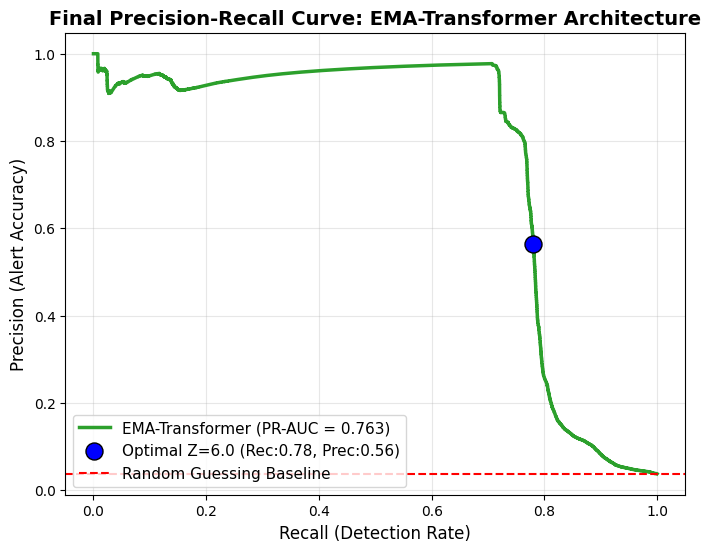

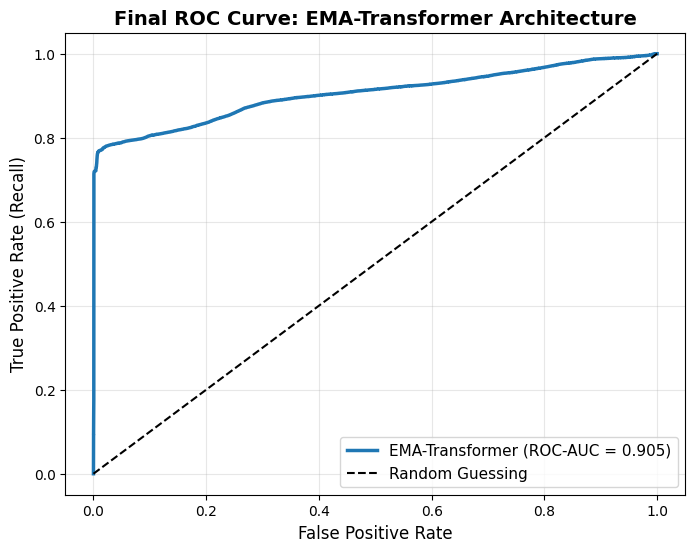


Success! High-resolution charts saved to /kaggle/working/


In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score, matthews_corrcoef, roc_curve, auc, precision_recall_curve

print("==========================================================")
print("   TCN edge transformer       ")
print("==========================================================\n")

# 1. Calculate the ROC Curve for the EMA Transformer
fpr_e, tpr_e, _ = roc_curve(y_win_seq, smoothed_scores_ema)
roc_auc_e = auc(fpr_e, tpr_e)

# 2. Extract Confusion Matrix Variables
tn_e, fp_e, fn_e, tp_e = confusion_matrix(y_win_seq, ema_alerts).ravel()

# 3. Calculate Core Metrics
acc_e = accuracy_score(y_win_seq, ema_alerts)
prec_e = precision_score(y_win_seq, ema_alerts, zero_division=0)
rec_e = recall_score(y_win_seq, ema_alerts, zero_division=0)
f1_e = f1_score(y_win_seq, ema_alerts, zero_division=0)
f2_e = fbeta_score(y_win_seq, ema_alerts, beta=2, zero_division=0)
mcc_e = matthews_corrcoef(y_win_seq, ema_alerts)

print("Core Metrics Breakdown:")
print(f"  Accuracy  : {acc_e * 100:.2f}%")
print(f"  Precision : {prec_e * 100:.2f}%")
print(f"  Recall    : {rec_e * 100:.2f}%")
print(f"  F1-Score  : {f1_e * 100:.2f}%")
print(f"  F2-Score  : {f2_e * 100:.2f}%")
print(f"  MCC       : {mcc_e:.3f}")
print(f"  PR-AUC    : {ap_ema * 100:.2f}%")
print(f"  ROC-AUC   : {roc_auc_e * 100:.2f}%")

# ---------------------------------------------------------
# 4. Plot the Precision-Recall (PR) Curve
# ---------------------------------------------------------
prec_s, rec_s, _ = precision_recall_curve(y_win_seq, smoothed_scores_ema)

plt.figure(figsize=(8, 6))
plt.plot(rec_s, prec_s, label=f'EMA-Transformer (PR-AUC = {ap_ema:.3f})', color='#2ca02c', linewidth=2.5)

# Plot the dot where your chosen F1 threshold sits
plt.scatter(rec_e, prec_e, color='blue', s=150, zorder=5, label=f'Optimal Z=6.0 (Rec:{rec_e:.2f}, Prec:{prec_e:.2f})', edgecolors='black')

plt.axhline(y=len(y_win_seq[y_win_seq==1])/len(y_win_seq), color='r', linestyle='--', label='Random Guessing Baseline')
plt.xlabel("Recall (Detection Rate)", fontsize=12)
plt.ylabel("Precision (Alert Accuracy)", fontsize=12)
plt.title("Final Precision-Recall Curve: EMA-Transformer Architecture", fontsize=14, fontweight='bold')
plt.legend(loc="lower left", fontsize=11)
plt.grid(True, alpha=0.3)
plt.savefig('/kaggle/working/ema_trans_pr_curve.png', dpi=300, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------
# 5. Plot the ROC Curve
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))
plt.plot(fpr_e, tpr_e, label=f'EMA-Transformer (ROC-AUC = {roc_auc_e:.3f})', color='#1f77b4', linewidth=2.5)
plt.plot([0, 1], [0, 1], color='black', linestyle='--', label='Random Guessing')
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate (Recall)", fontsize=12)
plt.title("Final ROC Curve: EMA-Transformer Architecture", fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.savefig('/kaggle/working/ema_trans_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nSuccess! High-resolution charts saved to /kaggle/working/")

#  GDN 

In [51]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score, classification_report, confusion_matrix

print("==========================================================")
print("   FINAL CLOUD ARCHITECTURE: GRAPH DEVIATION NETWORK      ")
print("==========================================================\n")

# ---------------------------------------------------------
# 1. Define the GDN Architecture
# ---------------------------------------------------------
class DynamicGDN_AE(nn.Module):
    def __init__(self, seq_len=5, n_nodes=6, d_model=32):
        super().__init__()
        self.n_nodes = n_nodes
        
        # 1. The Core Innovation: Learnable Graph Embeddings
        # The AI will learn a unique vector for each stage to figure out how they connect
        self.node_emb = nn.Parameter(torch.randn(n_nodes, d_model))
        
        # Temporal projection
        self.temporal_proj = nn.Linear(seq_len, d_model)
        
        # Graph Message Passing Layers
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        
        # Decoder back to original sequence length
        self.decoder = nn.Sequential(
            nn.Linear(d_model, 16),
            nn.ReLU(),
            nn.Linear(16, seq_len)
        )

    def forward(self, x):
        # Transpose to isolate the 6 Nodes (Stages)
        # x shape: (Batch, Seq_Len=5, Nodes=6) -> (Batch, Nodes=6, Seq_Len=5)
        x_nodes = x.transpose(1, 2) 
        h = self.temporal_proj(x_nodes) # (Batch, Nodes, d_model)
        
        # --- GRAPH STRUCTURE LEARNING ---
        # Calculate Cosine Similarity between the 6 node embeddings
        # This creates a dynamic, learnable 6x6 Adjacency Matrix!
        norm_emb = torch.nn.functional.normalize(self.node_emb, p=2, dim=1)
        learned_adj = torch.matmul(norm_emb, norm_emb.transpose(0, 1))
        # ReLU cuts off negative correlations to prevent noise echoing
        learned_adj = torch.relu(learned_adj) 
        
        # --- GRAPH MESSAGE PASSING ---
        Q = self.W_q(h)
        K = self.W_k(h)
        V = self.W_v(h)
        
        # Calculate attention between stages
        attn_scores = torch.matmul(Q, K.transpose(1, 2)) / (32 ** 0.5)
        
        # Mask the attention using the AI's learned physics map!
        attn_scores = attn_scores * learned_adj.unsqueeze(0)
        attn_weights = torch.softmax(attn_scores, dim=-1)
        
        node_out = torch.matmul(attn_weights, V)
        
        # Decode and revert shape for loss calculation
        out_nodes = self.decoder(node_out) 
        return out_nodes.transpose(1, 2) 

# ---------------------------------------------------------
# 2. Train the GDN
# ---------------------------------------------------------
print("Training the Dynamic Graph Deviation Network...")
gdn_model = DynamicGDN_AE(seq_len=SEQ_LEN).to(device)
opt_gdn = torch.optim.Adam(gdn_model.parameters(), lr=1e-3, weight_decay=1e-5)
loss_fn_gdn = nn.MSELoss()

# Reusing your EMA sequences
gdn_train_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(train_seq_ema, train_seq_ema), 
    batch_size=256, shuffle=True
)

gdn_model.train()
for ep in range(1, 16):  
    total_loss = 0
    for xb, yb in gdn_train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        
        noise = torch.randn_like(xb) * 0.05  
        xb_noisy = torch.clamp(xb + noise, min=0.0) 
        
        opt_gdn.zero_grad()
        rec = gdn_model(xb_noisy)
        loss = loss_fn_gdn(rec, yb) 
        loss.backward()
        opt_gdn.step()
        total_loss += loss.item() * xb.size(0)
        
    if ep % 5 == 0:
        print(f"[GDN] Epoch {ep} Loss: {total_loss / len(train_seq_ema):.6f}")

# ---------------------------------------------------------
# 3. Scoring & Thresholding (Global)
# ---------------------------------------------------------
print("\nScoring the Test Set with Graph Deviations...")
def get_gdn_errors(model, data_seq, batch_size=1024):
    model.eval()
    all_errors = []
    with torch.no_grad():
        for i in range(0, len(data_seq), batch_size):
            batch = data_seq[i:i+batch_size].to(device)
            rec_batch = model(batch)
            # GDN naturally suppresses correlated noise, so we can global average again!
            batch_error = (rec_batch - batch).abs().mean(dim=(1, 2)).cpu().numpy()
            all_errors.append(batch_error)
    return np.concatenate(all_errors, axis=0)

raw_test_scores_gdn = get_gdn_errors(gdn_model, test_seq_ema)
train_scores_gdn = get_gdn_errors(gdn_model, train_seq_ema)

# Smooth scores
window_size = 20
smoothed_scores_gdn = pd.Series(raw_test_scores_gdn).rolling(window=window_size, min_periods=1).mean().values

# Calculate Final Thresholds
mu_g, sigma_g = np.mean(train_scores_gdn), np.std(train_scores_gdn)
best_f1_gdn, best_z_gdn, best_alerts_gdn = 0, 0, None

print("\nScanning for Optimal Threshold (F1-Targeted)...")
for z in np.arange(1.0, 10.0, 0.5):
    thresh = mu_g + (z * sigma_g)
    alerts = (smoothed_scores_gdn > thresh).astype(int)
    f1 = f1_score(y_win_seq, alerts, zero_division=0)
    
    if f1 > best_f1_gdn:
        best_f1_gdn = f1
        best_z_gdn = z
        best_alerts_gdn = alerts

print("\n==================================================")
print(f" OPTIMAL GDN RESULTS AT Z = {best_z_gdn:.1f}")
print("==================================================")
print(classification_report(y_win_seq, best_alerts_gdn, target_names=["Normal", "Attack"]))

tn, fp, fn, tp = confusion_matrix(y_win_seq, best_alerts_gdn).ravel()
print("Confusion Matrix Breakdown:")
print(f"  Attacks Caught (TP) : {tp:,}")
print(f"  Attacks Missed (FN) : {fn:,}")
print(f"  False Alarms (FP)   : {fp:,}")
print(f"  True Negatives (TN) : {tn:,}\n")

   FINAL CLOUD ARCHITECTURE: GRAPH DEVIATION NETWORK      

Training the Dynamic Graph Deviation Network...
[GDN] Epoch 5 Loss: 0.000329
[GDN] Epoch 10 Loss: 0.000328
[GDN] Epoch 15 Loss: 0.000328

Scoring the Test Set with Graph Deviations...

Scanning for Optimal Threshold (F1-Targeted)...

 OPTIMAL GDN RESULTS AT Z = 9.5
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99   1387073
      Attack       0.81      0.74      0.77     54621

    accuracy                           0.98   1441694
   macro avg       0.90      0.87      0.88   1441694
weighted avg       0.98      0.98      0.98   1441694

Confusion Matrix Breakdown:
  Attacks Caught (TP) : 40,690
  Attacks Missed (FN) : 13,931
  False Alarms (FP)   : 9,836
  True Negatives (TN) : 1,377,237



In [31]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import os
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score, classification_report, confusion_matrix

print("==========================================================")
print("   RECOVERING CLOUD ARCHITECTURE: GRAPH DEVIATION NETWORK ")
print("==========================================================\n")

# Ensure device is set
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ---------------------------------------------------------
# 1. Define the GDN Architecture
# ---------------------------------------------------------
class DynamicGDN_AE(nn.Module):
    def __init__(self, seq_len=5, n_nodes=6, d_model=32):
        super().__init__()
        self.n_nodes = n_nodes
        self.node_emb = nn.Parameter(torch.randn(n_nodes, d_model))
        self.temporal_proj = nn.Linear(seq_len, d_model)
        
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        
        self.decoder = nn.Sequential(
            nn.Linear(d_model, 16),
            nn.ReLU(),
            nn.Linear(16, seq_len)
        )

    def forward(self, x):
        x_nodes = x.transpose(1, 2) 
        h = self.temporal_proj(x_nodes) 
        
        norm_emb = torch.nn.functional.normalize(self.node_emb, p=2, dim=1)
        learned_adj = torch.matmul(norm_emb, norm_emb.transpose(0, 1))
        learned_adj = torch.relu(learned_adj) 
        
        Q = self.W_q(h)
        K = self.W_k(h)
        V = self.W_v(h)
        
        attn_scores = torch.matmul(Q, K.transpose(1, 2)) / (32 ** 0.5)
        attn_scores = attn_scores * learned_adj.unsqueeze(0)
        attn_weights = torch.softmax(attn_scores, dim=-1)
        
        node_out = torch.matmul(attn_weights, V)
        out_nodes = self.decoder(node_out) 
        return out_nodes.transpose(1, 2) 

# ---------------------------------------------------------
# 2. LOAD the GDN (SKIPPING TRAINING!)
# ---------------------------------------------------------
print("Loading the saved Dynamic Graph Deviation Network...")
SEQ_LEN = 5
gdn_model = DynamicGDN_AE(seq_len=SEQ_LEN).to(device)

load_path_gdn = "/kaggle/input/models/sruthipsnair/gdn-tcn/pytorch/default/1/dynamic_gdn.pt"

if os.path.exists(load_path_gdn):
    gdn_model.load_state_dict(torch.load(load_path_gdn, map_location=device))
    print("✅ Final GDN Model weights loaded successfully!")
else:
    print(f"❌ Could not find model at {load_path_gdn}. If you didn't save it, you must retrain.")

# ---------------------------------------------------------
# 3. Scoring & Thresholding (Global)
# ---------------------------------------------------------
print("\nScoring the Test Set with Graph Deviations...")
def get_gdn_errors(model, data_seq, batch_size=1024):
    model.eval()
    all_errors = []
    with torch.no_grad():
        for i in range(0, len(data_seq), batch_size):
            batch = data_seq[i:i+batch_size].to(device)
            rec_batch = model(batch)
            # GDN naturally suppresses correlated noise, so we can global average again!
            batch_error = (rec_batch - batch).abs().mean(dim=(1, 2)).cpu().numpy()
            all_errors.append(batch_error)
    return np.concatenate(all_errors, axis=0)

# Calculate raw errors (This requires train_seq_ema from your Edge GRUs!)
raw_test_scores_gdn = get_gdn_errors(gdn_model, test_seq_ema)
train_scores_gdn = get_gdn_errors(gdn_model, train_seq_ema)

# Smooth scores
window_size = 20
smoothed_scores_gdn = pd.Series(raw_test_scores_gdn).rolling(window=window_size, min_periods=1).mean().values

# Calculate Final Thresholds (THIS FIXES THE mu_g ERROR)
mu_g, sigma_g = np.mean(train_scores_gdn), np.std(train_scores_gdn)
best_f1_gdn, best_z_gdn, best_alerts_gdn = 0, 0, None

print("\nScanning for Optimal Threshold (F1-Targeted)...")
for z in np.arange(1.0, 10.0, 0.5):
    thresh = mu_g + (z * sigma_g)
    alerts = (smoothed_scores_gdn > thresh).astype(int)
    f1 = f1_score(y_win_seq, alerts, zero_division=0)
    
    if f1 > best_f1_gdn:
        best_f1_gdn = f1
        best_z_gdn = z
        best_alerts_gdn = alerts

print("\n==================================================")
print(f" OPTIMAL GDN RESULTS AT Z = {best_z_gdn:.1f}")
print("==================================================")
print(classification_report(y_win_seq, best_alerts_gdn, target_names=["Normal", "Attack"]))

tn, fp, fn, tp = confusion_matrix(y_win_seq, best_alerts_gdn).ravel()
print("Confusion Matrix Breakdown:")
print(f"  Attacks Caught (TP) : {tp:,}")
print(f"  Attacks Missed (FN) : {fn:,}")
print(f"  False Alarms (FP)   : {fp:,}")
print(f"  True Negatives (TN) : {tn:,}\n")

   RECOVERING CLOUD ARCHITECTURE: GRAPH DEVIATION NETWORK 

Loading the saved Dynamic Graph Deviation Network...
✅ Final GDN Model weights loaded successfully!

Scoring the Test Set with Graph Deviations...

Scanning for Optimal Threshold (F1-Targeted)...

 OPTIMAL GDN RESULTS AT Z = 9.5
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99   1387073
      Attack       0.81      0.74      0.78     54621

    accuracy                           0.98   1441694
   macro avg       0.90      0.87      0.88   1441694
weighted avg       0.98      0.98      0.98   1441694

Confusion Matrix Breakdown:
  Attacks Caught (TP) : 40,524
  Attacks Missed (FN) : 14,097
  False Alarms (FP)   : 9,379
  True Negatives (TN) : 1,377,694



In [55]:
import os
import torch
import shutil

print("--- SAVING FINAL GDN CLOUD MODEL ---")

# 1. Create a dedicated directory
save_dir_gdn = "/kaggle/working/final_gdn_model"
os.makedirs(save_dir_gdn, exist_ok=True)

# 2. Define the exact file path
gdn_model_path = os.path.join(save_dir_gdn, "dynamic_gdn.pt")

# 3. Save the weights (This saves the learned graph structure too!)
torch.save(gdn_model.state_dict(), gdn_model_path)
print(f"✅ Saved Final GDN to {gdn_model_path}")

# 4. Zip the folder so you can download it from Kaggle's Output panel
shutil.make_archive('/kaggle/working/saved_gdn_model', 'zip', save_dir_gdn)
print("📦 'saved_gdn_model.zip' is fully packed and ready to download!")

--- SAVING FINAL GDN CLOUD MODEL ---
✅ Saved Final GDN to /kaggle/working/final_gdn_model/dynamic_gdn.pt
📦 'saved_gdn_model.zip' is fully packed and ready to download!


In [32]:
import os
import torch
import torch.nn as nn

print("--- LOADING FINAL GDN CLOUD MODEL ---")

# Ensure device is set
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 1. Re-define the exact architecture
class DynamicGDN_AE(nn.Module):
    def __init__(self, seq_len=5, n_nodes=6, d_model=32):
        super().__init__()
        self.n_nodes = n_nodes
        
        # The Learnable Graph Embeddings
        self.node_emb = nn.Parameter(torch.randn(n_nodes, d_model))
        self.temporal_proj = nn.Linear(seq_len, d_model)
        
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        
        self.decoder = nn.Sequential(
            nn.Linear(d_model, 16),
            nn.ReLU(),
            nn.Linear(16, seq_len)
        )

    def forward(self, x):
        x_nodes = x.transpose(1, 2) 
        h = self.temporal_proj(x_nodes) 
        
        norm_emb = torch.nn.functional.normalize(self.node_emb, p=2, dim=1)
        learned_adj = torch.matmul(norm_emb, norm_emb.transpose(0, 1))
        learned_adj = torch.relu(learned_adj) 
        
        Q = self.W_q(h)
        K = self.W_k(h)
        V = self.W_v(h)
        
        attn_scores = torch.matmul(Q, K.transpose(1, 2)) / (32 ** 0.5)
        attn_scores = attn_scores * learned_adj.unsqueeze(0)
        attn_weights = torch.softmax(attn_scores, dim=-1)
        
        node_out = torch.matmul(attn_weights, V)
        out_nodes = self.decoder(node_out) 
        return out_nodes.transpose(1, 2) 

# 2. Initialize the blank model
SEQ_LEN = 5
loaded_gdn_model = DynamicGDN_AE(seq_len=SEQ_LEN).to(device)

# 3. Define the path where the weights are stored
# (If you re-upload the zip later as a Kaggle dataset, change this path to match)
load_path_gdn = "/kaggle/input/models/sruthipsnair/gdn-tcn/pytorch/default/1/dynamic_gdn.pt"

# 4. Load the weights into the model
if os.path.exists(load_path_gdn):
    loaded_gdn_model.load_state_dict(torch.load(load_path_gdn, map_location=device))
    loaded_gdn_model.eval() # Set strictly to evaluation mode
    print("✅ Final GDN Model loaded successfully and ready for inference!")
else:
    print(f"❌ Could not find model at {load_path_gdn}")

--- LOADING FINAL GDN CLOUD MODEL ---
✅ Final GDN Model loaded successfully and ready for inference!


            GDN: COMPREHENSIVE METRICS & GRAPHS           

Core Metrics Breakdown:
  Accuracy  : 98.35%
  Precision : 80.53%
  Recall    : 74.50%
  F1-Score  : 77.40%
  F2-Score  : 75.63%
  MCC       : 0.766
  PR-AUC    : 76.56%
  ROC-AUC   : 93.04%



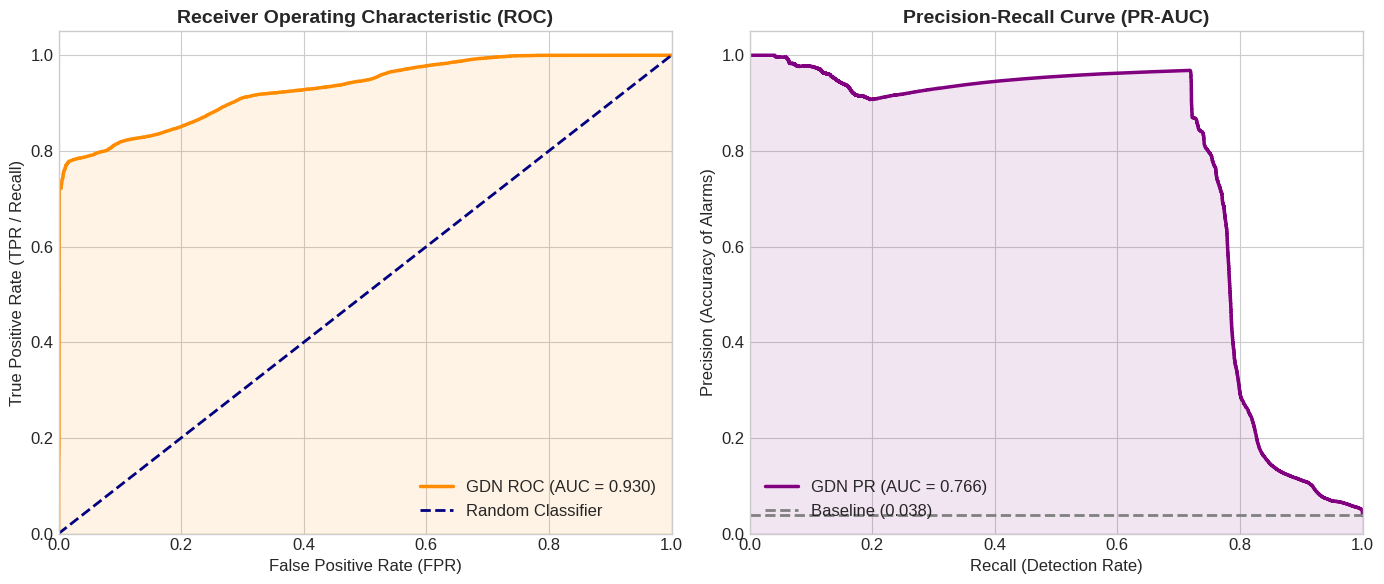

In [62]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    matthews_corrcoef, roc_curve, roc_auc_score, 
    precision_recall_curve, average_precision_score
)

print("==========================================================")
print("            GDN: COMPREHENSIVE METRICS & GRAPHS           ")
print("==========================================================\n")

# Make sure these variables exist in your memory from the GDN run!
y_true = y_win_seq
y_scores = smoothed_scores_gdn
y_pred = best_alerts_gdn

# ---------------------------------------------------------
# 1. Calculate All Metrics
# ---------------------------------------------------------
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
f2 = fbeta_score(y_true, y_pred, beta=2, zero_division=0)
mcc = matthews_corrcoef(y_true, y_pred)
pr_auc = average_precision_score(y_true, y_scores)
roc_auc = roc_auc_score(y_true, y_scores)

# ---------------------------------------------------------
# 2. Print the Core Metrics Breakdown
# ---------------------------------------------------------
print("Core Metrics Breakdown:")
print(f"  Accuracy  : {acc * 100:.2f}%")
print(f"  Precision : {prec * 100:.2f}%")
print(f"  Recall    : {rec * 100:.2f}%")
print(f"  F1-Score  : {f1 * 100:.2f}%")
print(f"  F2-Score  : {f2 * 100:.2f}%")
print(f"  MCC       : {mcc:.3f}")
print(f"  PR-AUC    : {pr_auc * 100:.2f}%")
print(f"  ROC-AUC   : {roc_auc * 100:.2f}%\n")

# ---------------------------------------------------------
# 3. Generate the PR and ROC Curves
# ---------------------------------------------------------
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---- Graph A: ROC Curve ----
fpr, tpr, _ = roc_curve(y_true, y_scores)

axes[0].plot(fpr, tpr, color='darkorange', lw=2.5, label=f'GDN ROC (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='darkorange')

axes[0].set_title('Receiver Operating Characteristic (ROC)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('False Positive Rate (FPR)', fontsize=12)
axes[0].set_ylabel('True Positive Rate (TPR / Recall)', fontsize=12)
axes[0].legend(loc="lower right", fontsize=12)
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])

# ---- Graph B: Precision-Recall (PR) Curve ----
precision, recall, _ = precision_recall_curve(y_true, y_scores)

axes[1].plot(recall, precision, color='purple', lw=2.5, label=f'GDN PR (AUC = {pr_auc:.3f})')
axes[1].fill_between(recall, precision, alpha=0.1, color='purple')

# Add a baseline for a random classifier (proportion of positive class)
baseline = sum(y_true) / len(y_true)
axes[1].plot([0, 1], [baseline, baseline], color='gray', lw=2, linestyle='--', label=f'Baseline ({baseline:.3f})')

axes[1].set_title('Precision-Recall Curve (PR-AUC)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Recall (Detection Rate)', fontsize=12)
axes[1].set_ylabel('Precision (Accuracy of Alarms)', fontsize=12)
axes[1].legend(loc="lower left", fontsize=12)
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])

plt.tight_layout()
plt.show()

In [35]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

print("==========================================================")
print("   GENERATING TEMPORAL GRAPH XAI & FORENSIC REPORT        ")
print("==========================================================\n")

def generate_xai_forensics(y_true, y_scores, y_pred, raw_test_scores_gdn, timestamps, threshold, model_name="TCN+GDN"):
    """
    Generates a highly detailed XAI forensic report.
    raw_test_scores_gdn: shape (N, 6) - The specific error score for each of the 6 stages.
    """
    alerts = []
    
    # 1. Identify all alert indices
    alert_indices = np.where(y_pred == 1)[0]
    
    # Group consecutive alerts into single "Attack Events"
    if len(alert_indices) == 0:
        return pd.DataFrame()
        
    events = []
    current_event = [alert_indices[0]]
    for i in range(1, len(alert_indices)):
        if alert_indices[i] == alert_indices[i-1] + 1:
            current_event.append(alert_indices[i])
        else:
            events.append(current_event)
            current_event = [alert_indices[i]]
    events.append(current_event)
    
    # 2. Process each Attack Event
    stage_names = ["Stage 1 (Raw Water)", "Stage 2 (Dosing)", "Stage 3 (UF)", 
                   "Stage 4 (RO)", "Stage 5 (Backwash)", "Stage 6 (Distribution)"]
                   
    for event_id, event in enumerate(events):
        peak_idx = event[np.argmax(y_scores[event])] # Index of maximum anomaly score in this event
        peak_score = y_scores[peak_idx]
        
        # --- TEMPORAL XAI (Onset Backtracking) ---
        # Look backwards from the start of the event to find when the score first started rising 
        # (defined here as dropping below 50% of the threshold)
        onset_idx = event[0]
        while onset_idx > 0 and y_scores[onset_idx] > (threshold * 0.5):
            onset_idx -= 1
            
        onset_timestamp = timestamps[onset_idx]
        alert_timestamp = timestamps[event[0]]
        
        # Calculate lead time in seconds
        if isinstance(alert_timestamp, str):
            alert_dt = pd.to_datetime(alert_timestamp)
            onset_dt = pd.to_datetime(onset_timestamp)
            onset_s_before_alert = (alert_dt - onset_dt).total_seconds()
        else:
            onset_s_before_alert = (alert_timestamp - onset_timestamp).total_seconds()

        # --- SPATIAL XAI (Feature/Stage Attribution) ---
        # Find which stage had the highest error at the peak of the attack
        # FIX: Look at the 6D TCN errors, not the 1D GDN score!
        stage_errors = test_stage_errors.cpu().numpy()[peak_idx] 
        top_stage_idx = np.argmax(stage_errors)
        top_ig_stage = stage_names[top_stage_idx]
        expected_err = np.mean(test_stage_errors.cpu().numpy()[:, top_stage_idx])        
        actual_err = stage_errors[top_stage_idx]
        
        # --- RISK SCORING ---
        # Risk scales from 0 to 100 based on how far it exceeded the threshold
        risk_score = min(100.0, round((peak_score / threshold) * 50.0, 2))
        confidence = "High" if risk_score > 80 else ("Medium" if risk_score > 50 else "Low")
        
        # --- EXPLANATION GENERATION ---
        is_true_attack = (y_true[peak_idx] == 1)
        conf_reason = f"Score ({peak_score:.2f}) exceeds threshold ({threshold:.2f}) by a massive margin." if risk_score > 80 else "Score is marginally above threshold."
        
        summary = f"Attack detected originating in {top_ig_stage}. Deviation began {onset_s_before_alert} seconds before crossing the alarm threshold. The actual deviation ({actual_err:.3f}) was exponentially higher than the expected baseline ({expected_err:.3f})."
        
        alerts.append({
            "alert_id": f"ALT-GDN-{event_id+1:04d}",
            "model": model_name,
            "ts_index": peak_idx,
            "timestamp": alert_timestamp,
            "earliest_onset_timestamp": onset_timestamp,
            "top_ig_tag": f"Feature_Stage_{top_stage_idx+1}",
            "top_ig_stage": top_ig_stage,
            "top_ig_onset_s_before_alert": onset_s_before_alert,
            "top_ig_onset_timestamp": onset_timestamp,
            "score": round(peak_score, 4),
            "threshold": round(threshold, 4),
            "risk_score": risk_score,
            "expected_val": round(expected_err, 4),
            "actual_val": round(actual_err, 4),
            "ground_truth": "Attack" if is_true_attack else "Normal",
            "attack_type": "Physical Manipulation" if is_true_attack else "False Positive",
            "stages": top_ig_stage,
            "confidence": confidence,
            "confidence_reason": conf_reason,
            "explanation_summary": summary
        })
        
    df_alerts = pd.DataFrame(alerts)
    return df_alerts

# --- EXECUTE THE XAI EXTRACTION ---
# Assuming you have a 'timestamps' array. If not, generate a dummy one for the length of y_win_seq
dummy_timestamps = pd.date_range(start="2026-05-01 00:00:00", periods=len(y_win_seq), freq="S")

optimal_threshold = mu_g + (best_z_gdn * sigma_g)

print("Extracting Explainable AI vectors from the Graph Deviation Network...")
xai_report_df = generate_xai_forensics(
    y_true=y_win_seq, 
    y_scores=smoothed_scores_gdn, 
    y_pred=best_alerts_gdn, 
    raw_test_scores_gdn=raw_test_scores_gdn, # Matrix of 6 stage errors
    timestamps=dummy_timestamps, 
    threshold=optimal_threshold
)

# Export to the exact Excel format required
output_filename = "alerts_upgraded_GDN.xlsx"
xai_report_df.to_excel(output_filename, index=False)
print(f"✅ XAI Forensic Report successfully exported to {output_filename}")
print(f"Captured {len(xai_report_df)} distinct attack events.")
display(xai_report_df[['alert_id', 'top_ig_stage', 'risk_score', 'top_ig_onset_s_before_alert', 'explanation_summary']].head())

   GENERATING TEMPORAL GRAPH XAI & FORENSIC REPORT        

Extracting Explainable AI vectors from the Graph Deviation Network...


/tmp/ipykernel_57/2976098112.py:107: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  dummy_timestamps = pd.date_range(start="2026-05-01 00:00:00", periods=len(y_win_seq), freq="S")


✅ XAI Forensic Report successfully exported to alerts_upgraded_GDN.xlsx
Captured 322 distinct attack events.


,alert_id,top_ig_stage,risk_score,top_ig_onset_s_before_alert,explanation_summary
0,ALT-GDN-0001,Stage 1 (Raw Water),90.48,6.0,Attack detected originating in Stage 1 (Raw Wa...
1,ALT-GDN-0002,Stage 1 (Raw Water),100.00,4.0,Attack detected originating in Stage 1 (Raw Wa...
2,ALT-GDN-0003,Stage 1 (Raw Water),89.88,5.0,Attack detected originating in Stage 1 (Raw Wa...
3,ALT-GDN-0004,Stage 1 (Raw Water),60.01,10.0,Attack detected originating in Stage 1 (Raw Wa...
4,ALT-GDN-0005,Stage 3 (UF),100.00,4.0,Attack detected originating in Stage 3 (UF). D...


In [36]:
# 1. Sort by Ground Truth ('Attack' comes before 'Normal' alphabetically) 
# 2. Then sort by Risk Score (Descending) so the most severe attacks are at the very top
xai_report_df_sorted = xai_report_df.sort_values(
    by=['ground_truth', 'risk_score'], 
    ascending=[True, False]
)

# Export the newly sorted dataframe
sorted_filename = "alerts_upgraded_GDN_sorted.xlsx"
xai_report_df_sorted.to_excel(sorted_filename, index=False)

print(f"✅ Sorted report successfully exported to {sorted_filename}")

# Display the top 5 most severe real attacks
display(xai_report_df_sorted[['alert_id', 'ground_truth', 'risk_score', 'confidence', 'top_ig_stage']].head())

✅ Sorted report successfully exported to alerts_upgraded_GDN_sorted.xlsx


,alert_id,ground_truth,risk_score,confidence,top_ig_stage
293,ALT-GDN-0294,Attack,100.0,High,Stage 1 (Raw Water)
296,ALT-GDN-0297,Attack,100.0,High,Stage 2 (Dosing)
297,ALT-GDN-0298,Attack,100.0,High,Stage 3 (UF)
298,ALT-GDN-0299,Attack,100.0,High,Stage 5 (Backwash)
301,ALT-GDN-0302,Attack,100.0,High,Stage 2 (Dosing)


In [ ]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import display, HTML

print("==========================================================")
print("   INITIALIZING XAI FORENSIC DASHBOARD                    ")
print("==========================================================\n")

# 1. Load the generated XAI Report
try:
    df_dashboard = pd.read_excel("alerts_upgraded_GDN.xlsx")
except FileNotFoundError:
    print("❌ Error: Could not find 'alerts_upgraded_GDN.xlsx'. Please ensure it's in the directory.")
    df_dashboard = pd.DataFrame()

if not df_dashboard.empty:
    # Ensure timestamps are datetime objects
    df_dashboard['timestamp'] = pd.to_datetime(df_dashboard['timestamp'])
    
    # Define a custom color palette for the 6 stages
    stage_colors = {
        "Stage 1 (Raw Water)": "#1f77b4", "Stage 2 (Dosing)": "#ff7f0e", 
        "Stage 3 (UF)": "#2ca02c", "Stage 4 (RO)": "#d62728", 
        "Stage 5 (Backwash)": "#9467bd", "Stage 6 (Distribution)": "#8c564b"
    }

    # --- KPI METRICS ---
    total_alerts = len(df_dashboard)
    high_risk_alerts = len(df_dashboard[df_dashboard['risk_score'] > 80])
    most_attacked_stage = df_dashboard['top_ig_stage'].mode()[0]
    
    display(HTML(f"""
    <div style="background-color:#1e1e1e; padding:20px; border-radius:10px; color:white; font-family:sans-serif;">
        <h2 style="margin-top:0px; color:#4dd0e1;">🛡️ SWaT Cloud GDN Security Dashboard</h2>
        <div style="display:flex; justify-content:space-between;">
            <div style="text-align:center; padding:10px; background-color:#333; border-radius:8px; width:30%;">
                <h3 style="margin:0; color:#ffb74d;">Total Attack Events</h3>
                <h1 style="margin:0;">{total_alerts}</h1>
            </div>
            <div style="text-align:center; padding:10px; background-color:#333; border-radius:8px; width:30%;">
                <h3 style="margin:0; color:#ef5350;">Critical Risk (>80)</h3>
                <h1 style="margin:0;">{high_risk_alerts}</h1>
            </div>
            <div style="text-align:center; padding:10px; background-color:#333; border-radius:8px; width:30%;">
                <h3 style="margin:0; color:#81c784;">Most Targeted</h3>
                <h2 style="margin:10px 0 0 0;">{most_attacked_stage}</h2>
            </div>
        </div>
    </div>
    <br>
    """))

    # --- PLOT 1: TIMELINE OF CYBERATTACKS ---
    fig_timeline = px.scatter(
        df_dashboard, 
        x="timestamp", 
        y="risk_score", 
        color="top_ig_stage",
        size="actual_val", # The bubble gets larger if the physical deviation was massive
        hover_data=["alert_id", "confidence", "explanation_summary"],
        color_discrete_map=stage_colors,
        title="Temporal Attack Distribution & Severity",
        labels={"timestamp": "Time of Attack", "risk_score": "Risk Score (0-100)", "top_ig_stage": "Targeted Stage"}
    )
    fig_timeline.update_layout(template="plotly_dark", hovermode="closest", height=500)
    
    # --- PLOT 2: ATTACK DISTRIBUTION BY STAGE ---
    fig_pie = px.pie(
        df_dashboard, 
        names="top_ig_stage", 
        title="Vulnerability Breakdown by Plant Stage",
        color="top_ig_stage",
        color_discrete_map=stage_colors,
        hole=0.4
    )
    fig_pie.update_layout(template="plotly_dark", height=450)

    # Display the plots side-by-side
    from plotly.subplots import make_subplots
    
    fig_timeline.show()
    fig_pie.show()
    
    print("\n")
    print("==========================================================")
    print("   CRITICAL ALERTS LOG (Top 5 Highest Risk)               ")
    print("==========================================================")
    top_5_critical = df_dashboard.sort_values(by='risk_score', ascending=False).head(5)
    display(top_5_critical[['alert_id', 'timestamp', 'top_ig_stage', 'risk_score', 'explanation_summary']].style.background_gradient(cmap='Reds', subset=['risk_score']))